This notebook should be used only for the original physical datasets. Here, we focus on rapid discovery, validation, feature engineering for both GNN ingestion and ML classifiers, anomaly labeling checks and artifacts needed for the CIS pipeline (ETL, Timescale/Neo4j, GNN autoencoder, XAI, XGBoost mapping).

Physical datasets include:
1. phy_att_1.csv
2. phy_att_2.csv
3. phy_att_3.csv
4. phy_att_4.csv
5. phy_norm.csv

# Step 1 - Data load and project metadata

Purpose: capture provenance, dataset-level metadata and reproducible load steps

In [ ]:
# 0. Environment / constants
import os
import json
from datetime import datetime, timezone
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib import cm
import seaborn as sns
import networkx as nx
from pathlib import Path

# ML
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, precision_recall_fscore_support
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import xgboost as xgb
import shap
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, utils
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Notebook constants
try:
    SOURCE = df = pd.read_csv("/content/drive/MyDrive/CS/AI Cybersecurity/CIS_datasets/PhysicalDataSet/phy_att_2.csv", sep="\t", encoding='utf-16', engine="python")
except UnicodeDecodeError:
        print("UnicodeDecodeError")
OUTPUT_DIR = Path("artifacts")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DATASET_VERSION = "v1"
INGEST_TIME = datetime.now(timezone.utc).isoformat()
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [ ]:
print("SOURCE:", SOURCE)
print("type(SOURCE):", type(SOURCE))

SOURCE:                      Time  Tank_1  Tank_2  Tank_3  Tank_4  Tank_5  Tank_6  \
0     19/04/2021 15:37:12       0       0       0       0       0       0   
1     19/04/2021 15:37:13       0       0       0       0       0       0   
2     19/04/2021 15:37:15       0       0       0       0       0       0   
3     19/04/2021 15:37:16       0       0       0       0       0       0   
4     19/04/2021 15:37:17       0       0       0       0       0       0   
...                   ...     ...     ...     ...     ...     ...     ...   
2099  19/04/2021 16:12:12       0    1678     255       0     475     254   
2100  19/04/2021 16:12:13       0    1732     263       0     470     254   
2101  19/04/2021 16:12:14       0    1715     266       0     467     254   
2102  19/04/2021 16:12:15       0    1730     272       0     463     254   
2103  19/04/2021 16:12:16       0    1745     276       0     458     254   

      Tank_7  Tank_8  Pump_1  ...  Valv_15  Valv_16  Valv_17  Valv_

In [ ]:
SOURCE_PATH = Path("/content/drive/MyDrive/CS/AI Cybersecurity/CIS_datasets/PhysicalDataSet/phy_att_2.csv")

In [ ]:
# Read with utf-16 (BOM indicates little-endian)
df = pd.read_csv(SOURCE_PATH, encoding="utf-16", sep="\t", engine="python")

# Normalize Time column (assume US month/day/year format)
df['Time'] = pd.to_datetime(df['Time'], dayfirst=False, errors='raise')
print("shape:", df.shape)
display(df.head())

# Quick checks
print("Loaded:", SOURCE_PATH)
print("shape:", df.shape)
print(df.dtypes)
display(df.head())

shape: (2104, 43)


/tmp/ipython-input-3613000105.py:5: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Time'] = pd.to_datetime(df['Time'], dayfirst=False, errors='raise')


,Time,Tank_1,Tank_2,Tank_3,Tank_4,Tank_5,Tank_6,Tank_7,Tank_8,Pump_1,...,Valv_15,Valv_16,Valv_17,Valv_18,Valv_19,Valv_20,Valv_21,Valv_22,Lable_n,Label
0,2021-04-19 15:37:12,0,0,0,0,0,0,0,0,False,...,False,False,False,False,False,False,False,False,0,normal
1,2021-04-19 15:37:13,0,0,0,0,0,0,0,0,False,...,False,False,False,False,False,False,False,False,0,normal
2,2021-04-19 15:37:15,0,0,0,0,0,0,0,0,False,...,False,False,False,False,False,False,False,False,0,normal
3,2021-04-19 15:37:16,0,0,0,0,0,0,0,0,False,...,False,False,False,False,False,False,False,False,0,normal
4,2021-04-19 15:37:17,0,0,0,0,0,0,0,0,False,...,False,False,False,False,False,False,False,False,0,normal


Loaded: /content/drive/MyDrive/CS/AI Cybersecurity/CIS_datasets/PhysicalDataSet/phy_att_2.csv
shape: (2104, 43)
Time             datetime64[ns]
Tank_1                    int64
Tank_2                    int64
Tank_3                    int64
Tank_4                    int64
Tank_5                    int64
Tank_6                    int64
Tank_7                    int64
Tank_8                    int64
Pump_1                     bool
Pump_2                     bool
Pump_3                     bool
Pump_4                     bool
Pump_5                     bool
Pump_6                     bool
Flow_sensor_1             int64
Flow_sensor_2             int64
Flow_sensor_3             int64
Flow_sensor_4             int64
Valv_1                     bool
Valv_2                     bool
Valv_3                     bool
Valv_4                     bool
Valv_5                     bool
Valv_6                     bool
Valv_7                     bool
Valv_8                     bool
Valv_9                  

,Time,Tank_1,Tank_2,Tank_3,Tank_4,Tank_5,Tank_6,Tank_7,Tank_8,Pump_1,...,Valv_15,Valv_16,Valv_17,Valv_18,Valv_19,Valv_20,Valv_21,Valv_22,Lable_n,Label
0,2021-04-19 15:37:12,0,0,0,0,0,0,0,0,False,...,False,False,False,False,False,False,False,False,0,normal
1,2021-04-19 15:37:13,0,0,0,0,0,0,0,0,False,...,False,False,False,False,False,False,False,False,0,normal
2,2021-04-19 15:37:15,0,0,0,0,0,0,0,0,False,...,False,False,False,False,False,False,False,False,0,normal
3,2021-04-19 15:37:16,0,0,0,0,0,0,0,0,False,...,False,False,False,False,False,False,False,False,0,normal
4,2021-04-19 15:37:17,0,0,0,0,0,0,0,0,False,...,False,False,False,False,False,False,False,False,0,normal


Checklist (save as cell outputs):
- Source path, checksum (md5), rows, columns, load timestamp.
- Schema table: column name, dtype, non-null count.

# Step 2 - Initial sanity checks and cleaning

Purpose: find missing / constant / malformed columns, time continuity issues and duplicates

In [ ]:
# Ensure Time is datetime, sort, check duplicates
df['Time'] = pd.to_datetime(df['Time'])
df = df.sort_values('Time').reset_index(drop=True)
dup_count = df.duplicated(subset=['Time']).sum()
print("Duplicate timestamps:", dup_count)

# Check nulls and constant columns
nulls = df.isnull().sum()
const_cols = [c for c in df.columns if df[c].nunique() <= 1]
print("Columns with nulls > 0:\n", nulls[nulls > 0])
print("Constant or single-value columns:", const_cols)

# If duplicates exist, keep first
if dup_count > 0:
    df = df[~df.duplicated(subset=['Time'])].copy()

# Quick label consistency check
if set(['Label','Label_n','Label_encoded']).issubset(df.columns):
    print(df[['Label','Label_n','Label_encoded']].drop_duplicates().reset_index(drop=True).head())
else:
    print("Label columns missing some expected names.")

Duplicate timestamps: 0
Columns with nulls > 0:
 Series([], dtype: int64)
Constant or single-value columns: ['Pump_3', 'Flow_sensor_3', 'Valv_1', 'Valv_2', 'Valv_3', 'Valv_4', 'Valv_5', 'Valv_6', 'Valv_7', 'Valv_8', 'Valv_9', 'Valv_16', 'Valv_19', 'Valv_21']
Label columns missing some expected names.


In [ ]:
# drop constant columns discovered earlier and log them
const_cols = ['Pump_3', 'Flow_sensor_3', 'Valv_1', 'Valv_2', 'Valv_3', 'Valv_4',
              'Valv_5', 'Valv_6', 'Valv_7', 'Valv_8', 'Valv_9', 'Valv_16',
              'Valv_19', 'Valv_21']  # from your report

# keep only columns that exist (idempotent)
const_cols = [c for c in const_cols if c in df.columns]
print("Dropping constant columns:", const_cols)
df = df.drop(columns=const_cols)
(OUTPUT_DIR / "dropped_constant_columns.txt").write_text("\n".join(const_cols))

Dropping constant columns: ['Pump_3', 'Flow_sensor_3', 'Valv_1', 'Valv_2', 'Valv_3', 'Valv_4', 'Valv_5', 'Valv_6', 'Valv_7', 'Valv_8', 'Valv_9', 'Valv_16', 'Valv_19', 'Valv_21']


107

In [ ]:
# Time -> datetime (already done earlier, but safe)
df['Time'] = pd.to_datetime(df['Time'], dayfirst=False, errors='raise')

# Detect boolean-like columns (strings 'True'/'False' or numeric 0/1) and coerce
bool_candidates = []
for c in df.columns:
    if c == 'Time' or c == 'Label' or c == 'Label_n':
        continue
    s = df[c].dropna().astype(str)
    if s.isin(['True','False','TRUE','FALSE']).all():
        bool_candidates.append(c)
    else:
        # numeric-like check
        try:
            pd.to_numeric(df[c].dropna())
            # if numeric and only 0/1 values, treat as bool
            uniques = pd.to_numeric(df[c].dropna()).unique()
            if set(uniques).issubset({0,1}):
                bool_candidates.append(c)
        except Exception:
            pass

print("Boolean candidates to coerce:", bool_candidates)
for c in bool_candidates:
    df[c] = df[c].astype(str).map({'True': True, 'False': False, 'TRUE': True, 'FALSE': False, '0': False, '1': True}).astype(bool)

# Convert remaining numeric-like columns to numeric
for c in df.columns:
    if c in ['Time','Label','Label_n']:
        continue
    if df[c].dtype == object:
        df[c] = pd.to_numeric(df[c], errors='ignore')

Boolean candidates to coerce: ['Pump_1', 'Pump_2', 'Pump_4', 'Pump_5', 'Pump_6', 'Valv_10', 'Valv_11', 'Valv_12', 'Valv_13', 'Valv_14', 'Valv_15', 'Valv_17', 'Valv_18', 'Valv_20', 'Valv_22', 'Lable_n']


In [ ]:
# Inspect label-like columns
print("Columns:", [c for c in df.columns if 'label' in c.lower() or c.lower().startswith('label')])
print("Unique Label values (if present):", df['Label'].unique() if 'Label' in df.columns else "missing")

# Create Label_encoded if missing
if 'Label_encoded' not in df.columns:
    if 'Label_n' in df.columns and df['Label_n'].nunique() > 1:
        df['Label_encoded'] = df['Label_n'].astype(int)
        print("Created Label_encoded from Label_n")
    elif 'Label' in df.columns:
        # map textual labels to integers
        label_map = {lab: idx for idx, lab in enumerate(sorted(df['Label'].unique()))}
        df['Label_encoded'] = df['Label'].map(label_map).astype(int)
        print("Created Label_encoded from Label with map:", label_map)
    else:
        # no label information — create a default 'normal' label 0
        df['Label_encoded'] = 0
        print("No label column found; created default Label_encoded = 0 for all rows")

# Save label mapping if available
if 'label_map' in locals():
    (OUTPUT_DIR / "label_map.json").write_text(json.dumps(label_map, indent=2))

Columns: ['Label']
Unique Label values (if present): ['normal' 'scan' 'DoS' 'physical fault' 'nomal' 'MITM']
Created Label_encoded from Label with map: {'DoS': 0, 'MITM': 1, 'nomal': 2, 'normal': 3, 'physical fault': 4, 'scan': 5}


In [ ]:
# Resample to fixed frequency with updated API (use 's' and .ffill())
RESAMPLE = True
FREQ = "1s"  # use lowercase 's' not 'S'

if RESAMPLE:
    df = df.sort_values('Time').reset_index(drop=True)
    df_ts = df.set_index('Time').asfreq(FREQ)
    # Updated fill API
    df_ts = df_ts.ffill()
    df_ts = df_ts.fillna(0)
    df_ts = df_ts.reset_index()
    print("Resampled to", FREQ, "-> rows:", len(df_ts))
else:
    df_ts = df.copy()
    print("Using original timestamps; no resampling applied")

Resampled to 1s -> rows: 2105


/tmp/ipython-input-4126240003.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_ts = df_ts.ffill()


In [ ]:
print("Final shape:", df_ts.shape)
display(df_ts.dtypes.head(40))
# show a few rows
display(df_ts.head())

Final shape: (2105, 30)


,0
Time,datetime64[ns]
Tank_1,float64
Tank_2,float64
Tank_3,float64
Tank_4,float64
Tank_5,float64
Tank_6,float64
Tank_7,float64
Tank_8,float64
Pump_1,bool


,Time,Tank_1,Tank_2,Tank_3,Tank_4,Tank_5,Tank_6,Tank_7,Tank_8,Pump_1,...,Valv_13,Valv_14,Valv_15,Valv_17,Valv_18,Valv_20,Valv_22,Lable_n,Label,Label_encoded
0,2021-04-19 15:37:12,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,...,False,False,False,False,False,False,False,False,normal,3.0
1,2021-04-19 15:37:13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,...,False,False,False,False,False,False,False,False,normal,3.0
2,2021-04-19 15:37:14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,...,False,False,False,False,False,False,False,False,normal,3.0
3,2021-04-19 15:37:15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,...,False,False,False,False,False,False,False,False,normal,3.0
4,2021-04-19 15:37:16,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,...,False,False,False,False,False,False,False,False,normal,3.0


Deliverables:
- Nulls report, constant-columns list, duplicate-times count.
- Action log: (e.g., "no nulls", "drop Valv_XX constant", "resample to 1s").

# Step 3 - Time-series structure and resampling

Purpose: ensure consistent temporal granularity for downstream models; examine gaps and sampling jitter

In [ ]:
# Delta seconds distribution
deltas = df['Time'].diff().dt.total_seconds().dropna()
print(deltas.describe())

# Detect sizable gaps
gap_threshold_s = 5
gaps = deltas[deltas > gap_threshold_s]
print("Number of gaps >", gap_threshold_s, "s:", len(gaps))

# Resample to fixed frequency if needed (example: 1s)
RESAMPLE = True
FREQ = "1s"  # use lowercase 's'

if RESAMPLE:
    df_ts = df.set_index('Time').asfreq(FREQ)
    # forward-fill then fill remaining NaNs with zeros
    df_ts = df_ts.ffill().fillna(0)
    df_ts = df_ts.reset_index()
    print("Resampled to", FREQ, "length:", len(df_ts))
else:
    df_ts = df.copy()

count    2103.000000
mean        1.000476
std         0.021806
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         2.000000
Name: Time, dtype: float64
Number of gaps > 5 s: 0
Resampled to 1s length: 2105


/tmp/ipython-input-2416847927.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_ts = df_ts.ffill().fillna(0)


Deliverables:
- Chosen frequency, gap-report, resampling procedure justification

# Step 4 - Exploratory data analysis, univariate and multivariate

Purpose: reveal distributions, cycles, correlated components and baseline behaviors

Numeric columns: ['Tank_1', 'Tank_2', 'Tank_3', 'Tank_4', 'Tank_5', 'Tank_6', 'Tank_7', 'Tank_8', 'Flow_sensor_1', 'Flow_sensor_2', 'Flow_sensor_4']
Boolean columns: ['Pump_1', 'Pump_2', 'Pump_4', 'Pump_5', 'Pump_6', 'Valv_10', 'Valv_11', 'Valv_12', 'Valv_13', 'Valv_14', 'Valv_15', 'Valv_17', 'Valv_18', 'Valv_20', 'Valv_22', 'Lable_n']


,0
Valv_17,0.952494
Valv_20,0.682185
Pump_1,0.638480
Valv_22,0.408551
Pump_6,0.364846
Pump_5,0.341568
Valv_12,0.310689
Valv_11,0.310689
Valv_10,0.310214
Pump_4,0.233729


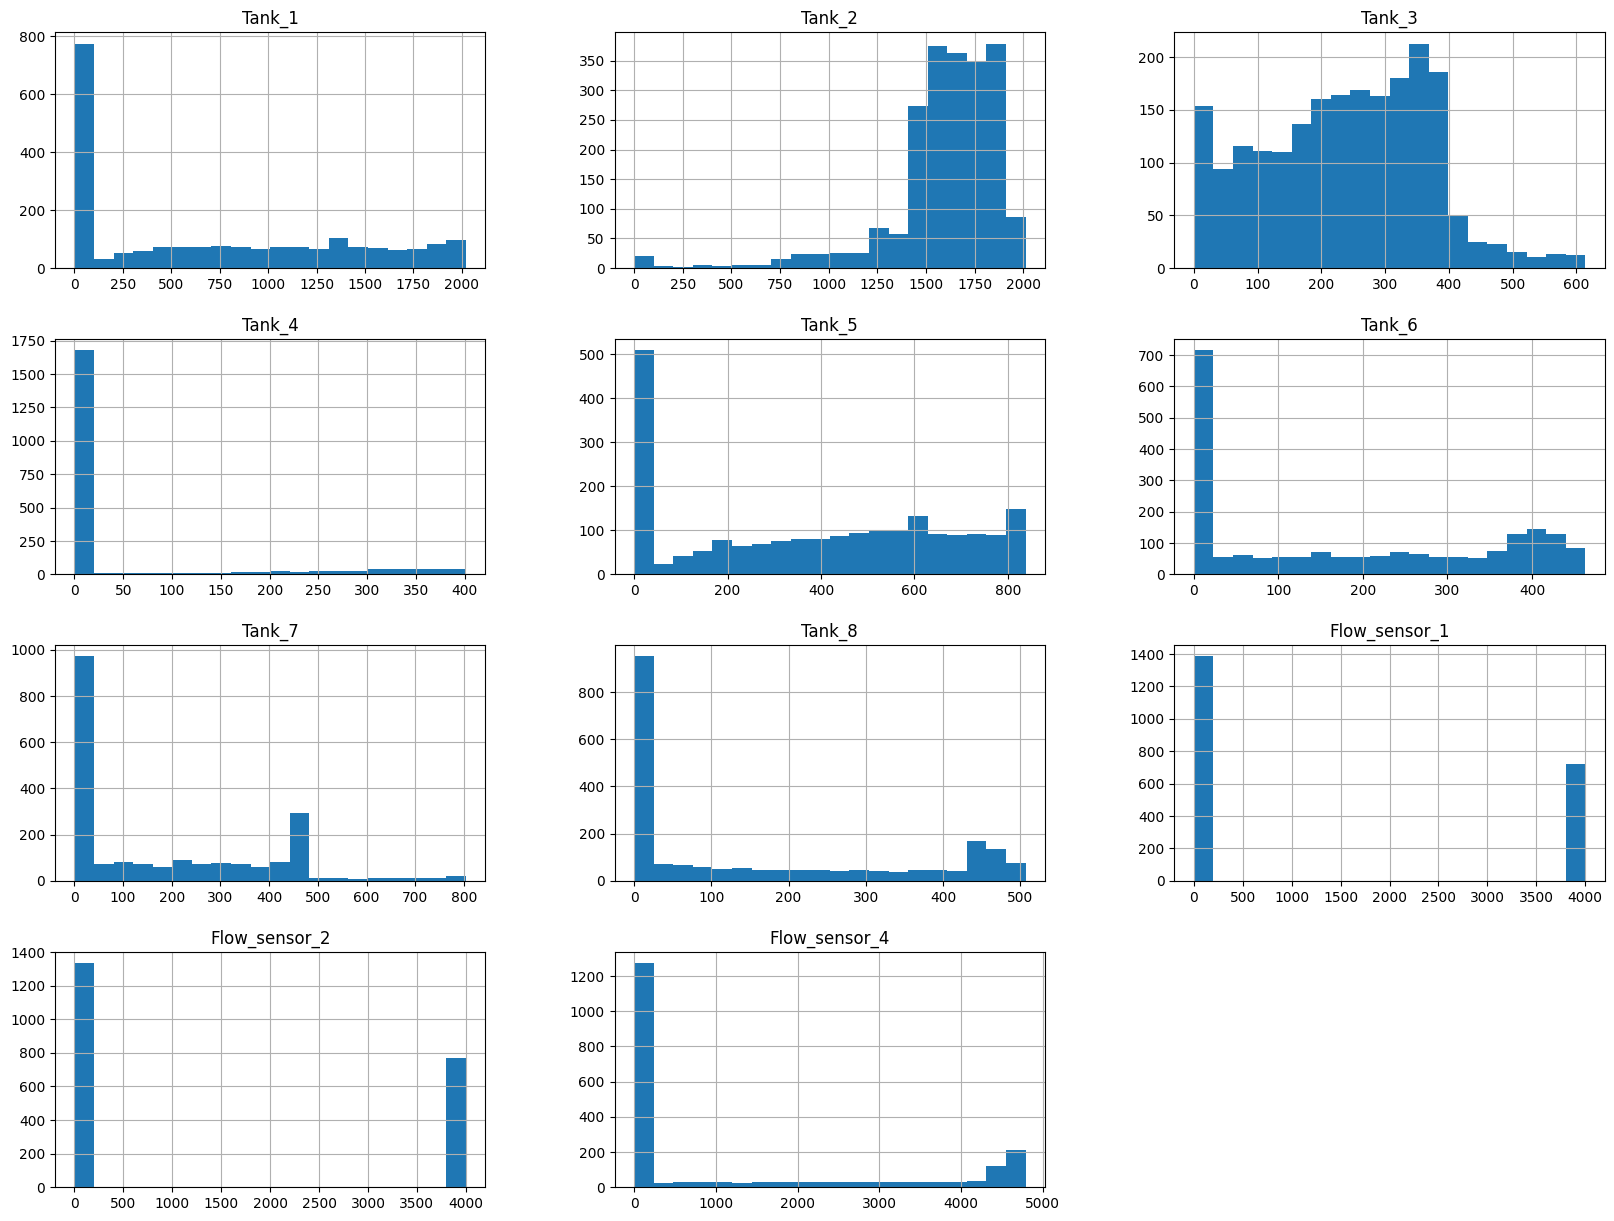

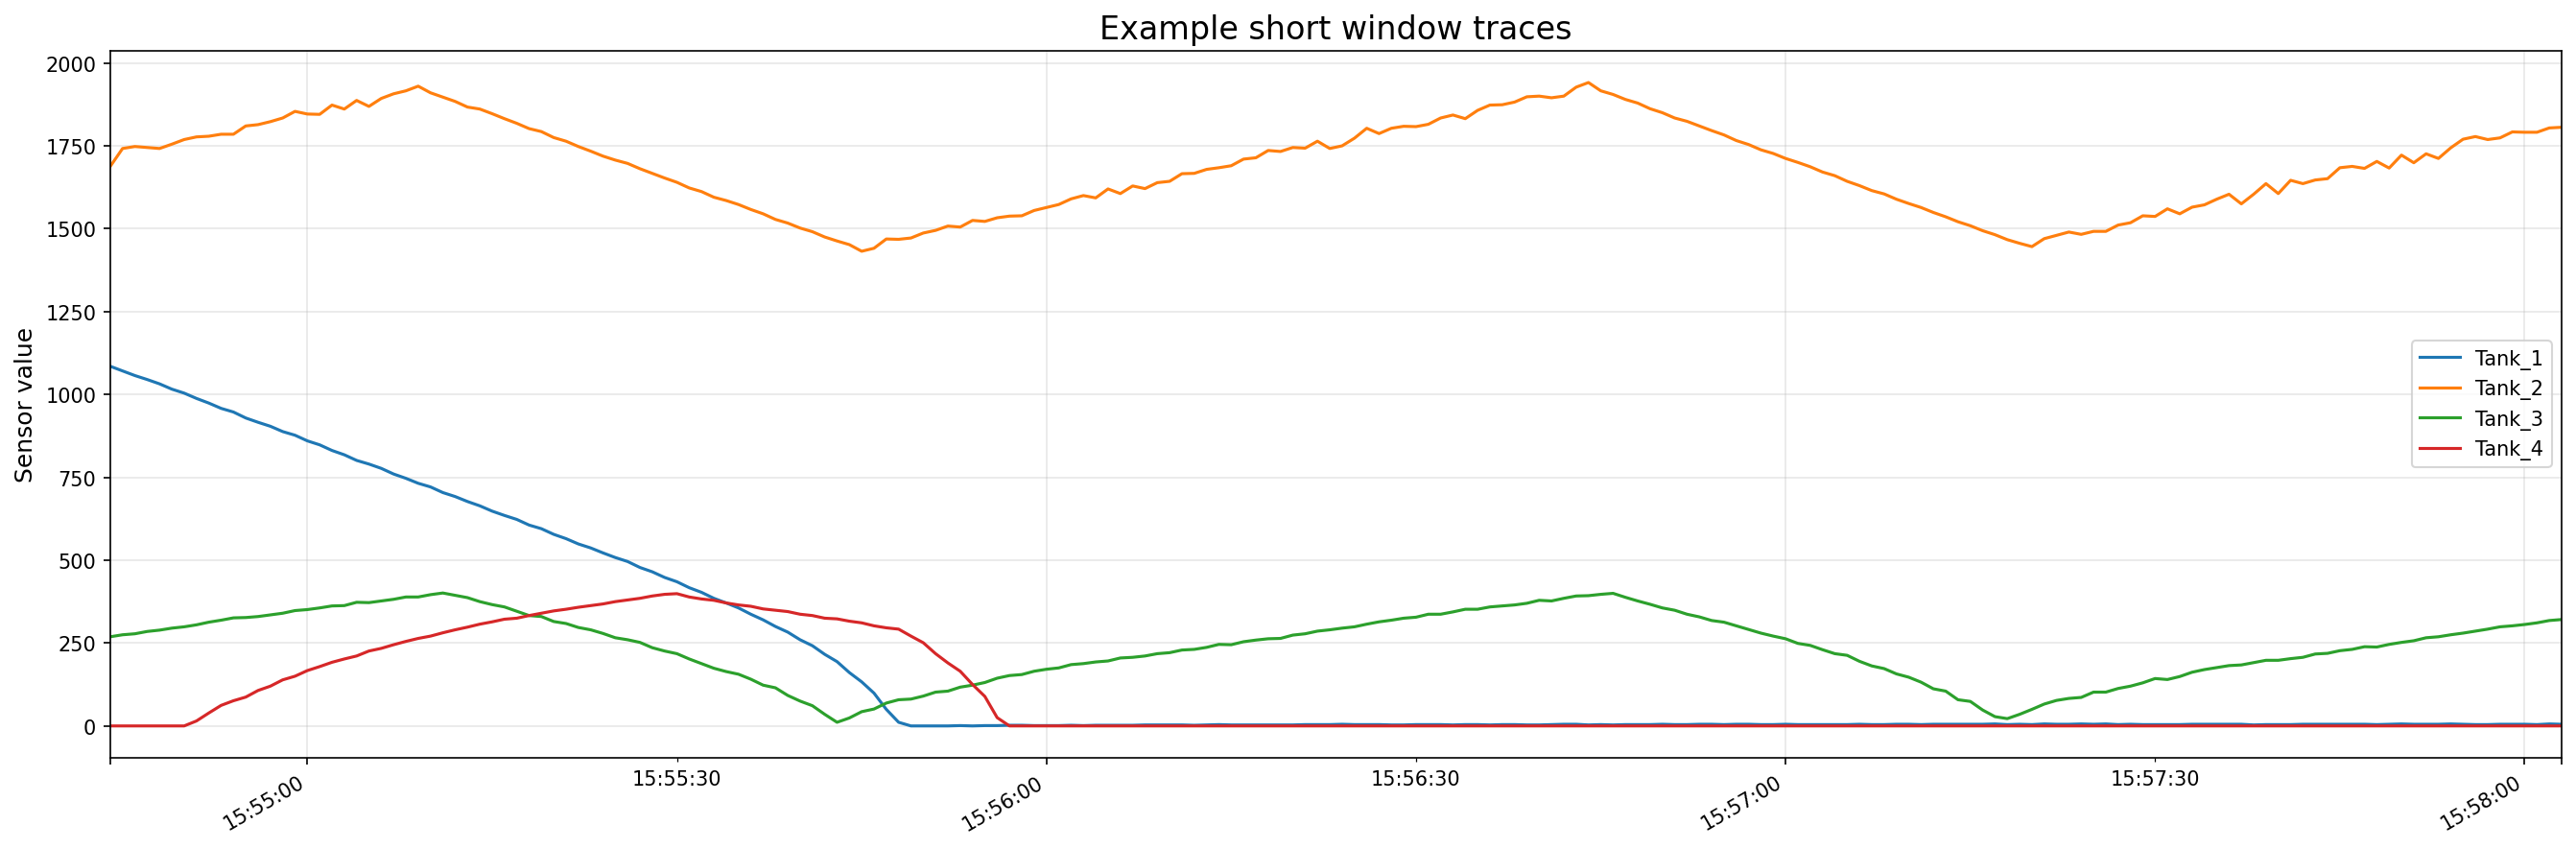

In [ ]:
# Numeric and boolean column lists
num_cols = [c for c in df_ts.columns if df_ts[c].dtype.kind in 'iuf' and c != 'Label_encoded']
bool_cols = [c for c in df_ts.columns if df_ts[c].dtype == 'bool']
print("Numeric columns:", num_cols)
print("Boolean columns:", bool_cols)

# Histograms for numeric (small sample if many)
_ = df_ts[num_cols].hist(figsize=(20, 15), bins=20)

# Boolean on-rate
bool_rates = pd.Series({c: df_ts[c].mean() for c in bool_cols}).sort_values(ascending=False)
display(bool_rates.head(40))

# Larger trace plot for Tanks and Flow sensors around the dataset midpoint
example_cols = [c for c in num_cols if 'Tank' in c or 'Flow_sensor' in c][:4]
mid = len(df_ts) // 2
window = 200

fig, ax = plt.subplots(figsize=(18, 6), dpi=150)   # bigger size and higher resolution
df_ts.set_index('Time')[example_cols].iloc[mid:mid+window].plot(ax=ax)
ax.set_title("Example short window traces", fontsize=16)
ax.set_xlabel("")
ax.set_ylabel("Sensor value", fontsize=12)
ax.grid(alpha=0.3)

# Improve x-axis formatting
fig.autofmt_xdate(rotation=30)
plt.tight_layout()

fig.savefig(OUTPUT_DIR / "example_traces_large.png", bbox_inches='tight', dpi=150)
plt.show()


## 4.1 Sensor distributions and boolean behavior

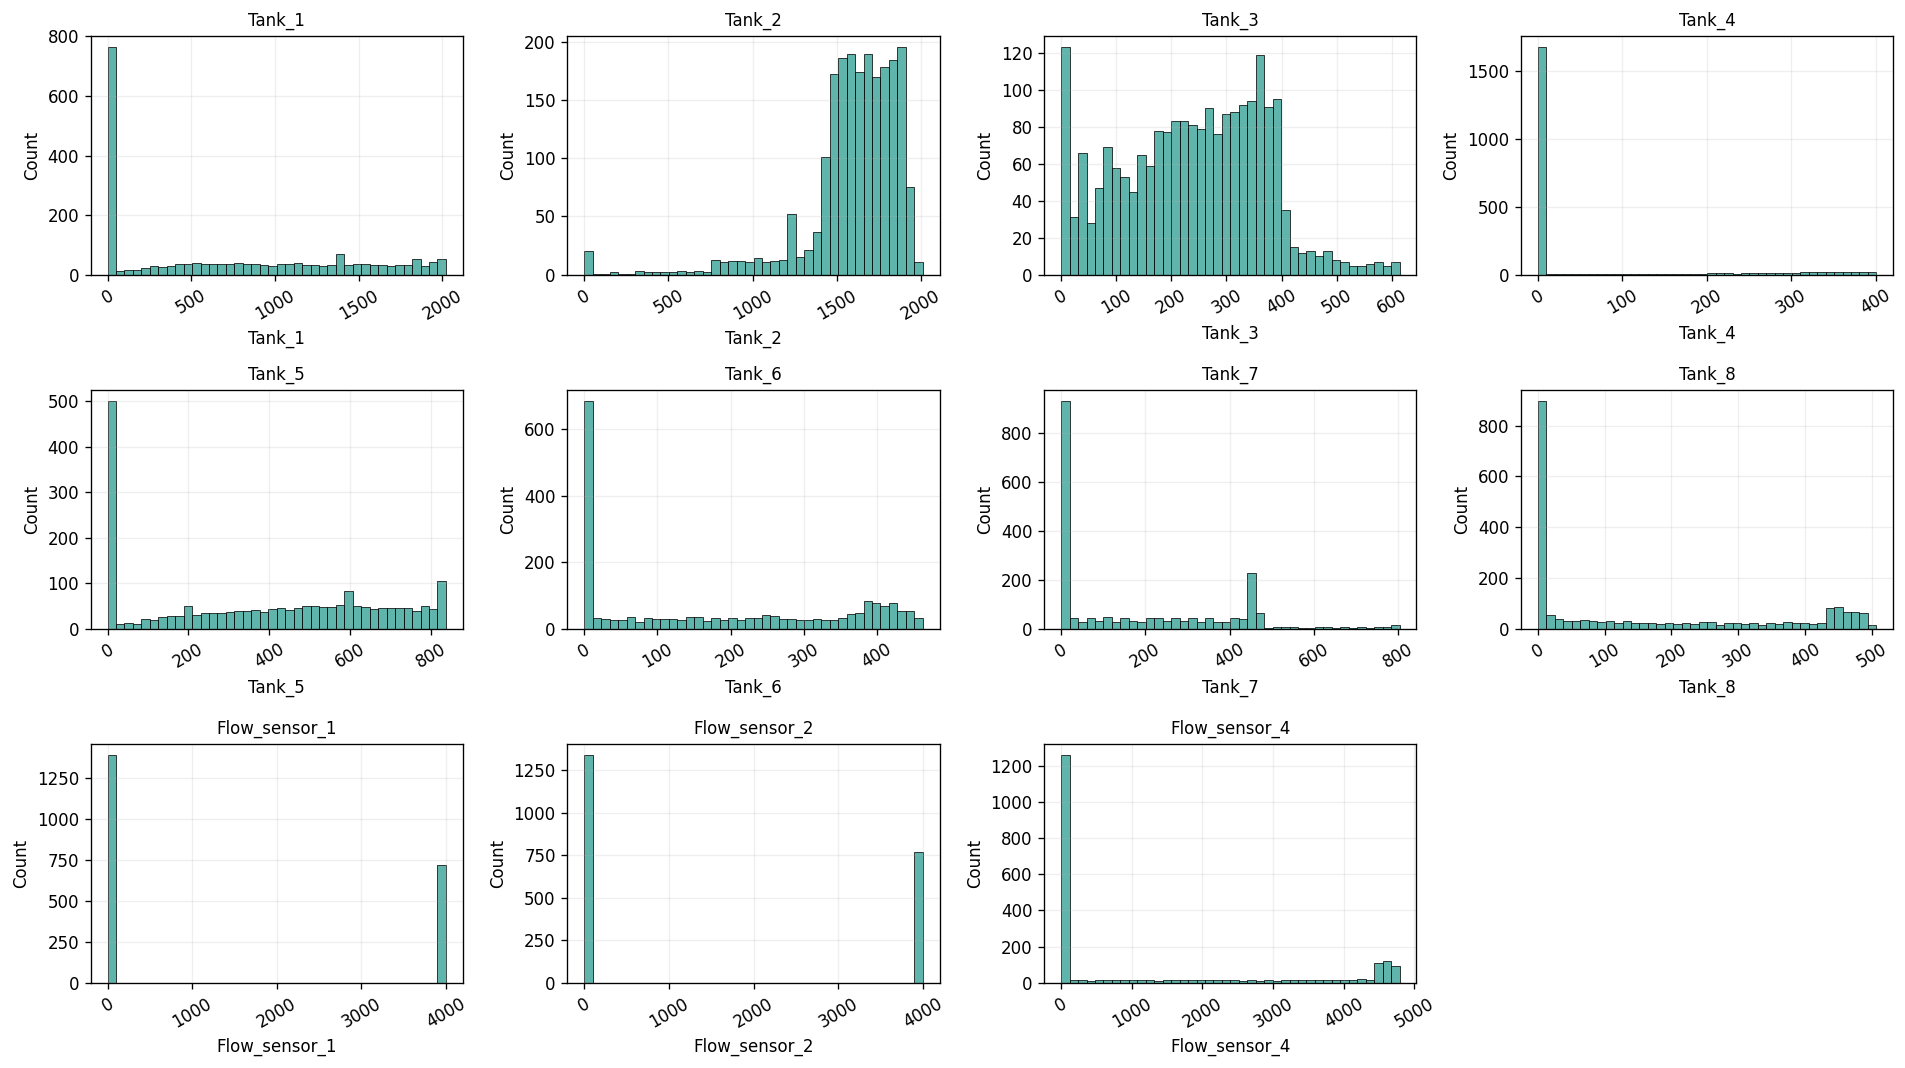

In [ ]:
# Plot histograms for Tank_i and Flow_sensor_i
# select columns
tank_cols = [c for c in df_ts.columns if c.startswith("Tank_")]
flow_cols = [c for c in df_ts.columns if c.startswith("Flow_sensor")]

# combined histogram grid
cols = tank_cols + flow_cols
n = len(cols)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows), dpi=120)
axes = axes.flatten()

for ax, col in zip(axes, cols):
    sns.histplot(df_ts[col].dropna(), bins=40, kde=False, stat="count", ax=ax, color="#2a9d8f")
    ax.set_title(col, fontsize=10)
    ax.tick_params(axis='x', labelrotation=30)
    ax.grid(alpha=0.2)
# hide any unused axes
for ax in axes[len(cols):]:
    ax.set_visible(False)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "hist_tanks_flows.png", bbox_inches='tight', dpi=150)
plt.show()

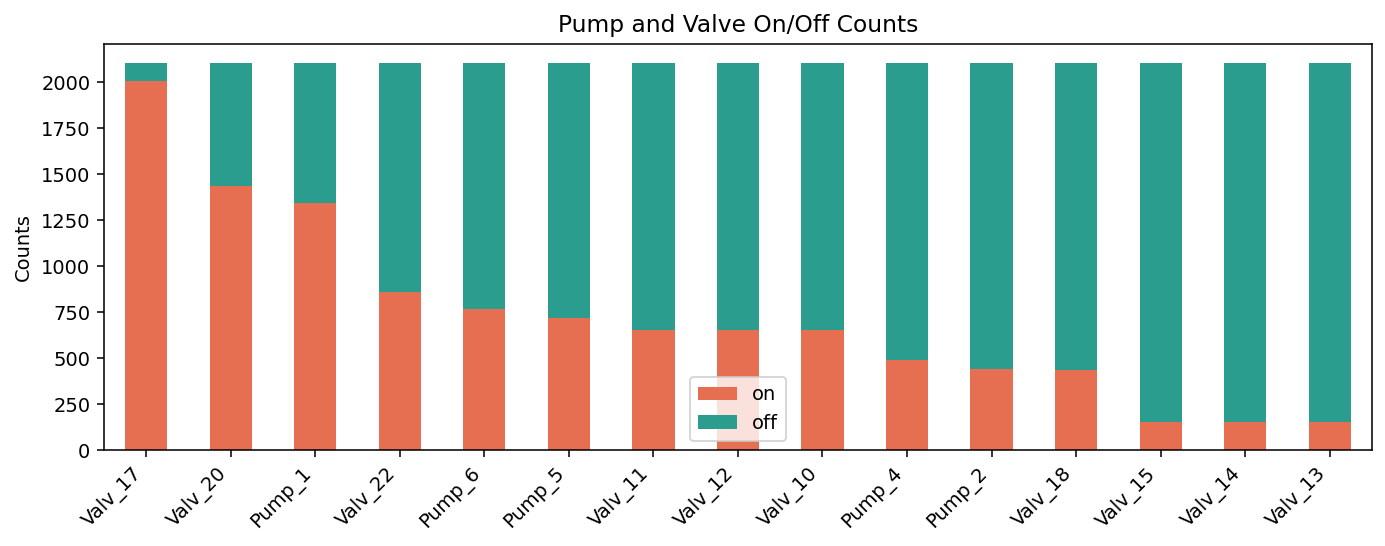

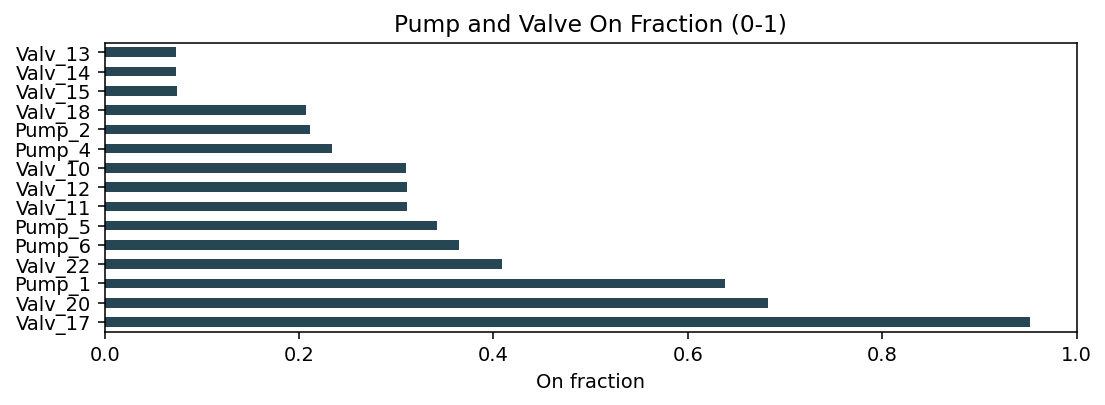

,component,on,off,on_pct
0,Valv_17,2005,100,0.952494
1,Valv_20,1436,669,0.682185
2,Pump_1,1344,761,0.638480
3,Valv_22,860,1245,0.408551
4,Pump_6,768,1337,0.364846
5,Pump_5,719,1386,0.341568
6,Valv_11,654,1451,0.310689
7,Valv_12,654,1451,0.310689
8,Valv_10,653,1452,0.310214
9,Pump_4,492,1613,0.233729


In [ ]:
# Bar counts for boolean pumps and valves (on vs off)
# identify boolean columns that look like pumps or valves
bool_cols = [c for c in df_ts.columns if df_ts[c].dtype == 'bool']
pump_valve_cols = [c for c in bool_cols if c.lower().startswith('pump') or c.lower().startswith('valv')]

# compute counts and percentages
counts = pd.DataFrame({
    'on': df_ts[pump_valve_cols].sum(),
    'off': (~df_ts[pump_valve_cols]).sum()
})
counts['on_pct'] = counts['on'] / (counts['on'] + counts['off'])

# sort by on count for readable bars
counts = counts.sort_values('on', ascending=False)

# stacked bar plot (absolute counts)
fig, ax = plt.subplots(figsize=(10, max(4, len(counts)*0.25)), dpi=140)
counts[['on','off']].plot.bar(stacked=True, ax=ax, color=['#e76f51','#2a9d8f'])
ax.set_ylabel('Counts')
ax.set_title('Pump and Valve On/Off Counts')
ax.legend(title='')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "pump_valve_on_off_counts_stacked.png", dpi=150, bbox_inches='tight')
plt.show()

# horizontal bar plot for on percentage
fig, ax = plt.subplots(figsize=(8, max(3, len(counts)*0.2)), dpi=140)
counts['on_pct'].plot.barh(ax=ax, color='#264653')
ax.set_xlabel('On fraction')
ax.set_title('Pump and Valve On Fraction (0-1)')
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "pump_valve_on_fraction.png", dpi=150, bbox_inches='tight')
plt.show()

# show table of counts (top rows)
display(counts.reset_index().rename(columns={'index':'component'}).head(40))

In [ ]:
def longest_constant_run(series: pd.Series) -> int:
    # Convert to numpy with object dtype so we can compare including NaNs reliably
    arr = series.to_numpy(dtype=object)
    if arr.size == 0:
        return 0
    # Treat NaN as break: replace NaN with a unique sentinel per run (object() instance)
    # We use None as sentinel because arr dtype is object; None will not equal any real value
    # but be careful if None actually appears in the data; it's rare for numeric sensors.
    prev = arr[0]
    if pd.isna(prev):
        prev = object()
    longest = 1
    cur = 1
    for i in range(1, len(arr)):
        cur_val = arr[i]
        if pd.isna(cur_val):
            cur_val = object()  # break
        if cur_val == prev:
            cur += 1
            if cur > longest:
                longest = cur
        else:
            cur = 1
            prev = cur_val
    return longest

# Re-run the sensor scan with the fixed function
NUMERIC_COLS = [c for c in df_ts.columns if df_ts[c].dtype.kind in "iuf" and c != 'Label_encoded']
CLIP_FRAC = 0.01
STUCK_RUN_MIN = 10
SPIKE_Z_THRESH = 5.0
MAD_MULTIPLIER = 6.0

reports = []
for c in NUMERIC_COLS:
    s = df_ts[c].dropna().astype(float)
    if s.empty:
        reports.append({'sensor': c, 'flags': 'empty'})
        continue

    q_low, q_med, q_high = np.percentile(s, [1, 50, 99])
    iqr = np.percentile(s, 75) - np.percentile(s, 25)
    mad = np.median(np.abs(s - np.median(s)))
    mean = float(np.mean(s))
    std = float(np.std(s, ddof=1)) if len(s) > 1 else 0.0
    n = len(s)

    minv, maxv = float(np.nanmin(s)), float(np.nanmax(s))
    pct_min = (s == minv).mean()
    pct_max = (s == maxv).mean()
    clipped = (pct_min >= CLIP_FRAC) or (pct_max >= CLIP_FRAC)

    # low variance / constant
    unique_vals = np.unique(s)
    single_valued = len(unique_vals) == 1
    low_variance = (iqr == 0) or (std == 0)

    # Use the robust longest-constant-run on the full column (not dropna) to detect runs broken by NaN
    longest_run = longest_constant_run(df_ts[c])
    stuck = longest_run >= STUCK_RUN_MIN

    # spikes
    diffs = s.diff().dropna()
    if diffs.empty:
        spike_frac = 0.0
    else:
        z = (diffs - diffs.mean()) / (diffs.std(ddof=1) if diffs.std(ddof=1) > 0 else 1)
        spike_frac = (np.abs(z) > SPIKE_Z_THRESH).mean()
    mad_thr = MAD_MULTIPLIER * (mad if mad > 0 else (std if std > 0 else 1.0))
    mad_spike_frac = (np.abs(s - q_med) > mad_thr).mean()

    flags = []
    if single_valued or low_variance:
        flags.append('constant_or_low_variance')
    if clipped:
        flags.append('clipped_at_extreme')
    if pct_min >= CLIP_FRAC:
        flags.append(f'clipped_min_pct={pct_min:.3f}')
    if pct_max >= CLIP_FRAC:
        flags.append(f'clipped_max_pct={pct_max:.3f}')
    if stuck:
        flags.append(f'long_constant_run={longest_run}')
    if spike_frac > 0:
        flags.append(f'sudden_jumps_frac={spike_frac:.3f}')
    if mad_spike_frac > 0.001:
        flags.append(f'mad_anom_frac={mad_spike_frac:.3f}')
    if not flags:
        flags.append('ok')

    reports.append({
        'sensor': c,
        'n': n,
        'min': minv,
        '1pct': q_low,
        'median': q_med,
        '99pct': q_high,
        'max': maxv,
        'pct_min': round(float(pct_min), 6),
        'pct_max': round(float(pct_max), 6),
        'longest_const_run': int(longest_run),
        'spike_frac_z': float(spike_frac),
        'mad_anom_frac': float(mad_spike_frac),
        'iqr': float(iqr),
        'std': float(std),
        'flags': ';'.join(flags)
    })

sensor_issue_report = pd.DataFrame(reports).sort_values(['flags','sensor'], ascending=[True,True])
sensor_issue_report.to_csv(OUTPUT_DIR / "sensor_issue_report_fixed.csv", index=False)

print("Summary of sensors with non-ok flags:")
display(sensor_issue_report[sensor_issue_report['flags']!='ok'].sort_values(['flags','sensor']).head(200))

saturated_or_stuck = sensor_issue_report[
    sensor_issue_report['flags'].str.contains('clipped|long_constant_run|constant_or_low_variance|clipped_min|clipped_max')
]['sensor'].tolist()
print("Sensors to inspect (saturation/stuck/constant):", saturated_or_stuck)

Summary of sensors with non-ok flags:


,sensor,n,min,1pct,median,99pct,max,pct_min,pct_max,longest_const_run,spike_frac_z,mad_anom_frac,iqr,std,flags
2,Tank_3,2105,0.0,0.00,246.0,558.96,614.0,0.052257,0.000475,110,0.000951,0.000000,201.0,131.288348,clipped_at_extreme;clipped_min_pct=0.052;long_...
0,Tank_1,2105,0.0,0.00,597.0,2012.96,2021.0,0.053682,0.000475,38,0.000951,0.000000,1346.0,690.360122,clipped_at_extreme;clipped_min_pct=0.054;long_...
4,Tank_5,2105,0.0,0.00,408.0,833.00,838.0,0.103563,0.000475,38,0.001901,0.000000,551.0,284.837173,clipped_at_extreme;clipped_min_pct=0.104;long_...
5,Tank_6,2105,0.0,0.00,160.0,454.00,463.0,0.263658,0.000950,134,0.000000,0.000000,363.0,167.258031,clipped_at_extreme;clipped_min_pct=0.264;long_...
7,Tank_8,2105,0.0,0.00,63.0,492.00,507.0,0.390974,0.000950,303,0.000475,0.144418,345.0,184.627999,clipped_at_extreme;clipped_min_pct=0.391;long_...
6,Tank_7,2105,0.0,0.00,88.0,771.00,804.0,0.425653,0.004276,240,0.000951,0.030879,369.0,207.759868,clipped_at_extreme;clipped_min_pct=0.426;long_...
10,Flow_sensor_4,2105,0.0,0.00,0.0,4745.84,4789.0,0.592874,0.000475,380,0.002852,0.000000,2751.0,1815.839926,clipped_at_extreme;clipped_min_pct=0.593;long_...
9,Flow_sensor_2,2105,0.0,0.00,0.0,4000.00,4000.0,0.634679,0.365321,303,0.010932,0.000000,4000.0,1926.537524,clipped_at_extreme;clipped_min_pct=0.635;clipp...
8,Flow_sensor_1,2105,0.0,0.00,0.0,4000.00,4000.0,0.658432,0.341568,239,0.006654,0.000000,4000.0,1897.392300,clipped_at_extreme;clipped_min_pct=0.658;clipp...
3,Tank_4,2105,0.0,0.00,0.0,388.92,401.0,0.795249,0.000950,328,0.006179,0.000000,0.0,115.572582,constant_or_low_variance;clipped_at_extreme;cl...


Sensors to inspect (saturation/stuck/constant): ['Tank_3', 'Tank_1', 'Tank_5', 'Tank_6', 'Tank_8', 'Tank_7', 'Flow_sensor_4', 'Flow_sensor_2', 'Flow_sensor_1', 'Tank_4', 'Tank_2']


## 4.2 Temporal patterns and seasonality

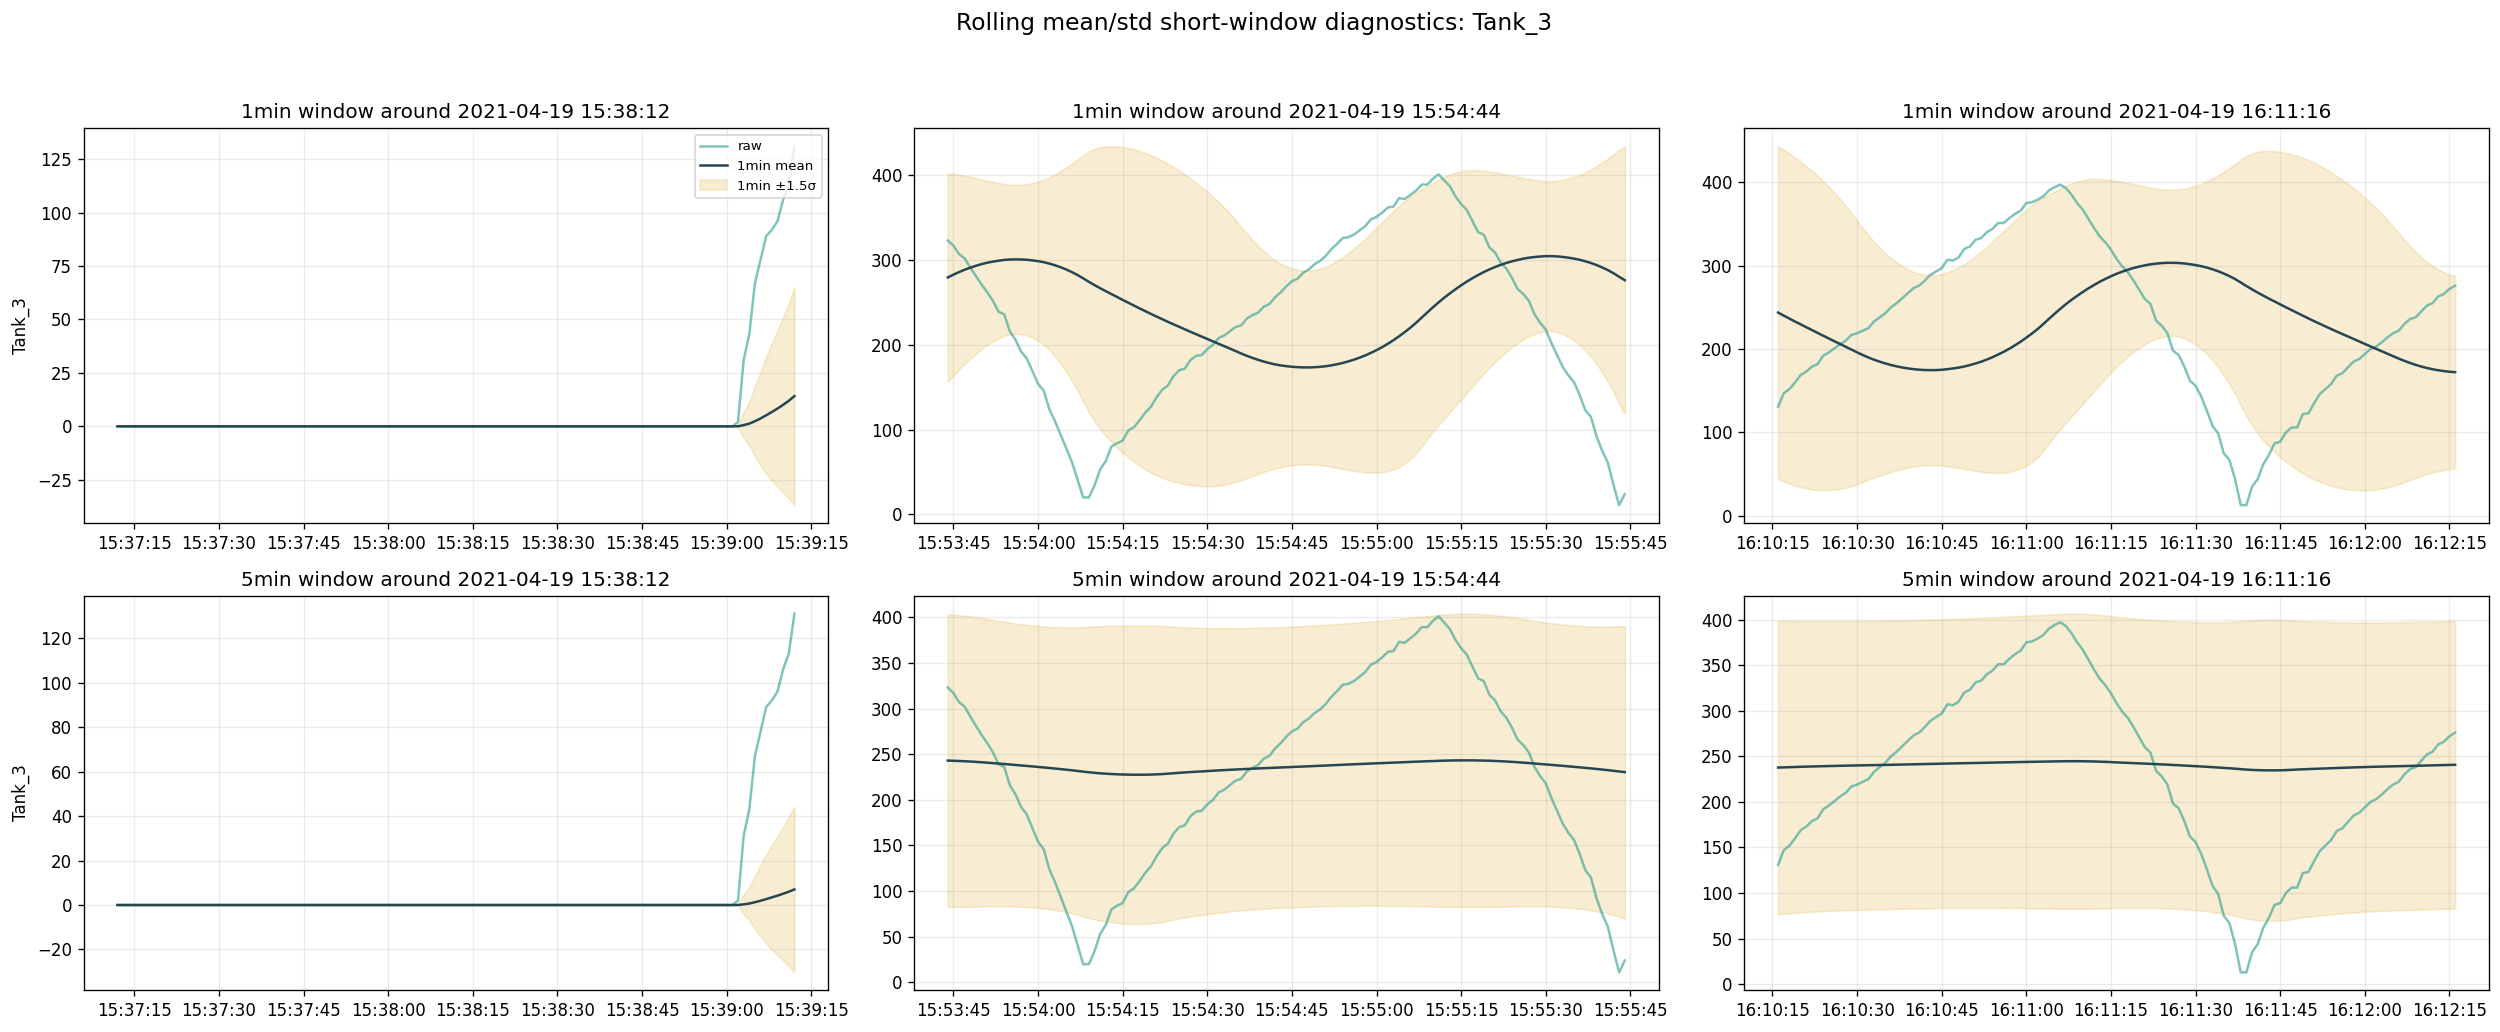

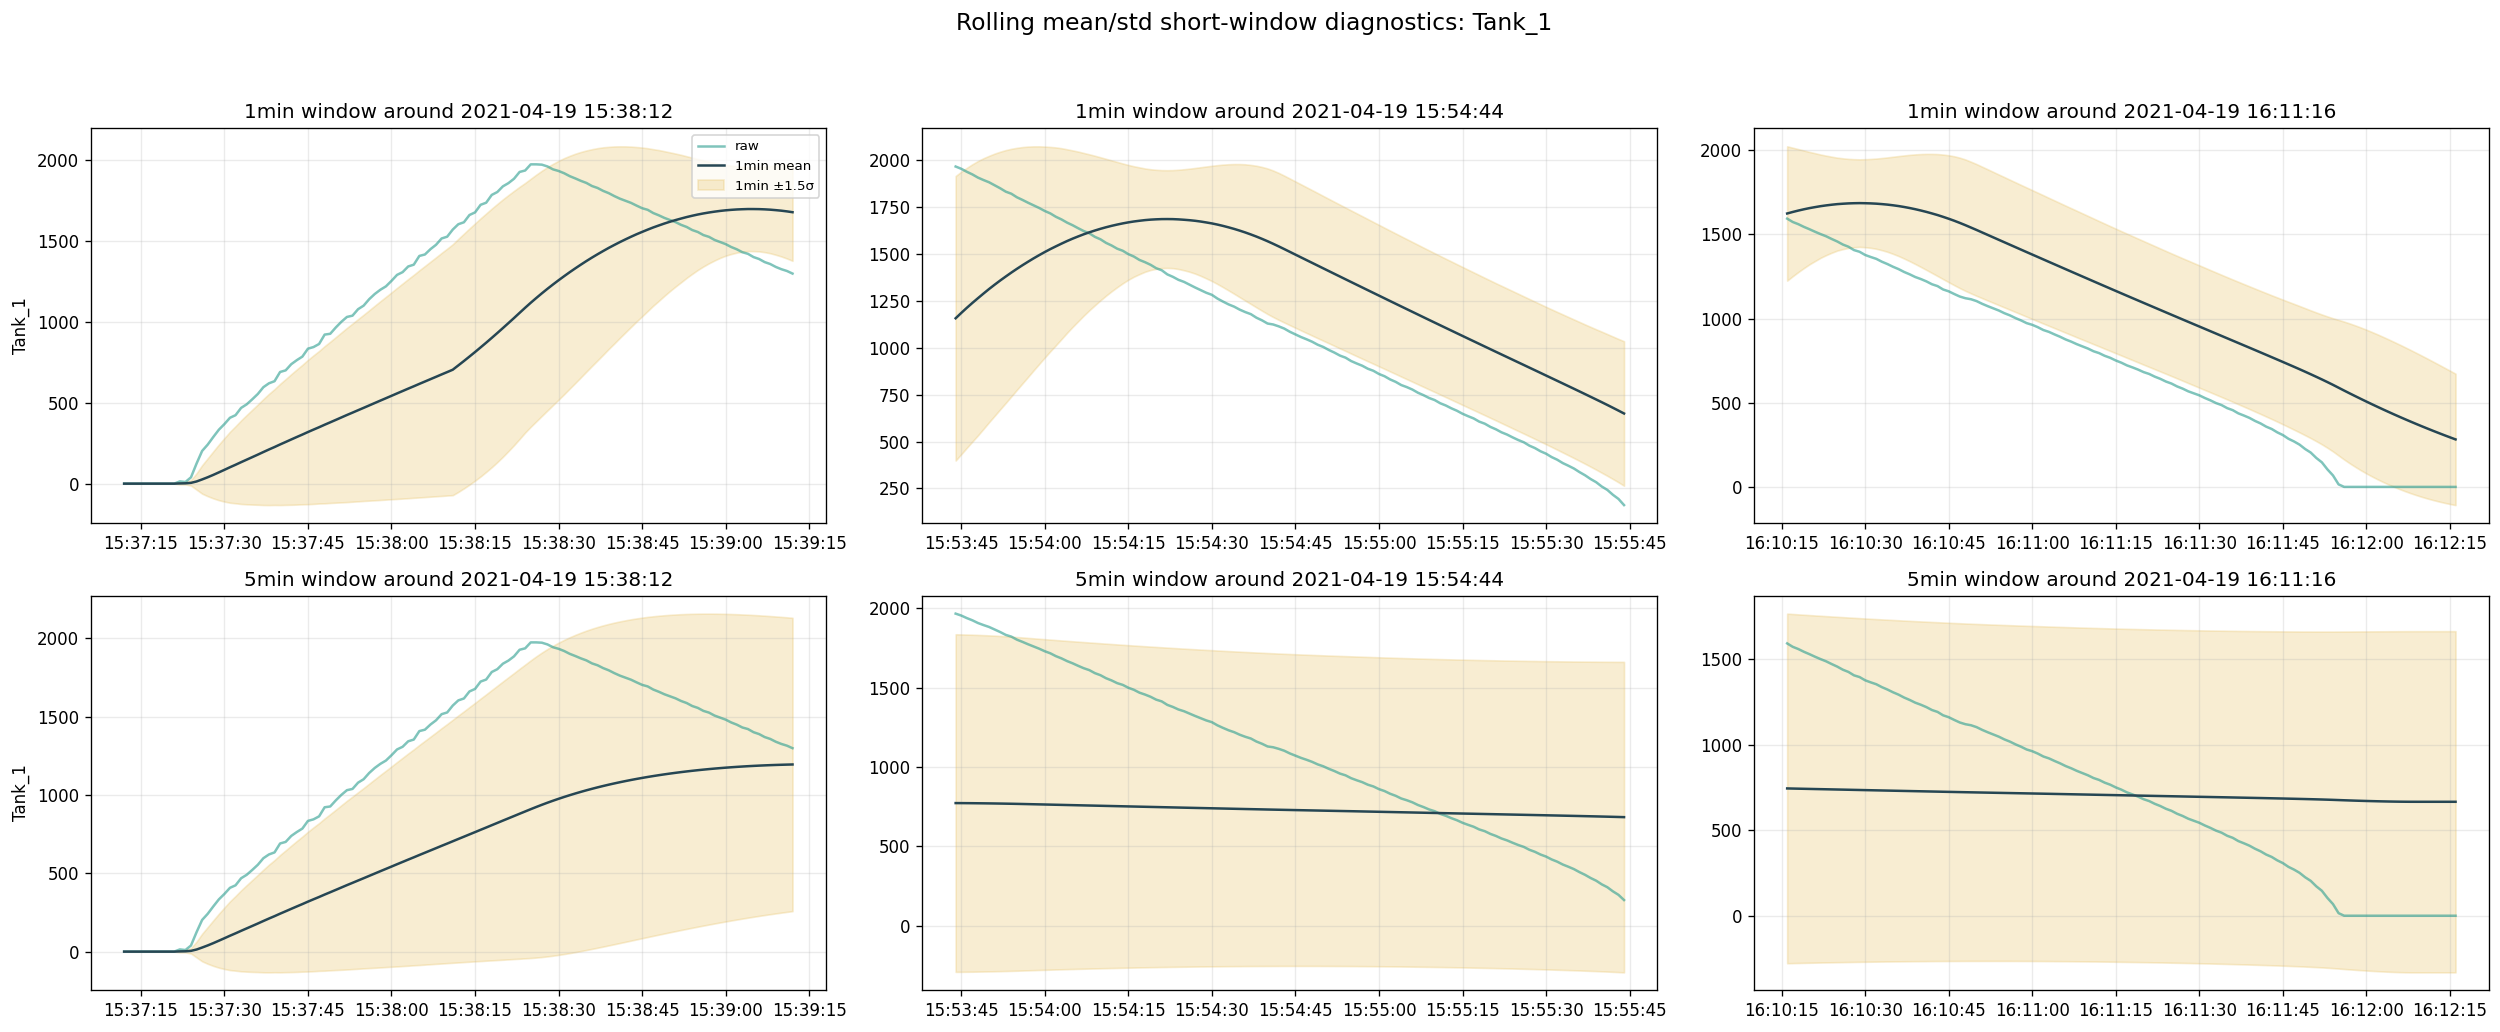

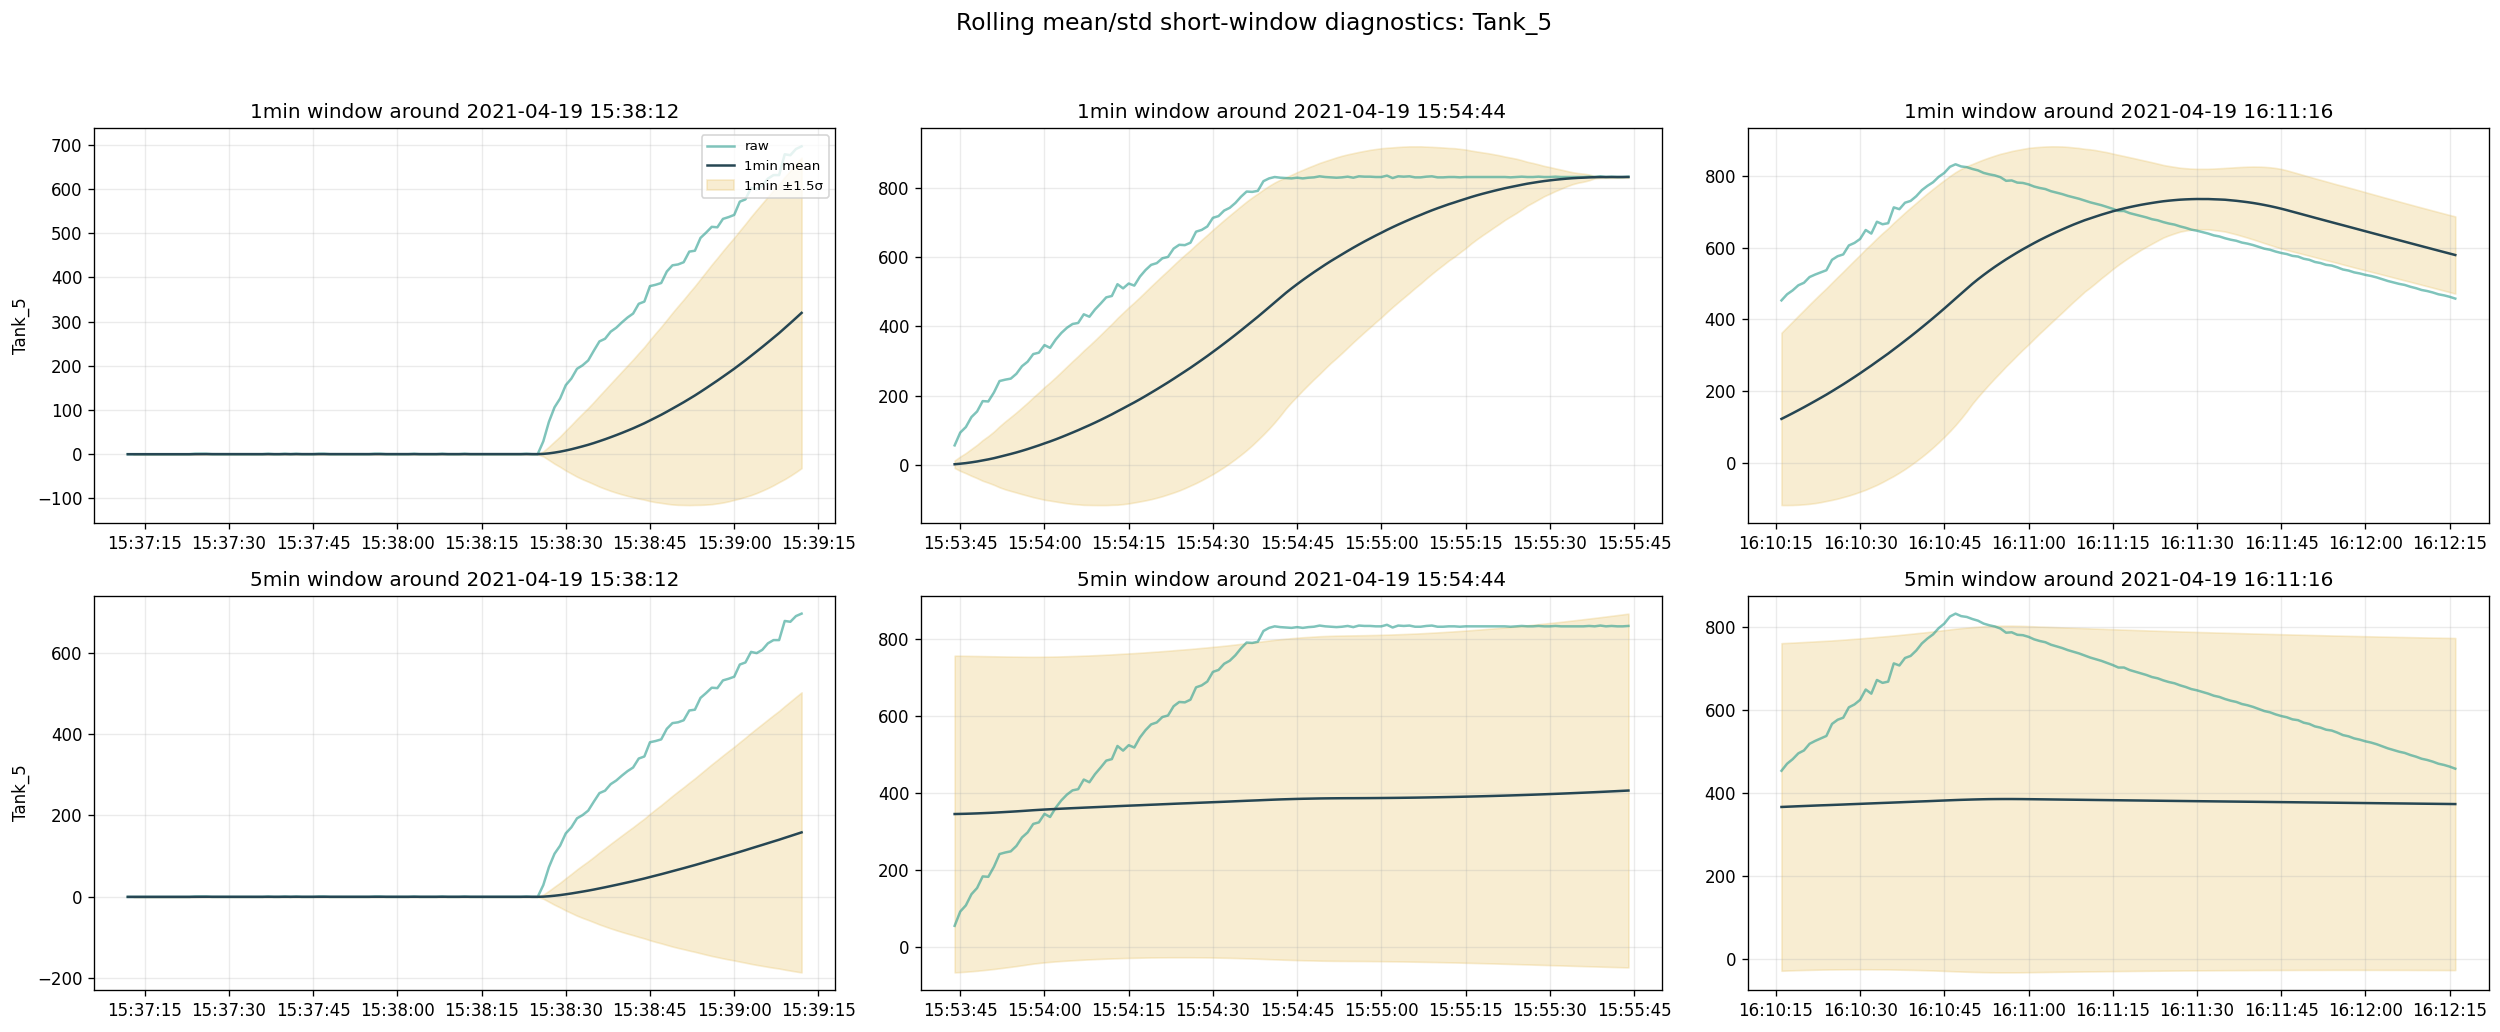

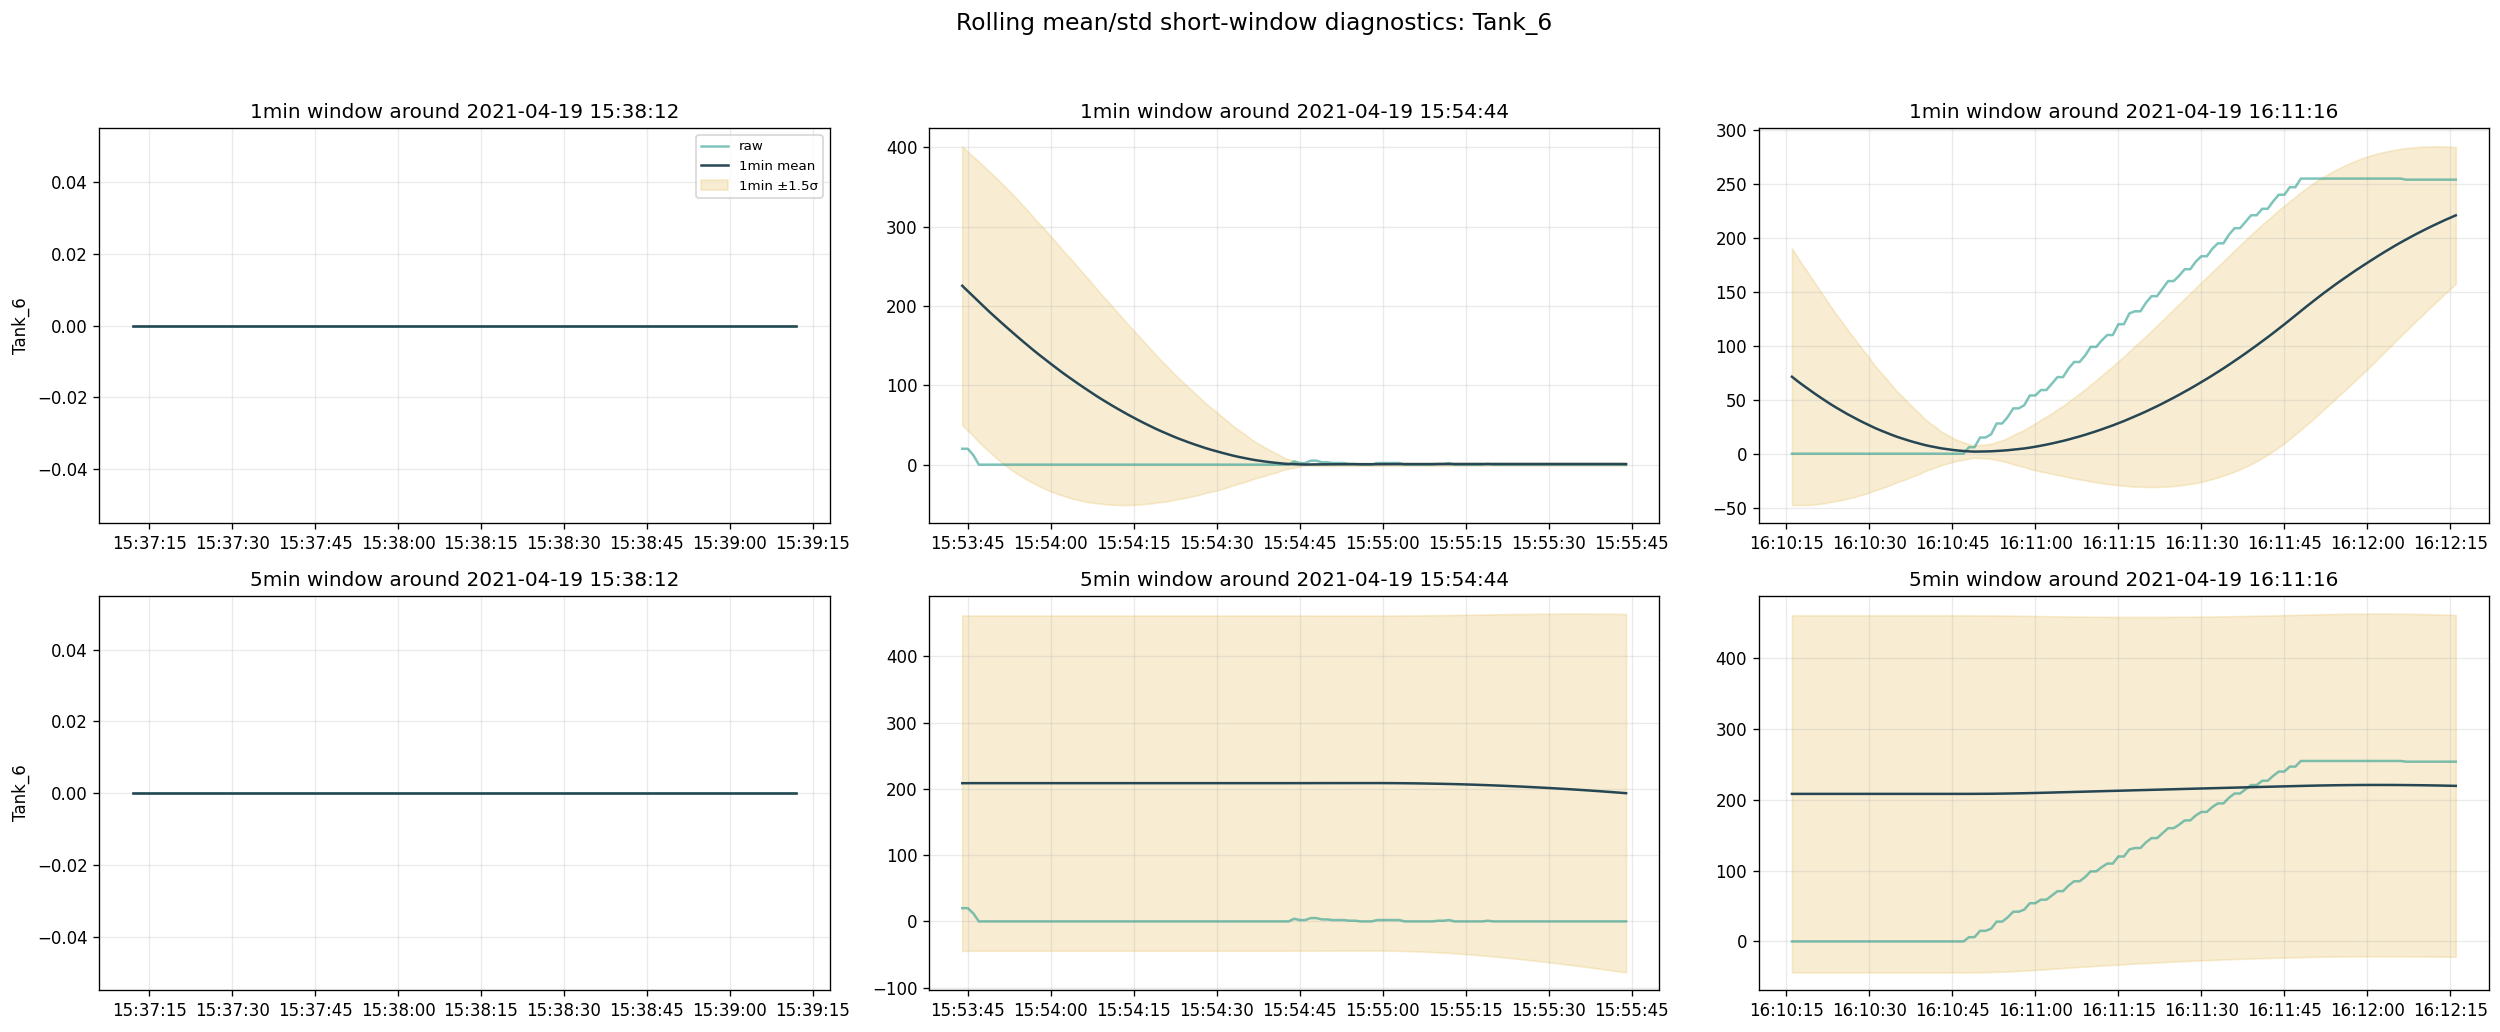

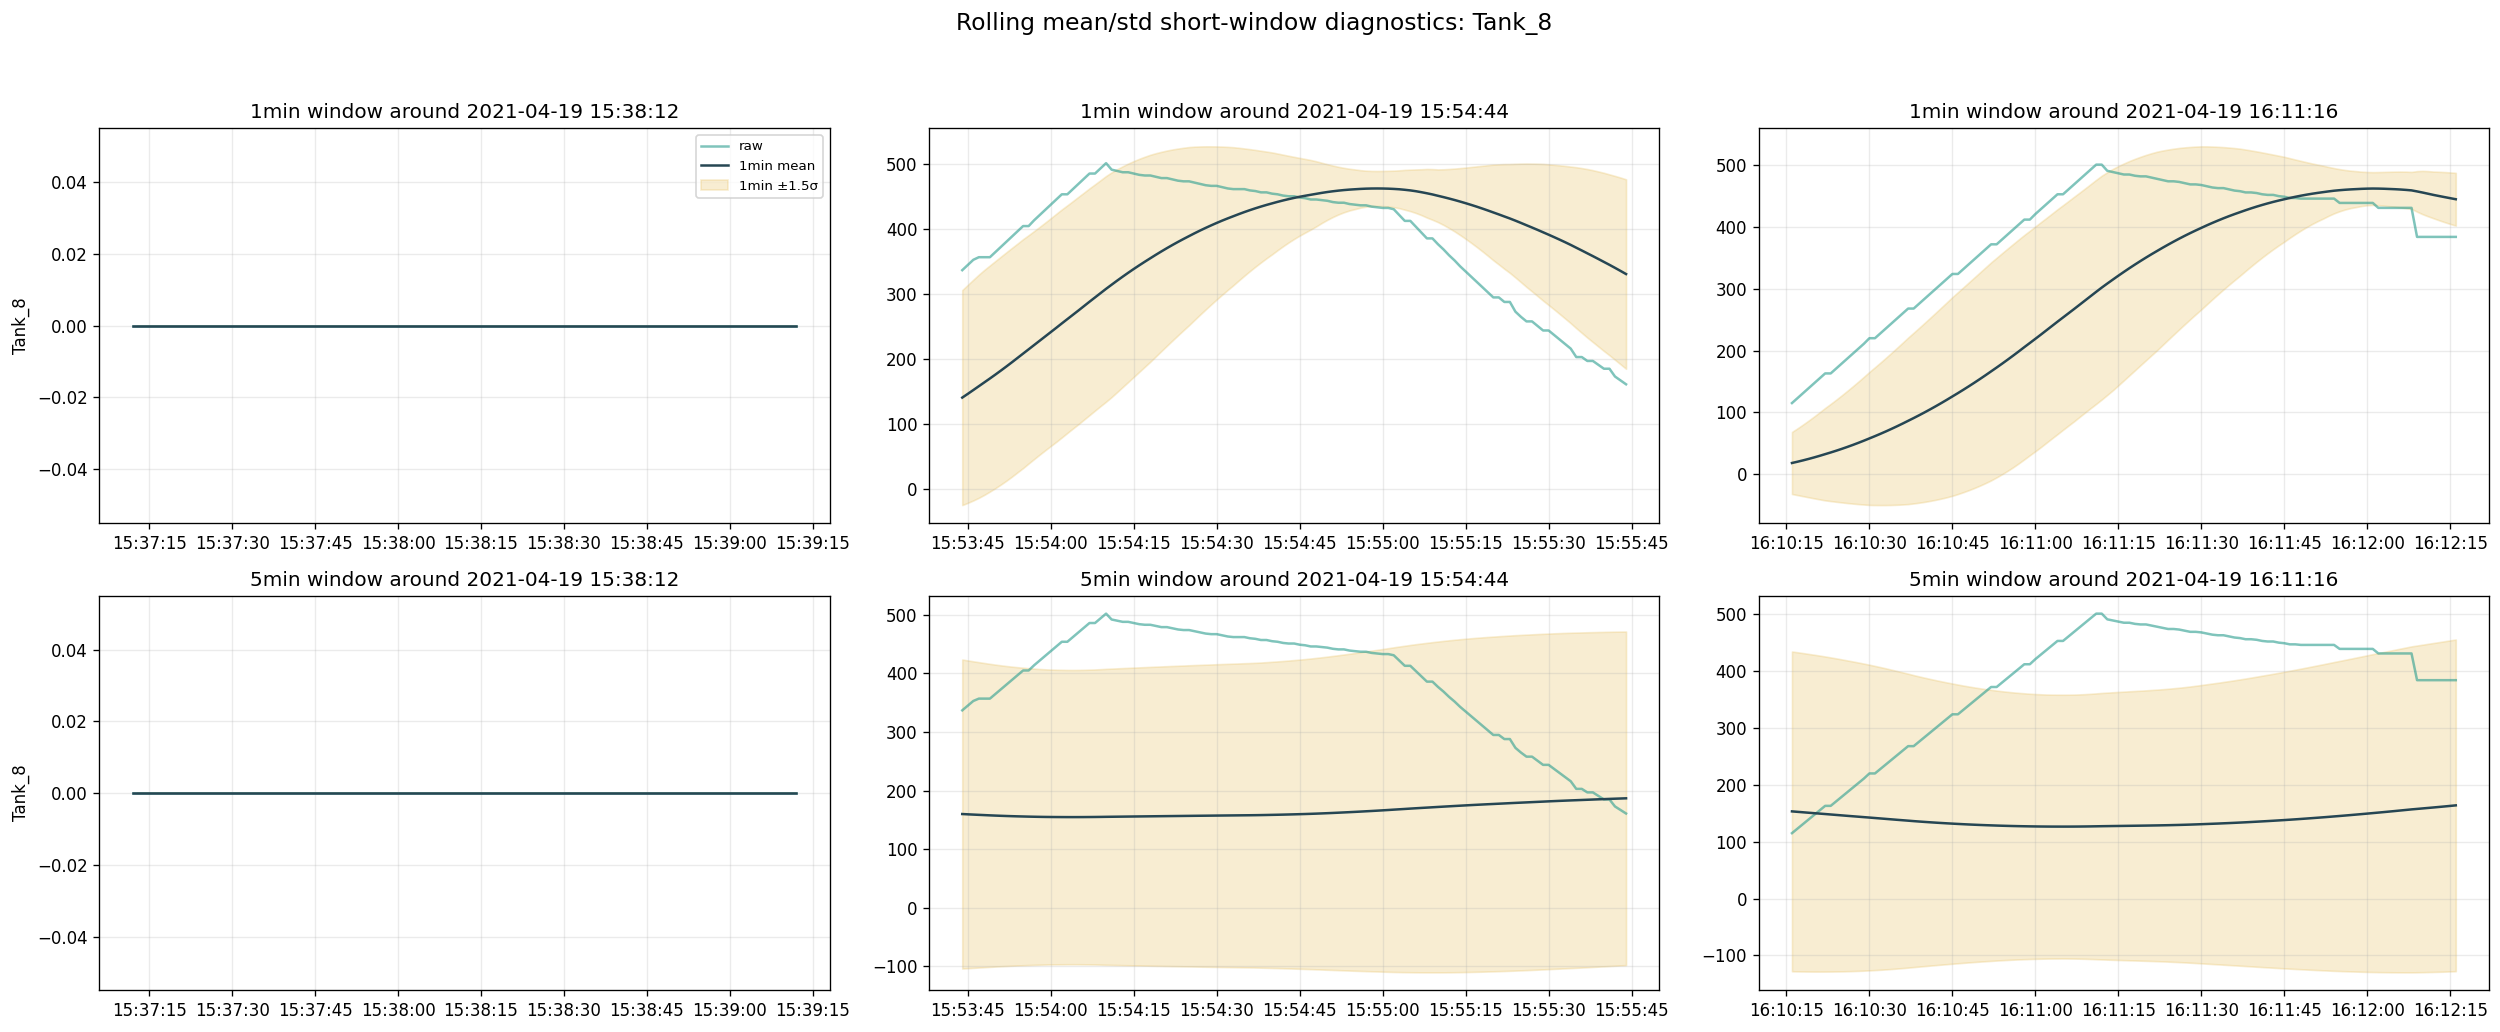

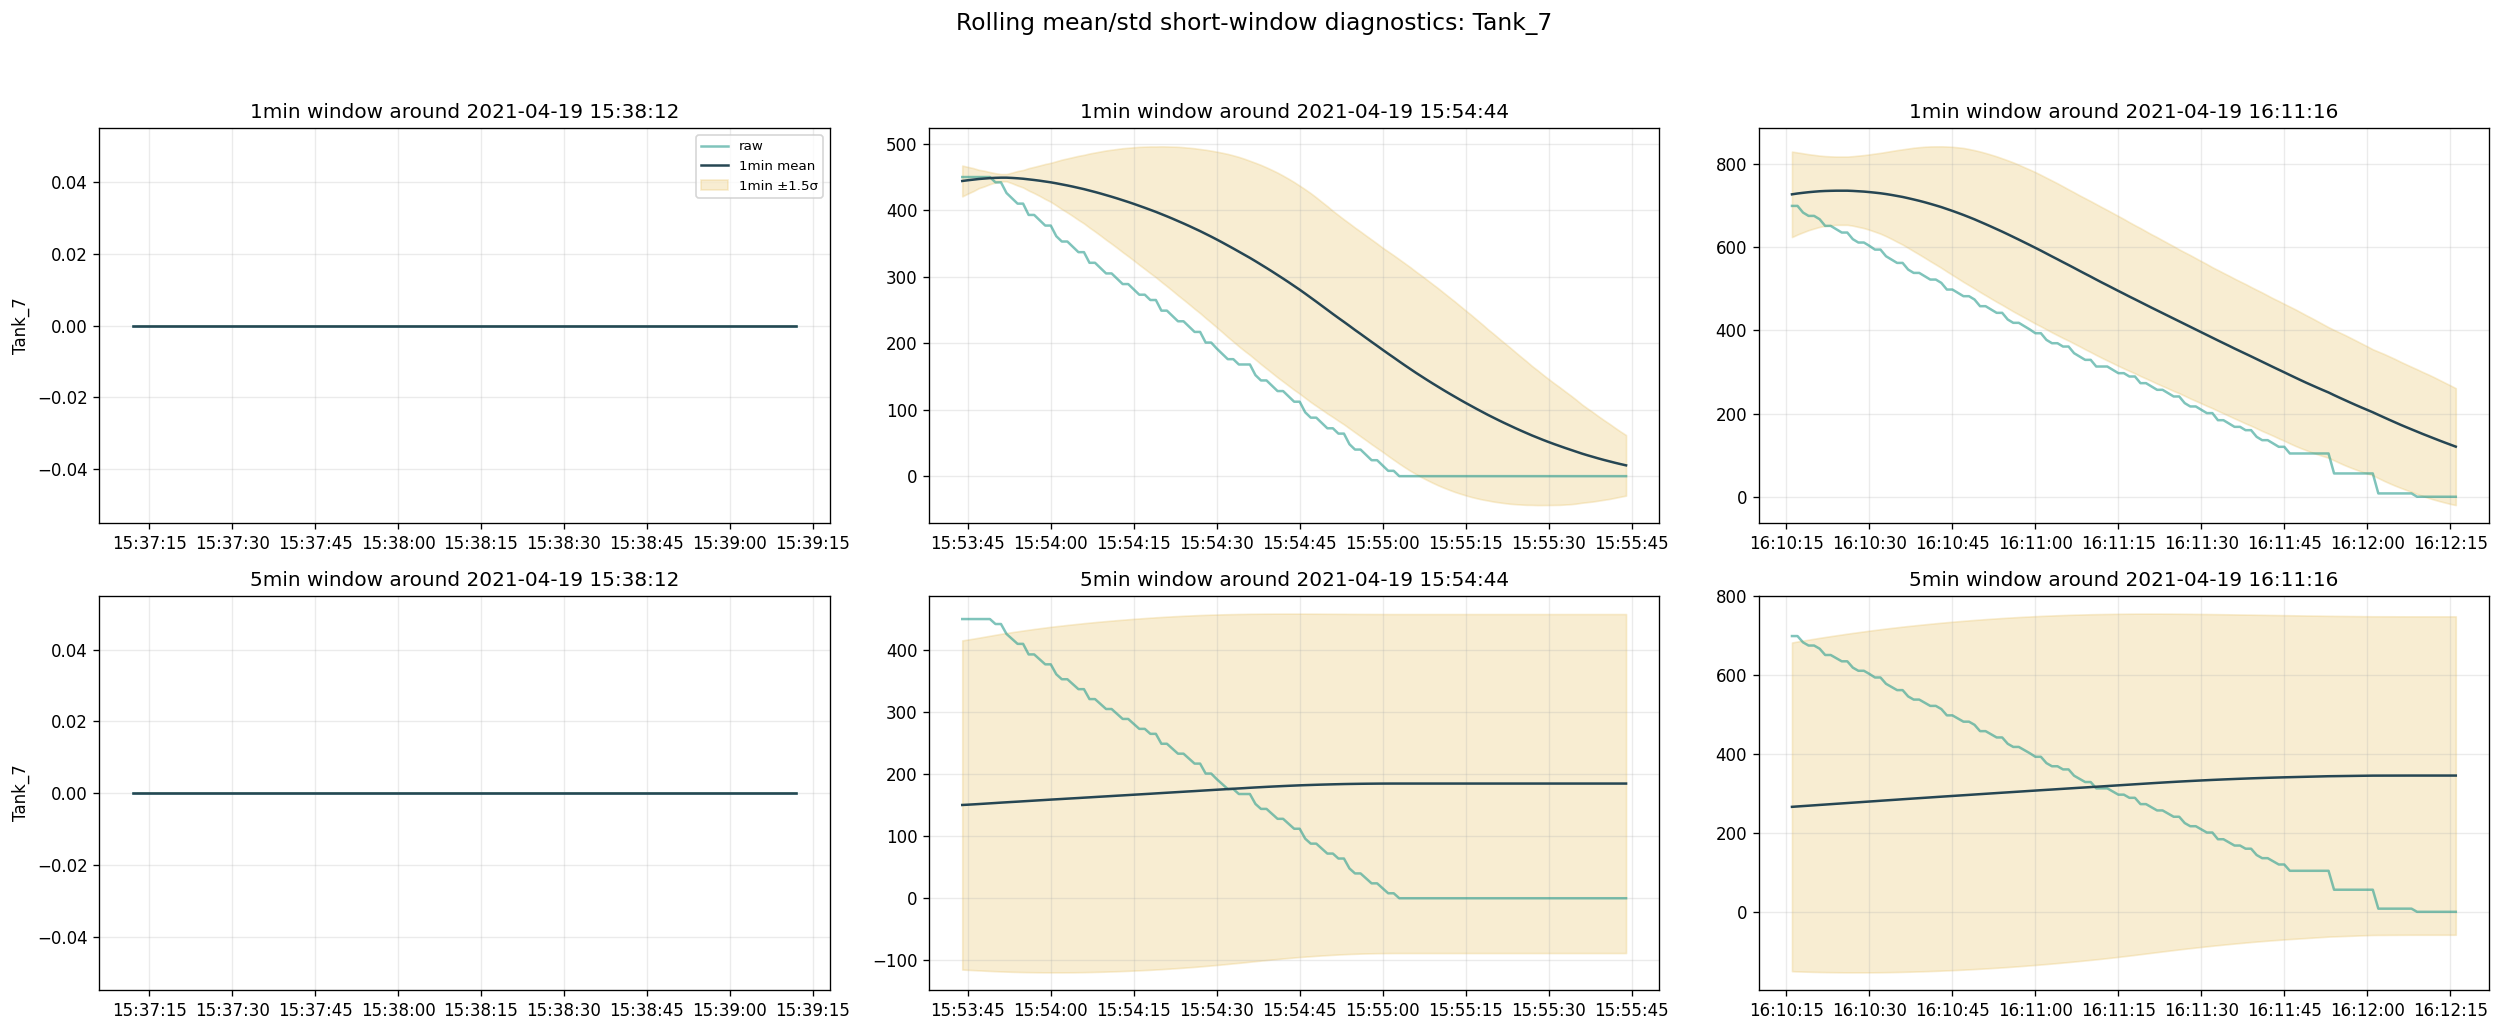

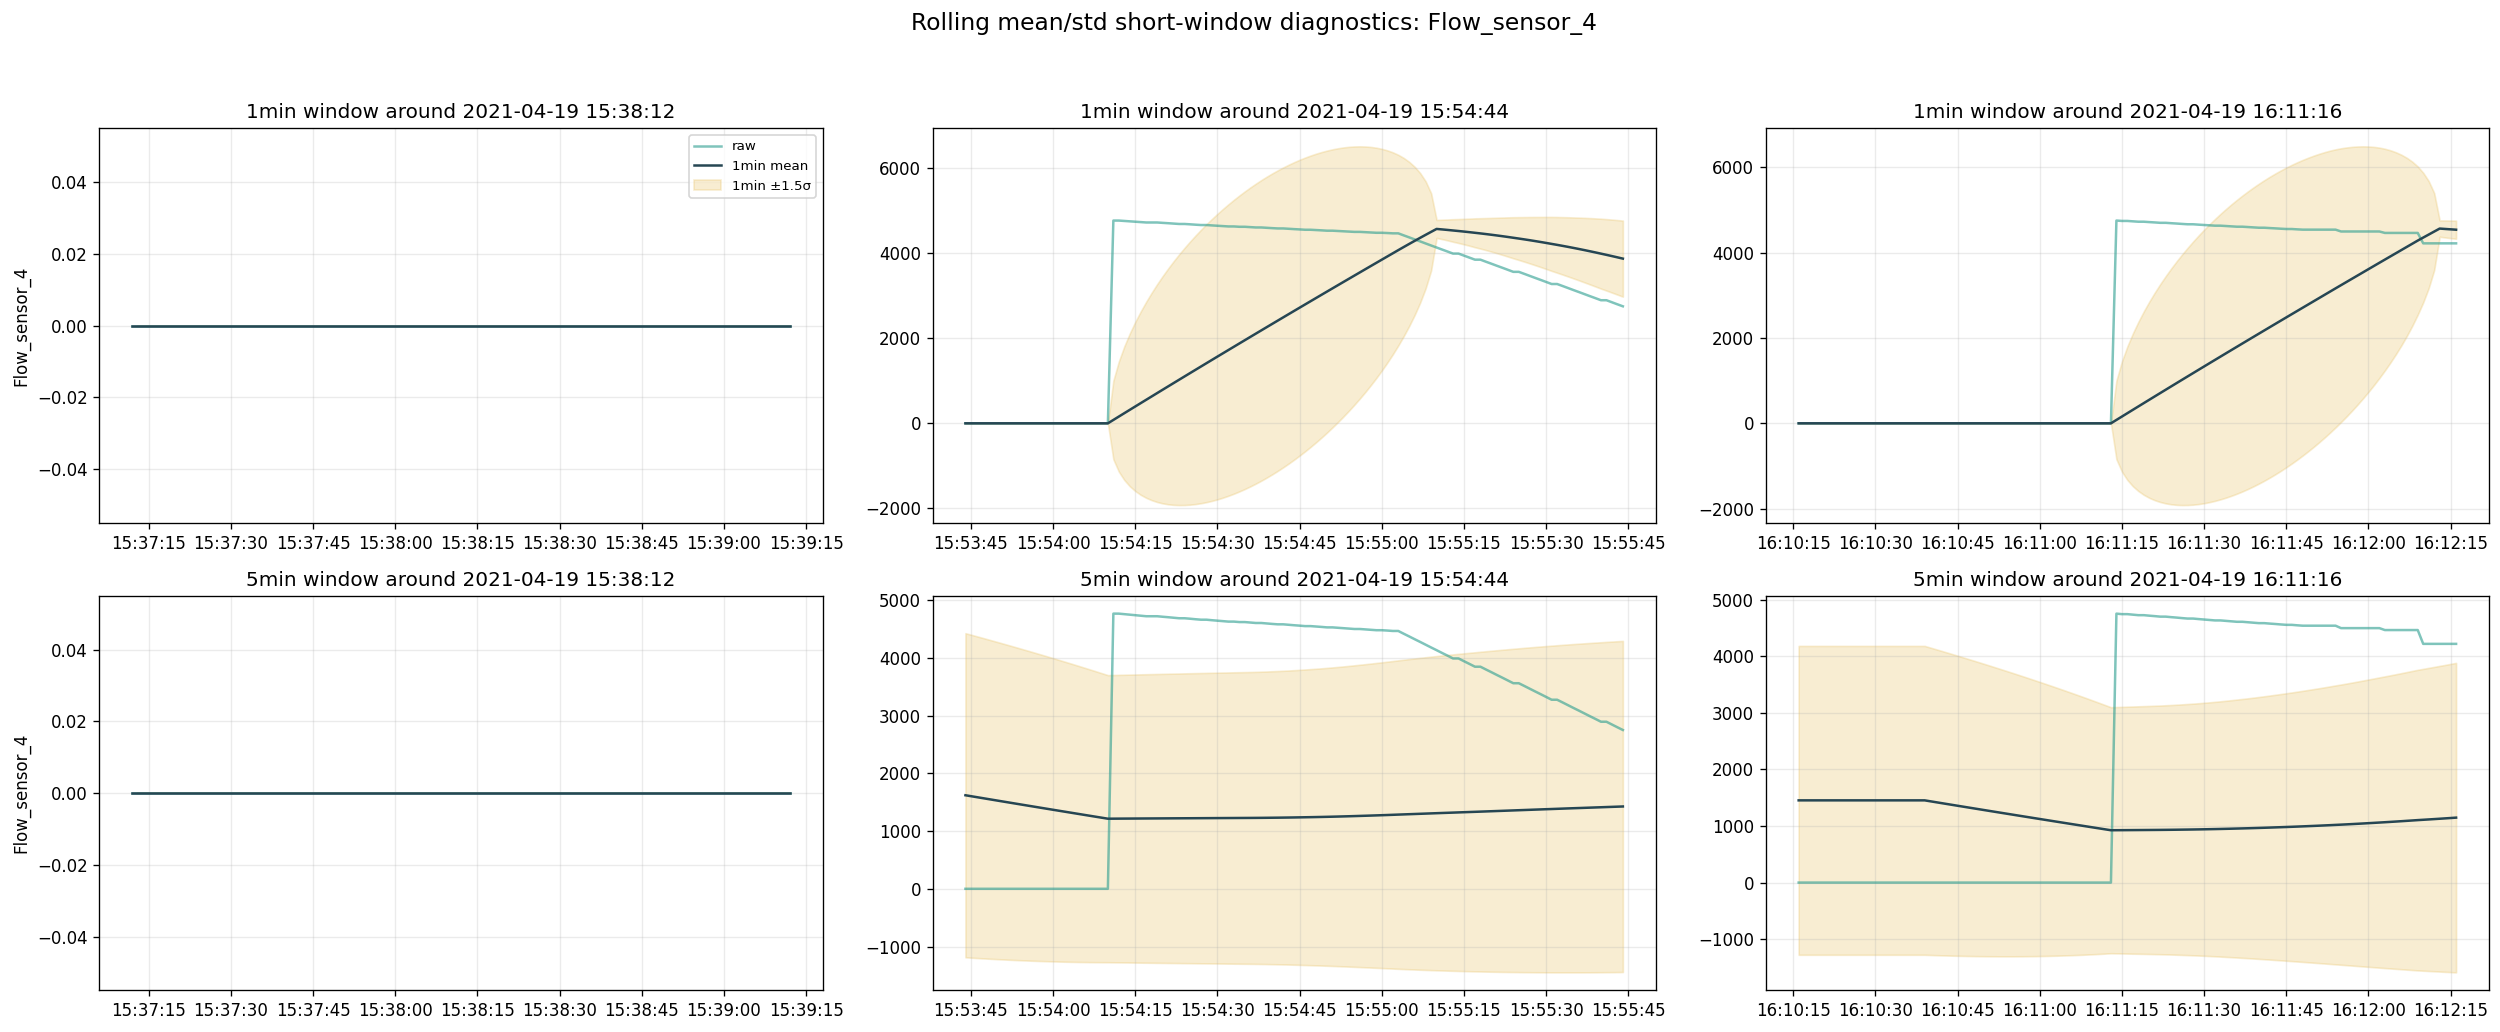

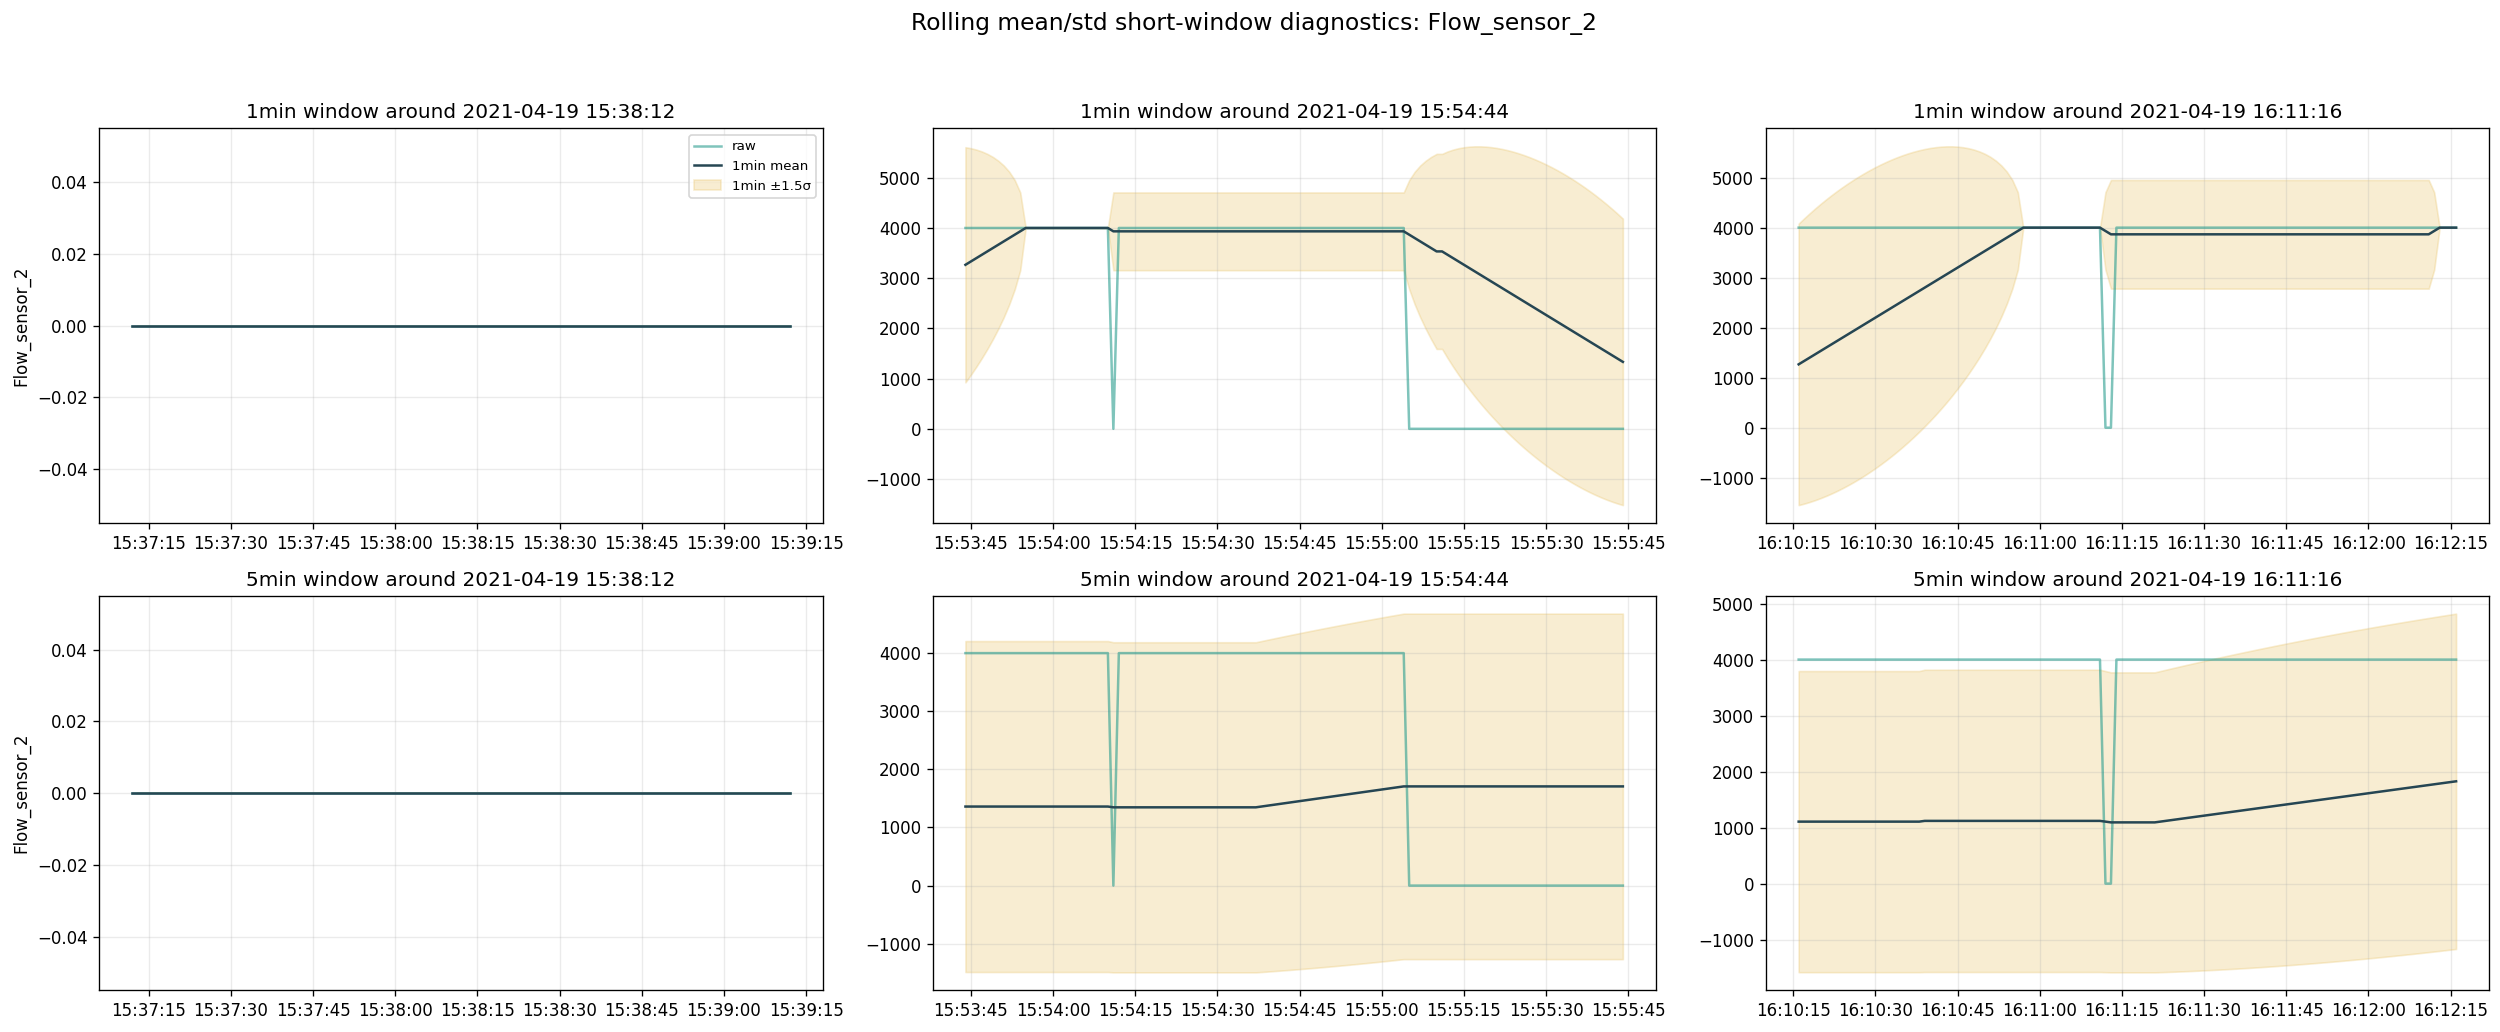

In [ ]:
# Rolling mean/std diagnostics with wider+taller figures
TIME_COL = 'Time'
df_ts = df_ts.copy()
if df_ts.index.name != TIME_COL:
    df_ts = df_ts.set_index(TIME_COL)
df_ts.index = pd.to_datetime(df_ts.index)

try:
    flagged = sensor_issue_report[sensor_issue_report['flags'] != 'ok']['sensor'].tolist()
except Exception:
    flagged = []
tank_flow = [c for c in df_ts.columns if c.startswith('Tank_') or c.startswith('Flow_sensor')]
sensors = list(dict.fromkeys(flagged + tank_flow))[:8]

windows = {'1min': '60s', '5min': '300s'}
plot_window_seconds = 120
centers = [
    df_ts.index[0] + pd.Timedelta(seconds=plot_window_seconds//2),
    df_ts.index[len(df_ts)//2],
    df_ts.index[-1] - pd.Timedelta(seconds=plot_window_seconds//2)
]

for sensor in sensors:
    if sensor not in df_ts.columns:
        continue
    series = pd.to_numeric(df_ts[sensor], errors='coerce')

    # Wider and a little taller: increase width multiplier from 5 to 7, height from 4 to 4.5
    fig, axes = plt.subplots(len(windows), len(centers),
                             figsize=(7*len(centers), 4.5*len(windows)), dpi=120, sharey=False)
    if len(windows) == 1:
        axes = np.atleast_2d(axes)
    fig.suptitle(f"Rolling mean/std short-window diagnostics: {sensor}", fontsize=14)

    for r_i, (label, win) in enumerate(windows.items()):
        roll_mean = series.rolling(win, min_periods=1).mean()
        roll_std  = series.rolling(win, min_periods=1).std()

        for c_i, center in enumerate(centers):
            start = center - pd.Timedelta(seconds=plot_window_seconds//2)
            end   = center + pd.Timedelta(seconds=plot_window_seconds//2)
            view_idx = (series.index >= start) & (series.index <= end)
            ax = axes[r_i, c_i]

            ax.plot(series.index[view_idx], series[view_idx], color='#2a9d8f', alpha=0.6, label='raw')
            ax.plot(roll_mean.index[view_idx], roll_mean[view_idx], color='#264653', linewidth=1.5, label=f'{label} mean')
            ax.fill_between(
                roll_std.index[view_idx],
                (roll_mean - 1.5*roll_std).loc[view_idx],
                (roll_mean + 1.5*roll_std).loc[view_idx],
                color='#e9c46a', alpha=0.3, label=f'{label} ±1.5σ' if c_i == 0 else None
            )

            ax.set_title(f"{label} window around {center.strftime('%Y-%m-%d %H:%M:%S')}")
            ax.set_xlabel('')
            if c_i == 0:
                ax.set_ylabel(sensor)
            ax.grid(alpha=0.25)
            if r_i == 0 and c_i == 0:
                ax.legend(loc='upper right', fontsize=8)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    fig.savefig(OUTPUT_DIR / "rollingmean_std_short_window.png", dpi=150, bbox_inches='tight')
    plt.show()

Found anomaly rows: 2025


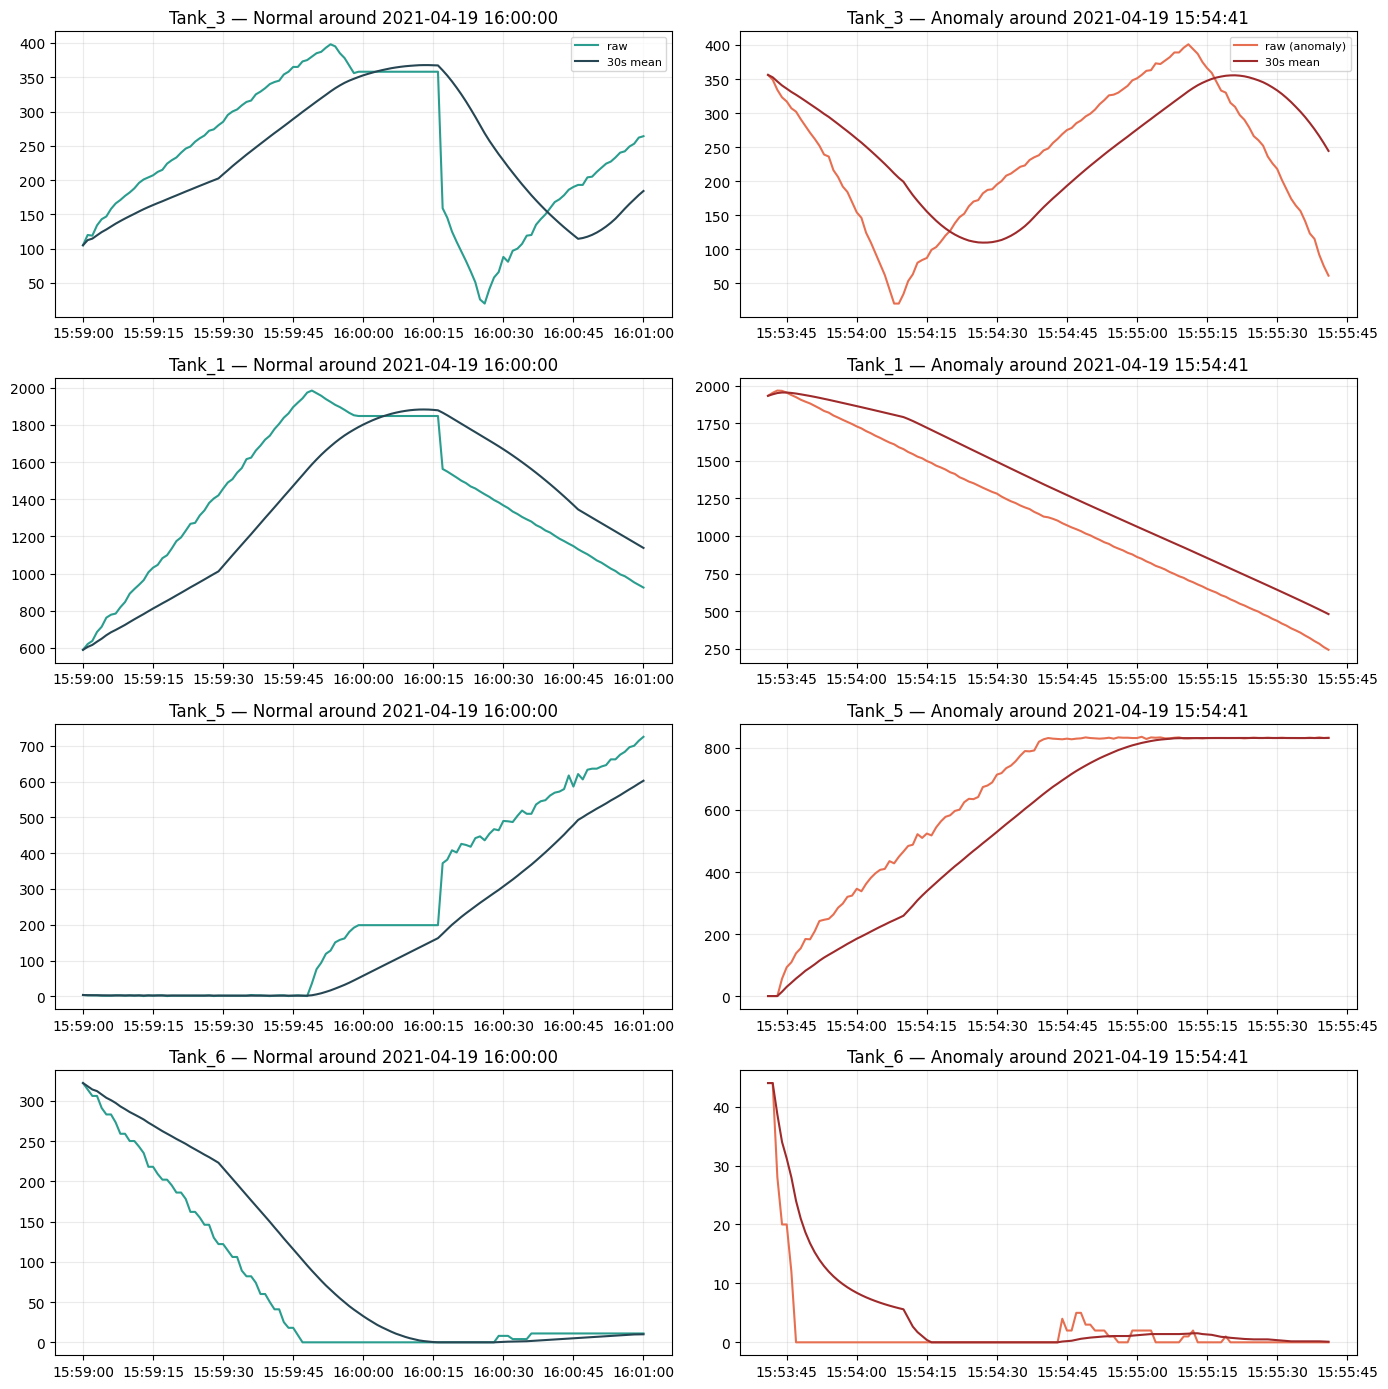

In [ ]:
# Plot example traces during normal vs labeled-anomaly periods
# Prep: ensure Time index and label column exist
df_plot = df_ts.copy()
if df_plot.index.name != 'Time':
    df_plot = df_plot.set_index('Time')
df_plot.index = pd.to_datetime(df_plot.index)

# Determine label column: prefer Label_encoded, fall back to Label or Label_n
if 'Label_encoded' in df_plot.columns:
    label_col = 'Label_encoded'
elif 'Label' in df_plot.columns:
    label_col = 'Label'
elif 'Label_n' in df_plot.columns:
    label_col = 'Label_n'
else:
    # if no labels, create a zero column and abort gracefully
    df_plot['Label_encoded'] = 0
    label_col = 'Label_encoded'

# Identify anomaly vs normal timestamps (anomaly defined as non-zero or non-'normal')
if label_col == 'Label_encoded' or df_plot[label_col].dtype.kind in 'iuf':
    anomaly_mask = df_plot[label_col].astype(int) != 0
else:
    # treat anything not equal to a likely 'normal' token as anomaly
    normal_tokens = {'normal', 'Normal', '0', 0}
    anomaly_mask = ~df_plot[label_col].isin(normal_tokens)

# If no anomalies found, notify in print and still show normal windows
n_anom = int(anomaly_mask.sum())
print(f"Found anomaly rows: {n_anom}")

# Choose sensors to plot (top flagged sensors if available, else Tanks + Flow)
try:
    flagged = sensor_issue_report[sensor_issue_report['flags']!='ok']['sensor'].tolist()
except Exception:
    flagged = []
candidates = flagged + [c for c in df_plot.columns if c.startswith('Tank_') or c.startswith('Flow_sensor')]
sensors = [c for c in candidates if c in df_plot.columns][:4]  # plot up to 4 sensors

if len(sensors) == 0:
    raise RuntimeError("No suitable sensors found (Tank_*/Flow_sensor_*).")

# Helper: select short window around a timestamp
def get_window_around(ts, half_seconds=60):
    start = ts - pd.Timedelta(seconds=half_seconds)
    end = ts + pd.Timedelta(seconds=half_seconds)
    return df_plot.loc[start:end]

# Choose example center times:
# - for normal: pick median time among rows labeled normal
# - for anomaly: pick median time among anomaly rows (if any)
normal_idx = df_plot.index[~anomaly_mask]
anomaly_idx = df_plot.index[anomaly_mask]

if len(normal_idx) == 0:
    raise RuntimeError("No normal timestamps available to sample.")
normal_center = normal_idx[len(normal_idx)//2]

if len(anomaly_idx) > 0:
    anomaly_center = anomaly_idx[len(anomaly_idx)//2]
else:
    anomaly_center = None

# Plot side-by-side: normal | anomaly (if available)
fig_width = 14
fig_height = 3.5 * len(sensors)
fig, axes = plt.subplots(len(sensors), 2 if anomaly_center is not None else 1,
                         figsize=(fig_width, fig_height), sharex=False)
if len(sensors) == 1:
    axes = np.atleast_2d(axes)

for i, sensor in enumerate(sensors):
    # normal window
    normal_win = get_window_around(normal_center, half_seconds=60)
    ax_norm = axes[i, 0] if anomaly_center is not None else axes[i, 0]
    ax_norm.plot(normal_win.index, normal_win[sensor], color='#2a9d8f', label='raw')
    ax_norm.plot(normal_win[sensor].rolling('30s', min_periods=1).mean(), color='#264653', linewidth=1.5, label='30s mean')
    ax_norm.set_title(f"{sensor} — Normal around {normal_center.strftime('%Y-%m-%d %H:%M:%S')}")
    ax_norm.grid(alpha=0.25)
    if i == 0:
        ax_norm.legend(loc='upper right', fontsize=8)

    # anomaly window (if exists)
    if anomaly_center is not None:
        an_win = get_window_around(anomaly_center, half_seconds=60)
        ax_an = axes[i, 1]
        ax_an.plot(an_win.index, an_win[sensor], color='#e76f51', label='raw (anomaly)')
        ax_an.plot(an_win[sensor].rolling('30s', min_periods=1).mean(), color='#9e2a2b', linewidth=1.5, label='30s mean')
        ax_an.set_title(f"{sensor} — Anomaly around {anomaly_center.strftime('%Y-%m-%d %H:%M:%S')}")
        ax_an.grid(alpha=0.25)
        if i == 0:
            ax_an.legend(loc='upper right', fontsize=8)

# Layout tweaks
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "normal_versus_labeled_anomalies.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Free up some memory
import gc
gc.collect()

194152

## 4.3 Correlation and dependency structure

Numeric columns: ['Tank_1', 'Tank_2', 'Tank_3', 'Tank_4', 'Tank_5', 'Tank_6', 'Tank_7', 'Tank_8', 'Flow_sensor_1', 'Flow_sensor_2', 'Flow_sensor_4']


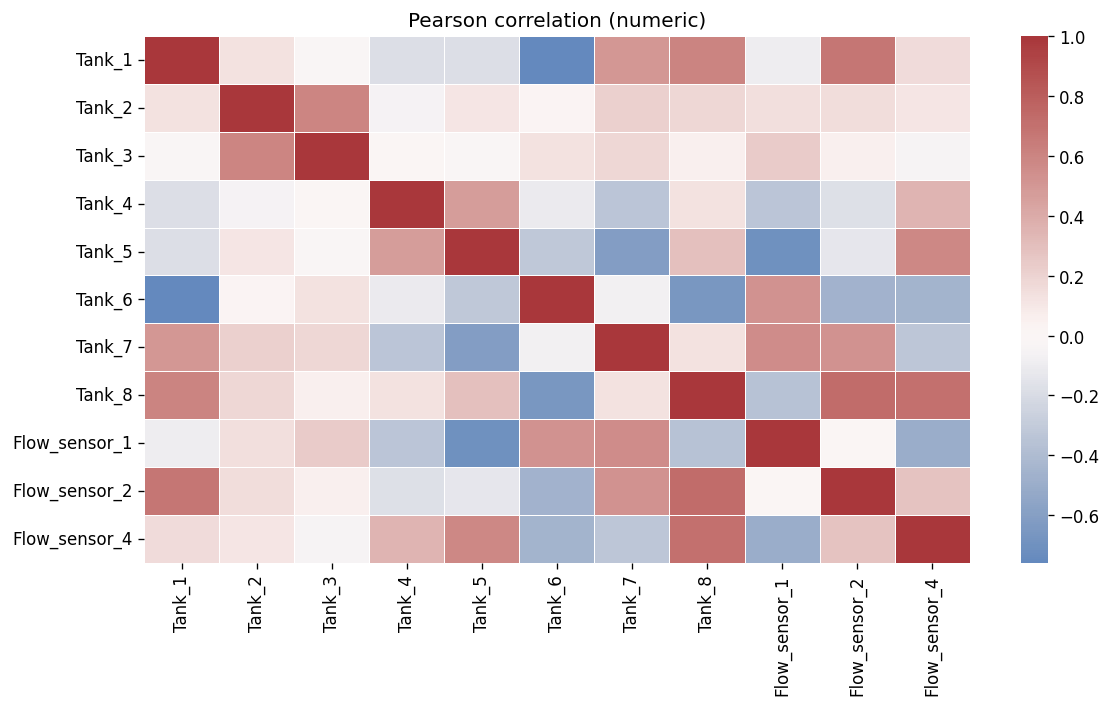

Top numeric absolute correlations:


,var1,var2,abs_corr
5,Tank_1,Tank_6,0.758657
55,Tank_6,Tank_1,0.758657
86,Tank_8,Flow_sensor_2,0.729319
106,Flow_sensor_2,Tank_8,0.729319
52,Tank_5,Flow_sensor_1,0.707446
92,Flow_sensor_1,Tank_5,0.707446
87,Tank_8,Flow_sensor_4,0.705633
117,Flow_sensor_4,Tank_8,0.705633
99,Flow_sensor_2,Tank_1,0.672749
9,Tank_1,Flow_sensor_2,0.672749


In [ ]:
# 1) Pearson correlations for numeric columns + heatmap and top pairs
# numeric columns (exclude label)
num_cols = [c for c in df_ts.columns if df_ts[c].dtype.kind in "iuf" and c != 'Label_encoded']
print("Numeric columns:", num_cols)

# Pearson correlation matrix
pearson = df_ts[num_cols].corr(method='pearson')

# Heatmap
plt.figure(figsize=(10, max(6, len(num_cols)*0.25)), dpi=120)
sns.heatmap(pearson, annot=False, cmap='vlag', center=0, linewidths=0.3)
plt.title('Pearson correlation (numeric)')
plt.tight_layout()
plt.show()

# Top absolute correlations (exclude self)
corr_pairs = (
    pearson.abs()
           .stack()
           .reset_index()
           .rename(columns={'level_0':'var1','level_1':'var2',0:'abs_corr'})
)
corr_pairs = corr_pairs[corr_pairs['var1'] != corr_pairs['var2']]
corr_pairs = corr_pairs.sort_values('abs_corr', ascending=False).drop_duplicates(subset=['abs_corr','var1'])
top_pairs = corr_pairs.head(30)
print("Top numeric absolute correlations:")
display(top_pairs[['var1','var2','abs_corr']].head(30))

Using sampling interval ~1.000 s; MAX_LAG_SECONDS=60
Max lag in steps: 60


,sensor_a,sensor_b,peak_corr,peak_lag_s,n_samples
0,Tank_1,Flow_sensor_1,-0.722406,-60.0,2105
1,Tank_2,Flow_sensor_2,0.212146,-49.0,2105


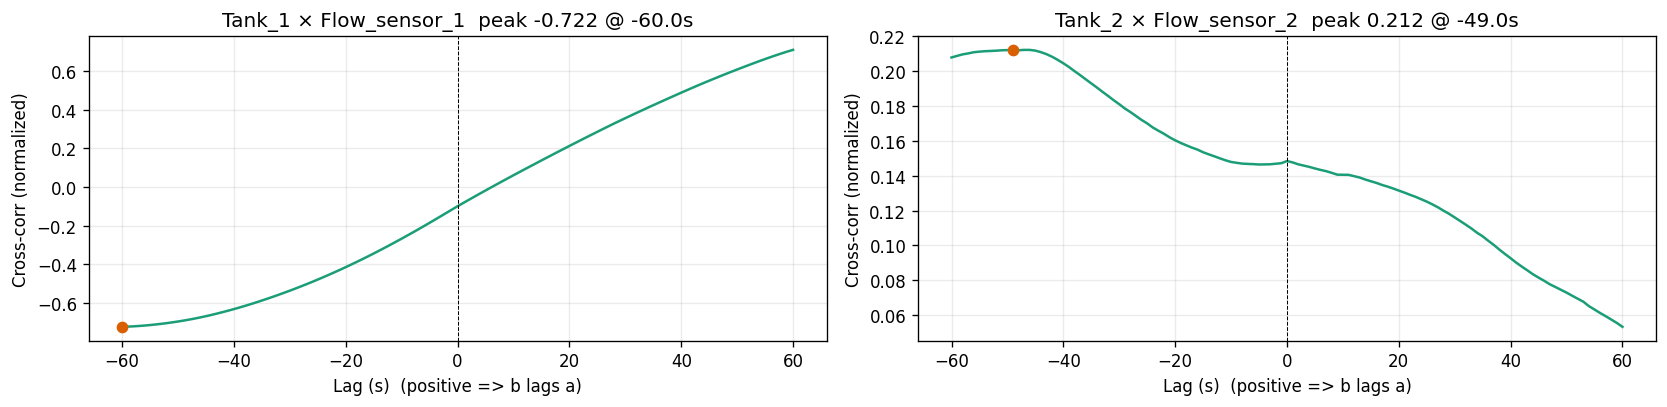

In [ ]:
# Cross-correlation lag analysis for key sensor pairs
# Helpers ---------------------------------------------------------
def series_for_xcorr(df, col, start=None, end=None, fill_method='ffill'):
    """Return a numeric series aligned on df.index (datetime index), dtype=float."""
    s = pd.to_numeric(df[col], errors='coerce')
    if start is not None or end is not None:
        s = s.loc[start:end]
    # fill small gaps conservatively for xcorr; caller controls resampling cadence
    if fill_method == 'ffill':
        s = s.ffill().bfill()
    return s.astype(float)

def xcorr_full(a, b, demean=True):
    """Compute full (unnormalized) cross-correlation array between equal-length 1D arrays.
    Returns lags (neg..pos) and correlation coefficients normalized to [-1,1]."""
    assert len(a) == len(b)
    if demean:
        a = a - np.nanmean(a)
        b = b - np.nanmean(b)
    # replace NaNs with zero (after demeaning), caller should handle gaps/resampling
    a = np.nan_to_num(a)
    b = np.nan_to_num(b)
    n = len(a)
    # FFT-based fast cross-correlation
    fa = np.fft.rfft(a, n=2*n)
    fb = np.fft.rfft(b, n=2*n)
    cc = np.fft.irfft(fa * np.conj(fb), n=2*n)
    cc = np.concatenate((cc[-(n-1):], cc[:n]))  # shift to lags -(n-1)..(n-1)
    # normalize to produce Pearson-like coefficient for each lag
    denom = np.sqrt(np.sum(a*a) * np.sum(b*b))
    if denom == 0:
        corr = np.zeros_like(cc)
    else:
        corr = cc / denom
    lags = np.arange(-(n-1), n)
    return lags, corr
# ---------------------------------------------------------------

# Configuration: pick sensor pairs or use top numeric sensors
SAMPLING_FREQ = None   # if None infer from df_ts.index spacing (seconds)
MAX_LAG_SECONDS = 60   # search +/- this many seconds
RESAMPLE_FREQ = None   # e.g. "1s" to force regular grid; None uses df_ts as-is (must be regular)

# choose sensors: replace with your preferred list
candidate_numeric = [c for c in df_ts.columns if df_ts[c].dtype.kind in 'iuf' and c != 'Label_encoded']
pairs_to_test = [
    ('Tank_1','Flow_sensor_1'),
    ('Tank_2','Flow_sensor_2'),
]
# fallback: if those don't exist, pick first two numeric pairs
if not all(a in df_ts.columns and b in df_ts.columns for a,b in pairs_to_test):
    pairs_to_test = []
    for i in range(min(6, len(candidate_numeric)-1)):
        pairs_to_test.append((candidate_numeric[i], candidate_numeric[i+1]))
pairs_to_test = pairs_to_test[:10]  # limit number of pairs

# align / optional resample ------------------------------------------------
df_x = df_ts.copy()
if RESAMPLE_FREQ is not None:
    df_x = df_x.set_index('Time') if df_x.index.name != 'Time' else df_x
    df_x = df_x.resample(RESAMPLE_FREQ).ffill().bfill().reset_index().set_index('Time')
# infer sampling interval (seconds)
if SAMPLING_FREQ is None:
    idx = df_x.index
    if len(idx) >= 2:
        inferred = pd.to_timedelta(idx.to_series().diff().dropna().median()).total_seconds()
        SAMPLING_FREQ = inferred if inferred > 0 else 1.0
    else:
        SAMPLING_FREQ = 1.0
print(f"Using sampling interval ~{SAMPLING_FREQ:.3f} s; MAX_LAG_SECONDS={MAX_LAG_SECONDS}")

max_lag_steps = int(np.ceil(MAX_LAG_SECONDS / max(1e-9, SAMPLING_FREQ)))
print("Max lag in steps:", max_lag_steps)

# Run xcorr for each pair and collect summary (max abs corr and lag)
summary = []
detailed_results = {}
for a_col, b_col in pairs_to_test:
    sa = series_for_xcorr(df_x, a_col).to_numpy()
    sb = series_for_xcorr(df_x, b_col).to_numpy()
    # ensure equal length by trimming to min length
    n = min(len(sa), len(sb))
    sa = sa[:n]; sb = sb[:n]
    lags, corr = xcorr_full(sa, sb)
    # focus window around requested max lag steps
    center = len(lags)//2
    window_slice = slice(center - max_lag_steps, center + max_lag_steps + 1)
    lags_window = lags[window_slice]
    corr_window = corr[window_slice]
    # convert lag steps to seconds
    lag_seconds = lags_window * SAMPLING_FREQ
    # find peak correlation (abs)
    idx_peak = np.argmax(np.abs(corr_window))
    peak_corr = corr_window[idx_peak]
    peak_lag_s = lag_seconds[idx_peak]
    summary.append({
        'sensor_a': a_col,
        'sensor_b': b_col,
        'peak_corr': float(peak_corr),
        'peak_lag_s': float(peak_lag_s),
        'n_samples': int(n)
    })
    detailed_results[(a_col,b_col)] = {'lags_s': lag_seconds, 'corr': corr_window}

summary_df = pd.DataFrame(summary).sort_values('peak_corr', key=lambda s: s.abs(), ascending=False)
display(summary_df)

# Plot per-pair lag-correlation curves ---------------------------------------
n_pairs = len(detailed_results)
cols = 2
rows = int(np.ceil(n_pairs/cols))
fig, axes = plt.subplots(rows, cols, figsize=(7*cols, 3.5*rows), dpi=120, squeeze=False)
for i, ((a,b), res) in enumerate(detailed_results.items()):
    ax = axes[i//cols, i%cols]
    ax.plot(res['lags_s'], res['corr'], color='#1b9e77')
    ax.axvline(0, color='k', lw=0.6, linestyle='--')
    # mark peak
    peak_idx = np.argmax(np.abs(res['corr']))
    ax.scatter([res['lags_s'][peak_idx]], [res['corr'][peak_idx]], color='#d95f02', zorder=5)
    ax.set_title(f"{a} × {b}  peak {res['corr'][peak_idx]:.3f} @ {res['lags_s'][peak_idx]:.1f}s")
    ax.set_xlabel('Lag (s)  (positive => b lags a)')
    ax.set_ylabel('Cross-corr (normalized)')
    ax.grid(alpha=0.25)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "lag_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
plt.close('all')

Deliverables:
- Distribution plots, boolean-on frequency table, correlations heatmap, representative trace plots.

# Step 5 - Feature engineering for CIS pipeline

Purpose: create features for both graph construction (nodes/edges/attributes) and tabular ML/GNN.

In [ ]:
# Robust feature engineering (use Time as index once; lowercase window tokens)
# copy and ensure a DataTimeIndex
df_feat = df_ts.copy()
if df_feat.index.name != 'Time':
    df_feat = df_feat.set_index('Time')
df_feat.index = pd.to_datetime(df_feat.index)

ROLL_WINDOWS = ['10s', '30s', '60s']   # lowercase 's'
sensor_cols = [c for c in num_cols if ('Tank' in c) or ('Flow_sensor' in c)]

# rolling and diff features
for c in sensor_cols:
    # diff on the indexed frame
    df_feat[f"{c}_diff"] = df_feat[c].diff().fillna(0)
    for w in ROLL_WINDOWS:
        df_feat[f"{c}_rmean_{w}"] = df_feat[c].rolling(w, min_periods=1).mean()
        df_feat[f"{c}_rstd_{w}"]  = df_feat[c].rolling(w, min_periods=1).std().fillna(0)

# Boolean event counts within window (how many actuators on within 30s)
ACT_WINDOW = '30s'
if bool_cols:
    # rolling sum per boolean column then sum across columns -> count of actuators on
    on_counts = df_feat[bool_cols].rolling(ACT_WINDOW, min_periods=1).sum().sum(axis=1).astype(int)
    df_feat['actuators_on_count_30s'] = on_counts

# Time features (derive from index for safety)
df_feat['second_of_day'] = df_feat.index.hour * 3600 + df_feat.index.minute * 60 + df_feat.index.second
df_feat['hour'] = df_feat.index.hour

# finalize: reset index if you want Time as a column again
df_feat = df_feat.reset_index()

# Save feature list for downstream use
feature_cols = [c for c in df_feat.columns if c not in ('Time','Label','Label_n','Label_encoded')]
with open(OUTPUT_DIR / "feature_list.json","w") as f:
    json.dump(feature_cols, f, indent=2)
print("Total features:", len(feature_cols))

Total features: 107


In [ ]:
# Extract raw features: Tank_i, Flow_sensor_i, and boolean Pump/Valv columns
# Ensure df_ts is indexed by Time or has Time column
df_raw = df_ts.copy()
if df_raw.index.name != 'Time' and 'Time' in df_raw.columns:
    df_raw = df_raw.set_index('Time')

# Select columns
tank_cols = [c for c in df_raw.columns if c.startswith('Tank_')]
flow_cols = [c for c in df_raw.columns if c.startswith('Flow_sensor')]
pump_valve_bool_cols = [c for c in df_raw.columns if (c.lower().startswith('pump') or c.lower().startswith('valv')) and df_raw[c].dtype == bool]

raw_feature_cols = tank_cols + flow_cols + pump_valve_bool_cols
print("Raw feature counts:", len(raw_feature_cols))
print("Tanks:", tank_cols)
print("Flows:", flow_cols)
print("Pumps/Valves (bool):", pump_valve_bool_cols)

# Build final DataFrame (keep Time as a column)
df_raw_features = df_raw[raw_feature_cols].reset_index()

# Ensure dtypes: numeric for tanks/flows, bool for pumps/valves
for c in tank_cols + flow_cols:
    df_raw_features[c] = pd.to_numeric(df_raw_features[c], errors='coerce')
for c in pump_valve_bool_cols:
    df_raw_features[c] = df_raw_features[c].astype(bool)

# Save artifact
out_path = OUTPUT_DIR / "raw_features_tanks_flows_pumps.parquet"
df_raw_features.to_parquet(out_path, index=False)
print("Saved raw features to", out_path)

Raw feature counts: 26
Tanks: ['Tank_1', 'Tank_2', 'Tank_3', 'Tank_4', 'Tank_5', 'Tank_6', 'Tank_7', 'Tank_8']
Flows: ['Flow_sensor_1', 'Flow_sensor_2', 'Flow_sensor_4']
Pumps/Valves (bool): ['Pump_1', 'Pump_2', 'Pump_4', 'Pump_5', 'Pump_6', 'Valv_10', 'Valv_11', 'Valv_12', 'Valv_13', 'Valv_14', 'Valv_15', 'Valv_17', 'Valv_18', 'Valv_20', 'Valv_22']
Saved raw features to artifacts/raw_features_tanks_flows_pumps.parquet


In [ ]:
# Efficient derived-feature construction (no repeated inserts; uses ffill/bfill)
TIME_COL = 'Time'
ROLL_WINDOWS = ['10s', '30s', '60s']
SENSOR_PREFIXES = ('Tank_','Flow_sensor')
NORM_METHOD = 'zscore'   # 'zscore' | 'minmax' | None

# prepare indexed frame
df_derived = df_ts.copy()
if df_derived.index.name != TIME_COL:
    df_derived = df_derived.set_index(TIME_COL)
df_derived.index = pd.to_datetime(df_derived.index)

sensor_cols = [c for c in df_derived.columns if c.startswith(SENSOR_PREFIXES) and df_derived[c].dtype.kind in 'iuf']
print("Sensors:", sensor_cols)

# compute dt seconds robustly using ffill/bfill (avoid deprecated fillna(method=...))
dt = df_derived.index.to_series().diff().dt.total_seconds().ffill().bfill().replace(0, np.nan)
dt = dt.fillna(dt.median())
_base = {'_dt_seconds': dt}

# build new columns in a dict
newcols = {}
for s in sensor_cols:
    arr = df_derived[s].astype(float)
    lag1 = arr.shift(1)
    newcols[f"{s}_lag1"] = lag1
    newcols[f"{s}_delta"] = arr - lag1
    newcols[f"{s}_delta_per_s"] = newcols[f"{s}_delta"] / dt
    # percent change robustly (avoid division by zero)
    pct_denom = lag1.replace(0, np.nan)
    newcols[f"{s}_pct_change"] = (arr - lag1) / pct_denom
    newcols[f"{s}_pct_change"] = newcols[f"{s}_pct_change"].replace([np.inf, -np.inf], np.nan).fillna(0)
    # rolling stats (time-based)
    for w in ROLL_WINDOWS:
        newcols[f"{s}_rmean_{w}"] = arr.rolling(w, min_periods=1).mean()
        newcols[f"{s}_rstd_{w}"]  = arr.rolling(w, min_periods=1).std().fillna(0)
    # relative to middle rolling mean (use 30s if present)
    rm = newcols.get(f"{s}_rmean_30s", newcols[f"{s}_rmean_{ROLL_WINDOWS[0]}"])
    newcols[f"{s}_rel_to_30s_mean"] = (arr - rm) / rm.replace(0, np.nan)
    newcols[f"{s}_rel_to_30s_mean"] = newcols[f"{s}_rel_to_30s_mean"].replace([np.inf, -np.inf], np.nan).fillna(0)

# concat new columns (fast, single operation)
df_new = pd.concat([df_derived, pd.DataFrame(newcols, index=df_derived.index)], axis=1)

# optional normalization (fill forward/back then bfill, no deprecated calls)
if NORM_METHOD in ('zscore','minmax') and sensor_cols:
    fill_matrix = df_new[sensor_cols].ffill().bfill().fillna(0).astype(float)
    if NORM_METHOD == 'zscore':
        scaler = StandardScaler()
    else:
        scaler = MinMaxScaler()
    Xs = scaler.fit_transform(fill_matrix)
    for i, c in enumerate(sensor_cols):
        df_new[f"{c}_norm_{NORM_METHOD}"] = Xs[:, i]

# keep dt column if desired (from _base) and reset index if needed
df_new['_dt_seconds'] = _base['_dt_seconds']
df_derived = df_new.reset_index()

# quick info
derived_cols = [c for c in df_derived.columns if any(k in c for k in ['_delta','_delta_per_s','_pct_change','_rmean_','_rstd_','_norm_','_rel_to_','_lag1'])]
print("Derived feature count:", len(derived_cols))
print(derived_cols[:80])

Sensors: ['Tank_1', 'Tank_2', 'Tank_3', 'Tank_4', 'Tank_5', 'Tank_6', 'Tank_7', 'Tank_8', 'Flow_sensor_1', 'Flow_sensor_2', 'Flow_sensor_4']
Derived feature count: 132
['Tank_1_lag1', 'Tank_1_delta', 'Tank_1_delta_per_s', 'Tank_1_pct_change', 'Tank_1_rmean_10s', 'Tank_1_rstd_10s', 'Tank_1_rmean_30s', 'Tank_1_rstd_30s', 'Tank_1_rmean_60s', 'Tank_1_rstd_60s', 'Tank_1_rel_to_30s_mean', 'Tank_2_lag1', 'Tank_2_delta', 'Tank_2_delta_per_s', 'Tank_2_pct_change', 'Tank_2_rmean_10s', 'Tank_2_rstd_10s', 'Tank_2_rmean_30s', 'Tank_2_rstd_30s', 'Tank_2_rmean_60s', 'Tank_2_rstd_60s', 'Tank_2_rel_to_30s_mean', 'Tank_3_lag1', 'Tank_3_delta', 'Tank_3_delta_per_s', 'Tank_3_pct_change', 'Tank_3_rmean_10s', 'Tank_3_rstd_10s', 'Tank_3_rmean_30s', 'Tank_3_rstd_30s', 'Tank_3_rmean_60s', 'Tank_3_rstd_60s', 'Tank_3_rel_to_30s_mean', 'Tank_4_lag1', 'Tank_4_delta', 'Tank_4_delta_per_s', 'Tank_4_pct_change', 'Tank_4_rmean_10s', 'Tank_4_rstd_10s', 'Tank_4_rmean_30s', 'Tank_4_rstd_30s', 'Tank_4_rmean_60s', 'Tank_4_

In [ ]:
# Rebuild flag columns without repeated inserts (fast, de-fragmented)
TIME_COL = 'Time'
COUNT_WINDOW = '30s'
CHANGE_WINDOW = '60s'
SPIKE_K = 4.0
SPIKE_WINDOW = '30s'

# choose source frame (df_feat, df_derived or df_ts)
_src = next((globals()[n] for n in ('df_feat','df_derived','df_ts') if n in globals()), None)
if _src is None:
    raise RuntimeError("No source DataFrame found (df_feat, df_derived or df_ts expected)")

df0 = _src.copy()
if df0.index.name != TIME_COL and TIME_COL in df0.columns:
    df0 = df0.set_index(TIME_COL)
df0.index = pd.to_datetime(df0.index)

# identify actuator columns
pump_cols = [c for c in df0.columns if c.lower().startswith('pump') and df0[c].dtype == bool]
valve_cols = [c for c in df0.columns if c.lower().startswith('valv') and df0[c].dtype == bool]
numeric_sensors = [c for c in df0.columns if df0[c].dtype.kind in 'iuf' and (c.startswith('Tank_') or c.startswith('Flow_sensor'))]

# prepare new column series in a dict
new = {}

# pump_on_count_30s
if pump_cols:
    pump_on_counts = df0[pump_cols].rolling(COUNT_WINDOW, min_periods=1).sum().sum(axis=1).astype(int)
    new[f'pump_on_count_{COUNT_WINDOW}'] = pump_on_counts
else:
    new[f'pump_on_count_{COUNT_WINDOW}'] = pd.Series(0, index=df0.index)

# valve_change_count_60s (edges)
if valve_cols:
    valve_int = df0[valve_cols].astype(int)
    valve_edges = valve_int.diff().abs().fillna(0).astype(int)
    valve_change_count = valve_edges.rolling(CHANGE_WINDOW, min_periods=1).sum().sum(axis=1).astype(int)
    new[f'valve_change_count_{CHANGE_WINDOW}'] = valve_change_count
else:
    new[f'valve_change_count_{CHANGE_WINDOW}'] = pd.Series(0, index=df0.index)

# per-sensor spike flags (|diff| > k * rolling_std)
small_eps = 1e-12
for s in numeric_sensors:
    val = df0[s].astype(float)
    diff = val.diff().fillna(0)
    rstd = val.rolling(SPIKE_WINDOW, min_periods=1).std().fillna(0)
    spike_cond = (np.abs(diff) > (SPIKE_K * (rstd + small_eps)))
    new[f'{s}_spike_flag'] = spike_cond.astype(bool)

# aggregate any_sensor_spike
spike_series_list = [new[k] for k in new.keys() if k.endswith('_spike_flag')]
if spike_series_list:
    any_spike = pd.concat(spike_series_list, axis=1).any(axis=1).astype(bool)
else:
    any_spike = pd.Series(False, index=df0.index)
new['any_sensor_spike'] = any_spike

# concat once to produce de-fragmented frame
df_flags_clean = pd.concat([df0, pd.DataFrame(new, index=df0.index)], axis=1).reset_index()

# quick summary and verification
summary = {
    'pump_on_count_col': f'pump_on_count_{COUNT_WINDOW}',
    'valve_change_count_col': f'valve_change_count_{CHANGE_WINDOW}',
    'n_pumps': len(pump_cols),
    'n_valves': len(valve_cols),
    'n_numeric_sensors_flagged_for_spikes': len(numeric_sensors),
    'n_spike_columns_created': sum(1 for k in new.keys() if k.endswith('_spike_flag'))
}
print("Derived flag summary (clean):", summary)
display(df_flags_clean[[summary['pump_on_count_col'], summary['valve_change_count_col'], 'any_sensor_spike']].head(8))

Derived flag summary (clean): {'pump_on_count_col': 'pump_on_count_30s', 'valve_change_count_col': 'valve_change_count_60s', 'n_pumps': 5, 'n_valves': 10, 'n_numeric_sensors_flagged_for_spikes': 88, 'n_spike_columns_created': 88}


,pump_on_count_30s,valve_change_count_60s,any_sensor_spike
0,0,0,False
1,0,0,False
2,0,0,False
3,0,0,False
4,0,0,False
5,0,0,False
6,0,0,False
7,0,0,False


In [ ]:
# Temporal features: hour, second_of_day, time_since_last_valve_change
# Choose source: prefer df_flags_clean (de-fragmented), then df_flags, df_derived, df_feat, df_ts
_src = next((globals().get(name) for name in ('df_flags_clean','df_flags','df_derived','df_feat','df_ts') if globals().get(name) is not None), None)
if _src is None:
    raise RuntimeError("No input DataFrame found (expected df_flags_clean, df_flags, df_derived, df_feat or df_ts)")

df_temp = _src.copy()

# Ensure Time is index and datetime
TIME_COL = 'Time'
if df_temp.index.name != TIME_COL and TIME_COL in df_temp.columns:
    df_temp = df_temp.set_index(TIME_COL)
df_temp.index = pd.to_datetime(df_temp.index)

# 1) hour and second_of_day (derived from index)
df_temp['hour'] = df_temp.index.hour
df_temp['second_of_day'] = df_temp.index.hour * 3600 + df_temp.index.minute * 60 + df_temp.index.second

# 2) identify valve columns (bools starting with 'valv')
valve_cols = [c for c in df_temp.columns if c.lower().startswith('valv') and df_temp[c].dtype == bool]

# 3) compute per-timestamp whether any valve changed compared to previous sample
#    (use integer diff on each valve -> 1 for edge, sum across valves)
if valve_cols:
    valve_int = df_temp[valve_cols].astype(int)
    valve_edges = valve_int.diff().abs().fillna(0).astype(int)    # 1 when a valve toggled at that time
    df_temp['any_valve_edge'] = (valve_edges.sum(axis=1) > 0)

    # 4) time of last valve change: create a series of timestamps where edge==True, then forward-fill
    #    use NaT for initial period before any change
    last_change_ts = pd.Series(pd.NaT, index=df_temp.index, dtype='datetime64[ns]')
    last_change_ts.loc[df_temp['any_valve_edge']] = df_temp.index[df_temp['any_valve_edge']]

    # forward-fill the last-change timestamps
    last_change_ts = last_change_ts.ffill()

    # compute time since last valve change in seconds; NaN when no prior change
    df_temp['secs_since_last_valve_change'] = (df_temp.index.to_series() - last_change_ts).dt.total_seconds()

    # for rows before the first change, secs_since_last_valve_change will be NaN; optionally fill with large value or -1
    # df_temp['secs_since_last_valve_change'] = df_temp['secs_since_last_valve_change'].fillna(-1)

    # 5) optional: per-valve time-since-last-change (useful for diagnostics)
    for v in valve_cols:
        edges_v = valve_int[v].diff().abs().fillna(0).astype(int)
        last_v = pd.Series(pd.NaT, index=df_temp.index, dtype='datetime64[ns]')
        last_v.loc[edges_v.astype(bool)] = df_temp.index[edges_v.astype(bool)]
        last_v = last_v.ffill()
        df_temp[f'secs_since_last_change_{v}'] = (df_temp.index.to_series() - last_v).dt.total_seconds()

else:
    # No valve columns found: create the columns with NaN/zero
    df_temp['any_valve_edge'] = False
    df_temp['secs_since_last_valve_change'] = np.nan

# Reset index if original DataFrame had Time as a column
df_temp = df_temp.reset_index()

# Summary printout
print("Temporal features added: 'hour', 'second_of_day', 'secs_since_last_valve_change', "
      "and per-valve 'secs_since_last_change_<valve>' (if valves present).")

# If you want to persist back to a canonical frame name, e.g. replace df_flags_clean:
# df_flags_clean = df_temp.copy()

Temporal features added: 'hour', 'second_of_day', 'secs_since_last_valve_change', and per-valve 'secs_since_last_change_<valve>' (if valves present).


In [ ]:
# Node-level summary stats for graph nodes
# CONFIG
TIME_COL = 'Time'                # name of time column (or index)
SENSOR_COLS = None               # list of sensor columns to aggregate; None = infer numeric Tank_/Flow_sensor_*
NODE_MAP = None                  # optional dict {sensor_col: node_id}; None = infer from sensor names
AGG_FUNCS = ['mean', 'std']      # additional agg funcs to compute

# PREP: canonical time-indexed frame
df_nodes = df_ts.copy()
if df_nodes.index.name != TIME_COL and TIME_COL in df_nodes.columns:
    df_nodes = df_nodes.set_index(TIME_COL)
df_nodes.index = pd.to_datetime(df_nodes.index)

# 1) choose which sensor columns to include
if SENSOR_COLS is None:
    SENSOR_COLS = [c for c in df_nodes.columns if (c.startswith('Tank_') or c.startswith('Flow_sensor')) and df_nodes[c].dtype.kind in 'iuf']

# 2) optional sensor->node mapping inference
#    tries patterns like Tank_3 -> node "Tank_3" or numeric suffix -> node id '3'
if NODE_MAP is None:
    inferred = {}
    for c in SENSOR_COLS:
        # common patterns: <prefix>_<nodeid>, prefixNode<id>, node-id
        parts = c.split('_')
        if len(parts) >= 2 and parts[-1].isdigit():
            node_id = parts[-1]                # '3'
        else:
            # fallback to using whole sensor name as node id
            node_id = c
        inferred[c] = node_id
    NODE_MAP = inferred

# 3) assemble a DataFrame keyed by node: pivot sensors -> nodes using NODE_MAP
#    If multiple sensors map to same node, we'll compute node-level aggregates across those sensors
df_map = pd.DataFrame.from_dict(NODE_MAP, orient='index', columns=['node']).loc[SENSOR_COLS]
df_map['sensor'] = df_map.index

# 4) compute node-level statistics over the entire time range
#    - mean, std across all timestamps (ignoring NaNs)
#    - last_value: most recent non-null value per sensor then aggregated (mean/last) per node
#    - last_seen: timestamp of most recent non-null reading per sensor, then node-level last_seen = max of those
node_stats_list = []
for node_id, group in df_map.groupby('node'):
    sensors = group['sensor'].tolist()
    # slice
    sub = df_nodes[sensors].astype(float)

    # mean/std across sensors and time (flatten)
    mean_val = sub.stack().mean() if not sub.empty else np.nan
    std_val  = sub.stack().std()  if not sub.empty else np.nan

    # last non-null value per sensor
    last_vals = {}
    last_times = {}
    for s in sensors:
        col = sub[s]
        # find last non-null index
        nonnull = col.dropna()
        if len(nonnull) == 0:
            last_vals[s] = np.nan
            last_times[s] = pd.NaT
        else:
            last_idx = nonnull.index[-1]
            last_vals[s] = float(nonnull.iloc[-1])
            last_times[s] = last_idx

    # node-level last_value: choose strategy (mean of last sensor values; you can change to last-of-last)
    last_values_array = np.array([v for v in last_vals.values() if not pd.isna(v)])
    node_last_value = float(last_values_array.mean()) if last_values_array.size > 0 else np.nan

    # node-level last_seen: most recent timestamp among sensors
    last_times_valid = [t for t in last_times.values() if pd.notna(t)]
    node_last_seen = max(last_times_valid) if last_times_valid else pd.NaT

    node_stats_list.append({
        'node': node_id,
        'n_sensors': len(sensors),
        'mean_all': mean_val,
        'std_all': std_val,
        'last_value_node_mean_of_sensors': node_last_value,
        'last_seen': node_last_seen
    })

node_summary = pd.DataFrame(node_stats_list).set_index('node').sort_index()

# 5) optionally produce per-sensor summary and to save both artifacts
sensor_last = []
for s in SENSOR_COLS:
    col = df_nodes[s].astype(float)
    nonnull = col.dropna()
    sensor_last.append({
        'sensor': s,
        'node': NODE_MAP[s],
        'mean': col.mean(),
        'std': col.std(),
        'last_value': float(nonnull.iloc[-1]) if len(nonnull)>0 else np.nan,
        'last_seen': (nonnull.index[-1] if len(nonnull)>0 else pd.NaT)
    })
sensor_summary = pd.DataFrame(sensor_last).set_index('sensor')

# Print quick result
print("Node-level summary (head):")
display(node_summary.head(40))

# Save artifacts (uncomment to persist)
# node_summary.to_csv(OUTPUT_DIR / "node_summary_stats.csv")
# sensor_summary.to_csv(OUTPUT_DIR / "sensor_summary_stats.csv")

Node-level summary (head):


,n_sensors,mean_all,std_all,last_value_node_mean_of_sensors,last_seen
node,,,,,
1,2,1040.808789,1464.176804,0.0,2021-04-19 16:12:16
2,2,1527.569596,1380.664345,2872.5,2021-04-19 16:12:16
3,1,238.005701,131.288348,276.0,2021-04-19 16:12:16
4,2,662.690024,1423.363118,2108.5,2021-04-19 16:12:16
5,1,381.020428,284.837173,458.0,2021-04-19 16:12:16
6,1,182.129691,167.258031,254.0,2021-04-19 16:12:16
7,1,181.365321,207.759868,0.0,2021-04-19 16:12:16
8,1,161.236105,184.627999,384.0,2021-04-19 16:12:16


Notes:
- Keep a reproducible feature pipeline (scikit-learn ColumnTransformer / FeatureUnion or PySpark transformations).
- Save feature metadata: transformation, window, parameters, target columns.
Deliverables:
- Feature list CSV; code cell to recreate features with pinned parameters.

# Step 6 - Graph construction notes for Neo4j and GNN

Purpose: map physical components to graph nodes, create relationships, and attach attributes useful for GNN.

Node types suggestions:
- Sensor nodes: Tank_i, Flow_sensor_i (attributes: last_value, mean_60s, std_60s, delta).
- Actuator nodes: Pump_i, Valv_j (attributes: on_fraction, toggle_rate).
- Component nodes: Process_units (groupings) or physical location.
Edge types suggestions:
- "feeds" (Tank -> Flow_sensor), "controls" (Pump -> Tank), "adjacent" (Tank <-> Tank if shared pipe).
- Weighted edges: compute edge weights from correlation or co-activation frequency.
Example pseudo-flow:
- For each time window (e.g., 10s), create/append node attributes and relationship event counters; persist to Timescale/Neo4j.
- Create snapshot graphs per anomaly window for GNN inputs.
Deliverables:
- Node/edge schema table, sample Cypher template for ingest, snapshot creation rules (window size and attribute set).

In [ ]:
# Fixed snapshot generator (use lowercase time units and robust indexing)
# Config (use lowercase 's')
SNAP_WINDOW = "10s"
SNAP_STRIDE = "10s"
MAX_SNAP = 5    # keep runtime small for example

# Use the already-prepared df_feat (or df_ts) which contains a Time column or Time index
df_snap_source = df_feat.copy() if 'df_feat' in globals() else df_ts.copy()

# Ensure Time is a DatetimeIndex
if df_snap_source.index.name != 'Time' and 'Time' in df_snap_source.columns:
    df_snap_source = df_snap_source.set_index('Time')
df_snap_source.index = pd.to_datetime(df_snap_source.index)

# Prepare lists used in your original code (sensor_cols, bool_cols)
sensor_cols = [c for c in df_snap_source.columns if (c.startswith('Tank_') or c.startswith('Flow_sensor')) and df_snap_source[c].dtype.kind in 'iuf']
bool_cols   = [c for c in df_snap_source.columns if df_snap_source[c].dtype == bool]

def snapshot_generator(df_in, window, stride):
    """Yield (idx, start, end, node_attrs) for non-overlapping snapshots using time-based window/stride.
    Uses lowercase time units (e.g., '10s') to avoid pandas FutureWarning.
    """
    df = df_in.copy()
    # ensure datetime index
    if df.index.dtype != 'datetime64[ns]':
        df.index = pd.to_datetime(df.index)

    # Align start to the stride grid
    start = df.index.min().ceil(freq=stride)
    end = df.index.max()
    current = start
    i = 0

    while current <= end:
        window_end = current + pd.Timedelta(window)
        snap = df[current:window_end]
        if len(snap) >= 1:
            node_attrs = {}
            # numeric sensor aggregates
            for s in sensor_cols:
                col = snap[s].astype(float)
                node_attrs[s] = {
                    'mean': float(col.mean()) if len(col)>0 and not col.isna().all() else float('nan'),
                    'std':  float(col.std())  if len(col)>0 and not col.isna().all() else float('nan'),
                    'last': float(col.iloc[-1]) if len(col.dropna())>0 else float('nan')
                }
            # boolean actuator aggregates
            for b in bool_cols:
                colb = snap[b].astype(int)
                node_attrs[b] = {
                    'on_frac': float(colb.mean()) if len(colb)>0 else 0.0,
                    'toggles': int(colb.diff().abs().sum()) if len(colb)>1 else 0
                }
            yield i, current, window_end, node_attrs
            i += 1
        current += pd.Timedelta(stride)

# Create and save up to MAX_SNAP snapshots (GraphML)
snapshots = []
for idx, start_t, end_t, na in snapshot_generator(df_snap_source, SNAP_WINDOW, SNAP_STRIDE):
    G = nx.Graph()
    for n, attrs in na.items():
        G.add_node(n, **attrs)
    # build correlation edges from data in the same window (numeric sensors only)
    window_df = df_snap_source.loc[start_t:end_t, sensor_cols].astype(float)
    if len(window_df) >= 2:
        corr = window_df.corr().fillna(0)
        for a in sensor_cols:
            for b in sensor_cols:
                if a == b:
                    continue
                w = float(abs(corr.loc[a, b]))
                if w > 0.2:
                    G.add_edge(a, b, weight=w)
    # save
    fname = OUTPUT_DIR / f"snapshot_{idx:04d}.graphml"
    nx.write_graphml(G, fname)
    snapshots.append({"idx": idx, "start": str(start_t), "end": str(end_t), "file": str(fname)})
    if idx >= MAX_SNAP - 1:
        break

# persist index (small CSV)
pd.DataFrame(snapshots).to_csv(OUTPUT_DIR / "snapshots_index.csv", index=False)
print("Saved snapshots:", len(snapshots))

Saved snapshots: 5


# Step 7 - Baseline anomaly detection and labeling checks

Purpose: sanity-check labels and create unsupervised baselines before GNN autoencoder.

In [ ]:
# 1) quick inspection
print("df_feat.shape:", getattr(df_feat, "shape", None))
print("columns (first 50):", df_feat.columns.tolist()[:50])
display(df_feat.head(3))

# 2) safe assignment of if_anom (index-safe)
# If you already have `pred` from IsolationForest and it aligns by position with df_feat:
if 'pred' in globals() and len(pred) == len(df_feat):
    df_feat = df_feat.reset_index(drop=True)
    df_feat.loc[:, 'if_anom'] = (np.array(pred) == -1)
    print("Assigned if_anom from existing pred (positional).")
else:
    # Recompute using anomaly features if pred is missing or lengths mismatch
    # Make sure anomaly_features exists and matches df_feat rows
    if 'anomaly_features' in globals() and all(c in df_feat.columns for c in anomaly_features):
        X = df_feat[anomaly_features].astype(float).fillna(0)
        scaler = StandardScaler().fit(X)
        Xs = scaler.transform(X)
        iso = IsolationForest(contamination=CONTAMINATION, random_state=RANDOM_SEED)
        iso.fit(Xs)
        pred_new = iso.predict(Xs)
        df_feat = df_feat.reset_index(drop=True)
        df_feat.loc[:, 'if_anom'] = (pred_new == -1)
        df_feat.loc[:, 'if_score'] = iso.decision_function(Xs)
        print("Recomputed IsolationForest and assigned if_anom and if_score.")
    else:
        raise RuntimeError("Cannot recompute: 'anomaly_features' missing or not present in df_feat")

# 3) re-run diagnostics
print("y_true shape:", np.array(df_feat['Label_encoded']).shape if 'Label_encoded' in df_feat.columns else "Label_encoded missing")
print("y_pred shape:", np.array(df_feat['if_anom']).shape)
print("y_true unique:", np.unique(df_feat['Label_encoded']) if 'Label_encoded' in df_feat.columns else "Label_encoded missing")
print("y_pred unique:", np.unique(df_feat['if_anom']))

df_feat.shape: (2105, 110)
columns (first 50): ['Time', 'Tank_1', 'Tank_2', 'Tank_3', 'Tank_4', 'Tank_5', 'Tank_6', 'Tank_7', 'Tank_8', 'Pump_1', 'Pump_2', 'Pump_4', 'Pump_5', 'Pump_6', 'Flow_sensor_1', 'Flow_sensor_2', 'Flow_sensor_4', 'Valv_10', 'Valv_11', 'Valv_12', 'Valv_13', 'Valv_14', 'Valv_15', 'Valv_17', 'Valv_18', 'Valv_20', 'Valv_22', 'Lable_n', 'Label', 'Label_encoded', 'Tank_1_diff', 'Tank_1_rmean_10s', 'Tank_1_rstd_10s', 'Tank_1_rmean_30s', 'Tank_1_rstd_30s', 'Tank_1_rmean_60s', 'Tank_1_rstd_60s', 'Tank_2_diff', 'Tank_2_rmean_10s', 'Tank_2_rstd_10s', 'Tank_2_rmean_30s', 'Tank_2_rstd_30s', 'Tank_2_rmean_60s', 'Tank_2_rstd_60s', 'Tank_3_diff', 'Tank_3_rmean_10s', 'Tank_3_rstd_10s', 'Tank_3_rmean_30s', 'Tank_3_rstd_30s', 'Tank_3_rmean_60s']


,Time,Tank_1,Tank_2,Tank_3,Tank_4,Tank_5,Tank_6,Tank_7,Tank_8,Pump_1,...,Flow_sensor_4_diff,Flow_sensor_4_rmean_10s,Flow_sensor_4_rstd_10s,Flow_sensor_4_rmean_30s,Flow_sensor_4_rstd_30s,Flow_sensor_4_rmean_60s,Flow_sensor_4_rstd_60s,actuators_on_count_30s,second_of_day,hour
0,2021-04-19 15:37:12,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,56232,15
1,2021-04-19 15:37:13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,56233,15
2,2021-04-19 15:37:14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,56234,15


Assigned if_anom from existing pred (positional).
y_true shape: (2105,)
y_pred shape: (2105,)
y_true unique: [0. 1. 2. 3. 4. 5.]
y_pred unique: [False  True]


In [ ]:
# Binarize ground truth: 0 => normal, others => anomaly
y_true_bin = (df_feat['Label_encoded'].to_numpy() != 0).astype(int)
y_pred_bin = df_feat['if_anom'].astype(int).to_numpy()

print("Binarized label counts:", np.bincount(y_true_bin))
print("Predicted anomaly counts:", np.bincount(y_pred_bin))

print("Classification report (binarized):")
print(classification_report(y_true_bin, y_pred_bin, zero_division=0))

p, r, f, _ = precision_recall_fscore_support(y_true_bin, y_pred_bin, average='binary', zero_division=0)
print(f"Precision: {p:.3f}  Recall: {r:.3f}  F1: {f:.3f}")

print("Confusion matrix (rows=true, cols=pred):")
print(confusion_matrix(y_true_bin, y_pred_bin))

Binarized label counts: [  80 2025]
Predicted anomaly counts: [2083   22]
Classification report (binarized):
              precision    recall  f1-score   support

           0       0.04      0.95      0.07        80
           1       0.82      0.01      0.02      2025

    accuracy                           0.04      2105
   macro avg       0.43      0.48      0.04      2105
weighted avg       0.79      0.04      0.02      2105

Precision: 0.818  Recall: 0.009  F1: 0.018
Confusion matrix (rows=true, cols=pred):
[[  76    4]
 [2007   18]]


In [ ]:
print("y_true shape:", np.array(df_feat['Label_encoded']).shape)
print("y_pred shape:", np.array(df_feat['if_anom']).shape)
print("y_true unique:", np.unique(df_feat['Label_encoded']))
print("y_pred unique:", np.unique(df_feat['if_anom']))

y_true shape: (2105,)
y_pred shape: (2105,)
y_true unique: [0. 1. 2. 3. 4. 5.]
y_pred unique: [False  True]


In [ ]:
# Configuration
ROLL_WINDOWS = ['10s','30s','60s']
RANDOM_SEED = 42
CONTAMINATION = 0.01
MERGE_GAP_SECONDS = 30
OUTPUT_DIR = Path(".")  # change as needed

# Preconditions
if 'df_feat' not in globals():
    raise RuntimeError("df_feat not found in workspace")
df_X = df_feat.copy()
if 'Time' in df_X.columns:
    df_X['Time'] = pd.to_datetime(df_X['Time'])

# 1) build anomaly_features
sensor_cols = [c for c in sensor_cols if c in df_X.columns]
anomaly_features = []
for s in sensor_cols:
    anomaly_features.append(f"{s}_delta")
    anomaly_features += [f"{s}_rmean_{w}" for w in ROLL_WINDOWS]
anomaly_features = [c for c in anomaly_features if c in df_X.columns]
if len(anomaly_features) == 0:
    raise RuntimeError("No anomaly_features found in df_feat — check column names")

# 2) numeric matrix, fill/scale
X = df_X[anomaly_features].astype(float).fillna(0)
scaler = StandardScaler().fit(X)
Xs = scaler.transform(X)

# 3) fit IsolationForest
iso = IsolationForest(contamination=CONTAMINATION, random_state=RANDOM_SEED)
iso.fit(Xs)
pred = iso.predict(Xs)          # -1 anomaly, 1 normal
df_feat['if_anom'] = (pred == -1)

# Optional: get anomaly score and threshold manually (if you want to tune)
df_feat['if_score'] = iso.decision_function(Xs)  # higher -> more normal; lower -> more anomalous
# Example: alternative threshold using percentile matched to CONTAMINATION
thr = np.percentile(df_feat['if_score'], 100 * CONTAMINATION)
df_feat['if_anom_by_score'] = df_feat['if_score'] <= thr

# 4) evaluation (robust to multiclass y_true)
if 'Label_encoded' in df_feat.columns:
    y_true_raw = df_feat['Label_encoded'].to_numpy()
    y_pred_bin = df_feat['if_anom'].astype(int).to_numpy()

    print("Raw y_true unique labels:", np.unique(y_true_raw))
    # Option A (default): treat label 0 as normal, anything else as anomaly
    y_true_bin = (y_true_raw != 0).astype(int)

    # If you want a specific positive label instead, uncomment and set pos_label
    # pos_label = 3
    # y_true_bin = (y_true_raw == pos_label).astype(int)

    from sklearn.metrics import classification_report, precision_recall_fscore_support, confusion_matrix
    print("Classification report (point-level, binarized):")
    print(classification_report(y_true_bin, y_pred_bin, zero_division=0))
    p, r, f, _ = precision_recall_fscore_support(y_true_bin, y_pred_bin, average='binary', zero_division=0)
    print(f"Precision: {p:.3f}  Recall: {r:.3f}  F1: {f:.3f}")
    print("Confusion matrix:\n", confusion_matrix(y_true_bin, y_pred_bin))

    # Optional: if you instead want per-class/multiclass metrics, use:
    # from sklearn.metrics import precision_recall_fscore_support
    # p_per, r_per, f_per, _ = precision_recall_fscore_support(y_true_raw, y_pred_bin, average=None, zero_division=0)
    # print("Per-class precision:", p_per)
else:
    print("No Label_encoded column found; skipping evaluation.")

# 5) collapse consecutive anomaly points into events (merge small gaps)
if 'Time' not in df_feat.columns:
    raise RuntimeError("Time column missing from df_feat")
df_events = df_feat[['Time','if_anom']].copy()
df_events['Time'] = pd.to_datetime(df_events['Time'])
df_events = df_events.sort_values('Time').reset_index(drop=True)

# group runs of same if_anom
df_events['anom_group'] = (df_events['if_anom'] != df_events['if_anom'].shift(1)).cumsum().astype(int)

raw_groups = (
    df_events[df_events['if_anom']]
    .groupby('anom_group')
    .agg(start_time=('Time','min'), end_time=('Time','max'), n_points=('Time','count'))
    .reset_index(drop=True)
)

# merge groups separated by small gaps
merged = []
if not raw_groups.empty:
    cur = raw_groups.iloc[0].to_dict()
    for row in raw_groups.iloc[1:].itertuples(index=False):
        gap = row.start_time - cur['end_time']
        gap_s = gap.total_seconds()
        if gap_s <= MERGE_GAP_SECONDS:
            cur['end_time'] = max(cur['end_time'], row.end_time)
            cur['n_points'] += int(row.n_points)
        else:
            merged.append(cur)
            cur = row._asdict()
    merged.append(cur)

if len(merged) == 0:
    event_table = pd.DataFrame(columns=['start_time','end_time','n_points','duration_s'])
else:
    event_table = pd.DataFrame(merged)
    event_table['duration_s'] = (event_table['end_time'] - event_table['start_time']).dt.total_seconds()

# 6) save and display
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
event_table.to_csv(OUTPUT_DIR / "if_events.csv", index=False)
display(event_table.head(40))
print("Total point anomalies:", int(df_feat['if_anom'].sum()), "  Events:", len(event_table))

Raw y_true unique labels: [0. 1. 2. 3. 4. 5.]
Classification report (point-level, binarized):
              precision    recall  f1-score   support

           0       0.04      0.95      0.07        80
           1       0.82      0.01      0.02      2025

    accuracy                           0.04      2105
   macro avg       0.43      0.48      0.04      2105
weighted avg       0.79      0.04      0.02      2105

Precision: 0.818  Recall: 0.009  F1: 0.018
Confusion matrix:
 [[  76    4]
 [2007   18]]


,start_time,end_time,n_points,duration_s
0,2021-04-19 16:10:01,2021-04-19 16:10:10,10,9.0
1,2021-04-19 16:11:22,2021-04-19 16:11:33,6,11.0
2,2021-04-19 16:12:04,2021-04-19 16:12:16,6,12.0


Total point anomalies: 22   Events: 3


In [ ]:
# Reconstruct labeled anomaly windows (fixed aggregation) and inspect pre/post contexts
# Config (same as before)
TIME_COL = 'Time'
LABEL_COLS = ['Label_n', 'Label']
PRE_WINDOW = pd.Timedelta('60s')
POST_WINDOW = pd.Timedelta('60s')
MIN_WINDOW_POINTS = 1

# locate label column and frame (prefer df_feat then df_ts)
df_src = None
for name in ('df_feat','df_ts'):
    if name in globals() and any(c in globals()[name].columns for c in LABEL_COLS):
        df_src = globals()[name].copy()
        break
if df_src is None:
    raise RuntimeError("No label column found in df_feat or df_ts")

# pick the first matching label column
label_col = next(c for c in LABEL_COLS if c in df_src.columns)

# ensure datetime index
if df_src.index.name != TIME_COL and TIME_COL in df_src.columns:
    df_src = df_src.set_index(TIME_COL)
df_src.index = pd.to_datetime(df_src.index)
dfL = df_src.sort_index()

# define anomaly mask (treat most non-normal tokens as anomaly)
ser = dfL[label_col]
if ser.dtype.kind in 'iufb':
    mask = ser.astype(float) != 0
else:
    mask = ~(ser.isnull() | ser.isin(['normal','Normal','0',0,'OK','ok']))

dfL['_is_label_anom'] = mask.astype(bool)

# mark contiguous groups where mask is True
dfL['_grp_change'] = (dfL['_is_label_anom'] != dfL['_is_label_anom'].shift(1)).cumsum()

# select only anomaly rows and group by the group id
anom_rows = dfL[dfL['_is_label_anom']].copy()
if anom_rows.empty:
    label_groups = pd.DataFrame(columns=['start_time','end_time','n_points','duration_s'])
else:
    # compute start/end/n_points per contiguous group using apply on grouped index
# minimal change: exclude grouping columns from the apply
    grp = anom_rows.groupby('_grp_change')
    label_groups = grp.apply(lambda g: pd.Series({
        'start_time': g.index.min(),
        'end_time': g.index.max(),
        'n_points': len(g)
    }), include_groups=False).reset_index(drop=True)
    label_groups['duration_s'] = (label_groups['end_time'] - label_groups['start_time']).dt.total_seconds()
    # filter tiny groups
    label_groups = label_groups[label_groups['n_points'] >= MIN_WINDOW_POINTS].reset_index(drop=True)

print(f"Found {len(label_groups)} labeled anomaly windows")

# helper to extract context windows
def get_context_windows(df_indexed, start_ts, end_ts, pre=PRE_WINDOW, post=POST_WINDOW):
    pre_df = df_indexed.loc[start_ts - pre : start_ts]
    label_df = df_indexed.loc[start_ts : end_ts]
    post_df = df_indexed.loc[end_ts : end_ts + post]
    return pre_df, label_df, post_df

# numeric sensors to inspect
numeric_cols = [c for c in dfL.columns if dfL[c].dtype.kind in 'iuf' and (c.startswith('Tank_') or c.startswith('Flow_sensor'))]

# build a flattened summary for quick viewing (means for first up to 4 numeric sensors)
flat = []
for i, row in label_groups.iterrows():
    s_ts = row['start_time']; e_ts = row['end_time']
    pre_df, lab_df, post_df = get_context_windows(dfL, s_ts, e_ts)
    base = {'idx': i, 'start_time': s_ts, 'end_time': e_ts, 'duration_s': row['duration_s'], 'n_points': row['n_points']}
    for c in numeric_cols[:4]:
        base[f'{c}_pre_mean'] = float(pre_df[c].mean()) if not pre_df.empty else np.nan
        base[f'{c}_lab_mean'] = float(lab_df[c].mean()) if not lab_df.empty else np.nan
        base[f'{c}_post_mean'] = float(post_df[c].mean()) if not post_df.empty else np.nan
    flat.append(base)
label_window_df = pd.DataFrame(flat)

# display
display(label_groups.head(20))
display(label_window_df.head(20))

Found 13 labeled anomaly windows


,start_time,end_time,n_points,duration_s
0,2021-04-19 15:38:52,2021-04-19 15:38:52,1,0.0
1,2021-04-19 15:40:09,2021-04-19 15:40:09,1,0.0
2,2021-04-19 15:41:10,2021-04-19 15:41:10,1,0.0
3,2021-04-19 15:42:03,2021-04-19 15:42:03,1,0.0
4,2021-04-19 15:43:46,2021-04-19 15:44:22,37,36.0
5,2021-04-19 15:48:15,2021-04-19 15:48:56,42,41.0
6,2021-04-19 15:51:16,2021-04-19 15:51:16,1,0.0
7,2021-04-19 15:54:39,2021-04-19 15:55:59,81,80.0
8,2021-04-19 15:58:40,2021-04-19 15:58:40,1,0.0
9,2021-04-19 15:59:57,2021-04-19 16:00:10,14,13.0


,idx,start_time,end_time,duration_s,n_points,Tank_1_pre_mean,Tank_1_lab_mean,Tank_1_post_mean,Tank_2_pre_mean,Tank_2_lab_mean,Tank_2_post_mean,Tank_3_pre_mean,Tank_3_lab_mean,Tank_3_post_mean,Tank_4_pre_mean,Tank_4_lab_mean,Tank_4_post_mean
0,0,2021-04-19 15:38:52,2021-04-19 15:38:52,0.0,1,1628.196721,1599.000000,1161.360656,1284.704918,1953.000000,1709.819672,0.000000,0.000000,185.311475,0.000000,0.000000,40.426230
1,1,2021-04-19 15:40:09,2021-04-19 15:40:09,0.0,1,920.196721,502.000000,119.442623,1496.442623,1103.000000,908.114754,283.377049,345.000000,165.180328,123.475410,349.000000,166.377049
2,2,2021-04-19 15:41:10,2021-04-19 15:41:10,0.0,1,111.295082,5.000000,16.000000,906.918033,1030.000000,1301.098361,163.163934,222.000000,344.098361,160.655738,0.000000,0.000000
3,3,2021-04-19 15:42:03,2021-04-19 15:42:03,0.0,1,5.754098,7.000000,945.295082,1241.540984,1507.000000,1738.803279,316.819672,435.000000,530.377049,0.000000,0.000000,0.000000
4,4,2021-04-19 15:43:46,2021-04-19 15:44:22,36.0,37,1686.721311,1412.378378,490.901639,1627.803279,1230.270270,1697.180328,391.950820,40.432432,372.590164,0.000000,0.000000,281.098361
5,5,2021-04-19 15:48:15,2021-04-19 15:48:56,41.0,42,1085.295082,2009.380952,1574.065574,1617.557377,1800.452381,1610.311475,199.672131,322.857143,181.737705,0.000000,0.000000,0.000000
6,6,2021-04-19 15:51:16,2021-04-19 15:51:16,0.0,1,398.508197,1.000000,3.819672,1631.721311,1523.000000,1751.803279,218.983607,174.000000,300.049180,275.573770,0.000000,0.000000
7,7,2021-04-19 15:54:39,2021-04-19 15:55:59,80.0,81,1585.229508,567.432099,3.426230,1599.606557,1691.172840,1764.655738,185.491803,243.197531,296.016393,0.000000,217.666667,0.000000
8,8,2021-04-19 15:58:40,2021-04-19 15:58:40,0.0,1,5.049180,5.000000,861.704918,1766.360656,1598.000000,1605.606557,298.213115,187.000000,186.098361,0.000000,0.000000,0.000000
9,9,2021-04-19 15:59:57,2021-04-19 16:00:10,13.0,14,1342.540984,1849.500000,1245.803279,1715.934426,1872.428571,1662.016393,264.672131,358.500000,198.672131,0.000000,0.000000,0.000000


In [ ]:
# Z-score multivariate baseline
# CONFIG
FEATURE_COLUMNS = anomaly_features  # reuse list from earlier pipeline; fallback if missing
if not FEATURE_COLUMNS:
    # fallback pick: deltas and 30s mean features
    FEATURE_COLUMNS = [c for c in df_feat.columns if ('_delta' in c) or ('_rmean_30s' in c)]
K = 4.0                 # per-dim z threshold (informational)
AUTO_PERCENTILE = 99.5  # threshold percentile to set adaptively

# Prepare X
Xdf = df_feat[FEATURE_COLUMNS].fillna(0).astype(float)
scaler = StandardScaler().fit(Xdf)
Z = scaler.transform(Xdf)  # z-scores per-dim

# multivariate z-norm per row
z_norm = np.linalg.norm(Z, axis=1)   # Euclidean norm of z-scores
df_feat['z_norm'] = z_norm

# static threshold based on K: threshold ~ K * sqrt(d)
d = Z.shape[1]
threshold_k = K * np.sqrt(d)
df_feat['z_anom_k'] = (df_feat['z_norm'] > threshold_k)

# adaptive threshold based on percentile
th_adapt = np.percentile(z_norm, AUTO_PERCENTILE)
df_feat['z_anom_pct'] = (df_feat['z_norm'] > th_adapt)

print(f"Features used: {len(FEATURE_COLUMNS)}  |  static threshold {threshold_k:.2f}  | adaptive (p{AUTO_PERCENTILE}) {th_adapt:.2f}")
print("Counts: static:", int(df_feat['z_anom_k'].sum()), "adaptive:", int(df_feat['z_anom_pct'].sum()))

Features used: 33  |  static threshold 22.98  | adaptive (p99.5) 10.57
Counts: static: 0 adaptive: 11


In [ ]:
# IsolationForest baseline (compact)
RANDOM_SEED = 42
CONTAMINATION = 0.01

# features (reuse)
FEATURE_COLUMNS = anomaly_features
if not FEATURE_COLUMNS:
    FEATURE_COLUMNS = [c for c in df_feat.columns if ('_delta' in c) or ('_rmean_30s' in c)]
X = df_feat[FEATURE_COLUMNS].fillna(0).astype(float)

# scaling and fit
scaler_if = StandardScaler().fit(X)
Xs_if = scaler_if.transform(X)

iso = IsolationForest(contamination=CONTAMINATION, random_state=RANDOM_SEED, n_jobs=-1)
iso.fit(Xs_if)

# scores and flags
df_feat['if_score'] = iso.decision_function(Xs_if)      # higher = more normal
df_feat['if_anom_flag'] = (iso.predict(Xs_if) == -1)    # True => anomaly

print("IsolationForest done. Anomaly count:", int(df_feat['if_anom_flag'].sum()))
# optional: save scores
# df_feat[['Time','if_score','if_anom_flag']].to_csv(OUTPUT_DIR/"if_scores.csv", index=False)

IsolationForest done. Anomaly count: 22


In [ ]:
# LSTM Autoencoder prototype (Keras)
# CONFIG
SEQ_LEN = 32                    # number of timesteps per sequence (adjust to cadence)
STRIDE = 4                      # overlap stride for windows
BATCH_SIZE = 64
EPOCHS = 30
LATENT_DIM = 16
RANDOM_SEED = 42
TRAIN_ON_LABEL = None           # if label column exists, set label value considered 'normal' e.g. 0 or 'normal'; None => use first 80% as train

# select features and prepare scaled series
FEATURE_COLUMNS = anomaly_features
if not FEATURE_COLUMNS:
    FEATURE_COLUMNS = [c for c in df_feat.columns if ('_delta' in c) or ('_rmean_30s' in c)]
Xdf = df_feat[FEATURE_COLUMNS].fillna(0).astype(float)
scaler = StandardScaler().fit(Xdf)
Xs = scaler.transform(Xdf)   # shape (n_samples, n_features)

# build sliding windows
def sliding_windows(X, seq_len=SEQ_LEN, stride=STRIDE):
    n, d = X.shape
    idxs = range(0, n - seq_len + 1, stride)
    windows = np.stack([X[i:i+seq_len] for i in idxs])
    positions = [i for i in idxs]
    return windows, positions

Xw, positions = sliding_windows(Xs, seq_len=SEQ_LEN, stride=STRIDE)
print("Built windows:", Xw.shape)

# pick training windows (heuristic)
if TRAIN_ON_LABEL and TRAIN_ON_LABEL in df_feat.columns:
    # use windows whose center timestamp has label == TRAIN_ON_LABEL
    labels = df_feat['Label_encoded'] if 'Label_encoded' in df_feat.columns else df_feat.get('Label')
    window_centers = [positions[i] + SEQ_LEN//2 for i in range(len(positions))]
    is_train = [labels.iloc[c] == TRAIN_ON_LABEL for c in window_centers]
    Xtrain = Xw[np.array(is_train)]
else:
    # use first 80% of windows as train (assumes early data mostly normal)
    n_train = int(len(Xw) * 0.8)
    Xtrain = Xw[:n_train]

print("Training windows:", Xtrain.shape)

# Keras LSTM autoencoder
import tensorflow as tf
tf.random.set_seed(RANDOM_SEED)
n_features = Xw.shape[2]

inp = Input(shape=(SEQ_LEN, n_features))
# encoder
x = LSTM(64, activation='tanh', return_sequences=True)(inp)
x = LSTM(LATENT_DIM, activation='tanh', return_sequences=False)(x)
# bottleneck -> repeat
x = RepeatVector(SEQ_LEN)(x)
# decoder
x = LSTM(LATENT_DIM, activation='tanh', return_sequences=True)(x)
x = LSTM(64, activation='tanh', return_sequences=True)(x)
out = TimeDistributed(Dense(n_features))(x)

ae = Model(inp, out)
ae.compile(optimizer='adam', loss='mse')
ae.summary()

# training
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = ae.fit(Xtrain, Xtrain, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_split=0.1, callbacks=[es], verbose=2)

# compute reconstruction errors for all windows
Xrec = ae.predict(Xw, batch_size=BATCH_SIZE)
mse_per_window = np.mean(np.mean((Xw - Xrec)**2, axis=2), axis=1)   # mean MSE per window

# map window-level MSE to point-level anomaly score (take average of windows covering each point)
n_points = Xs.shape[0]
point_score = np.zeros(n_points)
counts = np.zeros(n_points)
for win_idx, pos in enumerate(positions):
    point_score[pos:pos+SEQ_LEN] += mse_per_window[win_idx]
    counts[pos:pos+SEQ_LEN] += 1
# avoid divide-by-zero
counts[counts == 0] = 1
point_score = point_score / counts

# attach to df_feat
df_feat['lstm_ae_score'] = point_score

# thresholding: choose percentile or multiples of median
TH_PCT = 99.5
thr = np.percentile(point_score, TH_PCT)
df_feat['lstm_ae_flag'] = df_feat['lstm_ae_score'] > thr

print("LSTM AE: flagged points:", int(df_feat['lstm_ae_flag'].sum()), "threshold (p{:.1f})={:.6f}".format(TH_PCT, thr))
# optional: save model
# ae.save(OUTPUT_DIR / "lstm_ae_model.keras")

Built windows: (519, 32, 33)
Training windows: (415, 32, 33)


Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 32, 33)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_48 (LSTM)                  │ (None, 32, 64)         │        25,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_49 (LSTM)                  │ (None, 16)             │         5,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_12 (RepeatVector) │ (None, 32, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_50 (LSTM)                  │ (None, 32, 16)         │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_51 (LSTM)                  │ (None, 32, 64)         │        20,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_12             │ (None, 32, 33)         │         2,145 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,265 (215.88 KB)

 Trainable params: 55,265 (215.88 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
6/6 - 9s - 2s/step - loss: 0.9934 - val_loss: 0.6692
Epoch 2/30
6/6 - 0s - 77ms/step - loss: 0.9215 - val_loss: 0.6132
Epoch 3/30
6/6 - 0s - 77ms/step - loss: 0.8236 - val_loss: 0.5399
Epoch 4/30
6/6 - 0s - 75ms/step - loss: 0.7147 - val_loss: 0.4476
Epoch 5/30
6/6 - 0s - 76ms/step - loss: 0.6095 - val_loss: 0.3593
Epoch 6/30
6/6 - 1s - 102ms/step - loss: 0.5182 - val_loss: 0.2891
Epoch 7/30
6/6 - 1s - 105ms/step - loss: 0.4451 - val_loss: 0.2410
Epoch 8/30
6/6 - 0s - 75ms/step - loss: 0.3932 - val_loss: 0.2149
Epoch 9/30
6/6 - 0s - 77ms/step - loss: 0.3572 - val_loss: 0.2036
Epoch 10/30
6/6 - 0s - 74ms/step - loss: 0.3309 - val_loss: 0.1938
Epoch 11/30
6/6 - 0s - 78ms/step - loss: 0.3102 - val_loss: 0.1881
Epoch 12/30
6/6 - 0s - 76ms/step - loss: 0.2936 - val_loss: 0.1841
Epoch 13/30
6/6 - 1s - 121ms/step - loss: 0.2799 - val_loss: 0.1809
Epoch 14/30
6/6 - 1s - 116ms/step - loss: 0.2684 - val_loss: 0.1792
Epoch 15/30
6/6 - 1s - 118ms/step - loss: 0.2581 - val_loss: 0.1749
E

In [ ]:
# Quick comparison of detectors (point-level)
detector_cols = {
    'z_k': 'z_anom_k',
    'z_pct': 'z_anom_pct',
    'if': 'if_anom_flag',
    'lstm': 'lstm_ae_flag'
}
for name, col in detector_cols.items():
    if col in df_feat.columns:
        print(f"Detector {name}: count={int(df_feat[col].sum())}")
if 'Label_encoded' in df_feat.columns:
    y = df_feat['Label_encoded'].astype(int).to_numpy()
    for name, col in detector_cols.items():
        if col in df_feat.columns:
            print("====", name)
            print(classification_report(y, df_feat[col].astype(int).to_numpy(), zero_division=0))

Detector z_k: count=0
Detector z_pct: count=11
Detector if: count=22
Detector lstm: count=8
==== z_k
              precision    recall  f1-score   support

           0       0.04      1.00      0.07        80
           1       0.00      0.00      0.00        96
           2       0.00      0.00      0.00       249
           3       0.00      0.00      0.00      1550
           4       0.00      0.00      0.00       123
           5       0.00      0.00      0.00         7

    accuracy                           0.04      2105
   macro avg       0.01      0.17      0.01      2105
weighted avg       0.00      0.04      0.00      2105

==== z_pct
              precision    recall  f1-score   support

           0       0.04      1.00      0.07        80
           1       0.00      0.00      0.00        96
           2       0.00      0.00      0.00       249
           3       0.00      0.00      0.00      1550
           4       0.00      0.00      0.00       123
           5       0

In [ ]:
# Event-level precision/recall by window (match detected event windows to labeled windows)
# CONFIG
MIN_OVERLAP_FRAC = 0.1    # consider a detected event matched if overlap >= this fraction of labeled window
TIME_COL = 'Time'

# Helper: build labeled windows (if not present from prior cells)
def build_label_windows(df, label_cols=('Label_n','Label'), min_points=1):
    # prefer df_feat then df_ts if df passed is None
    if df is None:
        raise RuntimeError("Provide a DataFrame with label column")
    # find label column
    labcol = next((c for c in label_cols if c in df.columns), None)
    if labcol is None:
        raise RuntimeError("No label column found in DataFrame; expected one of: " + ", ".join(label_cols))
    d = df.copy()
    if d.index.name != TIME_COL and TIME_COL in d.columns:
        d = d.set_index(TIME_COL)
    d.index = pd.to_datetime(d.index)
    ser = d[labcol]
    if ser.dtype.kind in 'iufb':
        mask = ser.astype(float) != 0
    else:
        mask = ~(ser.isnull() | ser.isin(['normal','Normal','0',0,'OK','ok']))
    d['_is_label_anom'] = mask.astype(bool)
    d['_grp'] = (d['_is_label_anom'] != d['_is_label_anom'].shift(1)).cumsum()
    anom = d[d['_is_label_anom']]
    if anom.empty:
        return pd.DataFrame(columns=['start_time','end_time','n_points','duration_s'])
    grp = anom.groupby('_grp')
    label_windows = grp.agg(
        start_time = ('_grp', lambda x: x.index.min()),
        end_time   = ('_grp', lambda x: x.index.max()),
        n_points   = ('_grp', 'size')
    ).reset_index(drop=True)
    label_windows['duration_s'] = (label_windows['end_time'] - label_windows['start_time']).dt.total_seconds()
    label_windows = label_windows[label_windows['n_points'] >= min_points].reset_index(drop=True)
    return label_windows

# Helper: build detected event windows from a point-level boolean flag col
def build_detected_windows(df, flag_col='if_anom', time_col=TIME_COL, min_points=1):
    d = df.copy()
    if d.index.name != time_col and time_col in d.columns:
        d = d.set_index(time_col)
    d.index = pd.to_datetime(d.index)
    if flag_col not in d.columns:
        return pd.DataFrame(columns=['start_time','end_time','n_points','source'])
    mask = d[flag_col].astype(bool)
    if mask.sum() == 0:
        return pd.DataFrame(columns=['start_time','end_time','n_points','source'])
    d['_grp'] = (mask != mask.shift(1)).cumsum()
    anom = d[mask]
    grp = anom.groupby('_grp')
    det = grp.agg(
        start_time = ('_grp', lambda x: x.index.min()),
        end_time   = ('_grp', lambda x: x.index.max()),
        n_points   = ('_grp', 'size')
    ).reset_index(drop=True)
    det['duration_s'] = (det['end_time'] - det['start_time']).dt.total_seconds()
    det = det[det['n_points'] >= min_points].reset_index(drop=True)
    return det

# Overlap test: returns overlap seconds and overlap fraction relative to label window
def overlap_seconds(a_s, a_e, b_s, b_e):
    inter_start = max(a_s, b_s)
    inter_end = min(a_e, b_e)
    if inter_end <= inter_start:
        return 0.0
    return (inter_end - inter_start).total_seconds()

def match_events(label_windows, detected_windows, min_overlap_frac=MIN_OVERLAP_FRAC):
    matches = []  # list of (det_idx, lab_idx, overlap_s, overlap_frac)
    # create convenience arrays
    L = label_windows.copy().reset_index().rename(columns={'index':'lab_idx'})
    D = detected_windows.copy().reset_index().rename(columns={'index':'det_idx'})
    # if either empty, return empty match set
    if L.empty or D.empty:
        return pd.DataFrame(columns=['det_idx','lab_idx','overlap_s','overlap_frac'])
    for di, drow in D.iterrows():
        best_match = None
        best_overlap_frac = 0.0
        for li, lrow in L.iterrows():
            ov = overlap_seconds(drow['start_time'], drow['end_time'], lrow['start_time'], lrow['end_time'])
            if ov <= 0:
                continue
            label_len = (lrow['end_time'] - lrow['start_time']).total_seconds()
            ov_frac = ov / label_len if label_len > 0 else 0.0
            if ov_frac >= min_overlap_frac and ov_frac > best_overlap_frac:
                best_match = li
                best_overlap_frac = ov_frac
        if best_match is not None:
            matches.append({
                'det_idx': int(drow['det_idx']),
                'lab_idx': int(L.loc[best_match,'lab_idx']),
                'overlap_s': best_overlap_frac * (L.loc[best_match,'end_time'] - L.loc[best_match,'start_time']).total_seconds(),
                'overlap_frac': best_overlap_frac
            })
    return pd.DataFrame(matches)

# Main evaluation function: for a set of detector flags compute event-level PRF
def evaluate_event_level(df, label_df=None, detectors=None, time_col=TIME_COL, min_overlap_frac=MIN_OVERLAP_FRAC):
    # detectors: dict name -> point-flag-column in df
    if detectors is None:
        detectors = {k:k for k in ['if_anom','if_anom_flag','z_anom_pct','z_anom_k','lstm_ae_flag'] if k in df.columns}
    results = []
    label_windows = build_label_windows(label_df if label_df is not None else df)
    for name, col in detectors.items():
        det_windows = build_detected_windows(df, flag_col=col, time_col=time_col)
        matches = match_events(label_windows, det_windows, min_overlap_frac=min_overlap_frac)
        n_detected = len(det_windows)
        n_labeled = len(label_windows)
        n_tp = matches['lab_idx'].nunique() if not matches.empty else 0
        # A detected event could match the same labeled window more than once; we count label windows matched at least once as TP
        matched_labels = matches['lab_idx'].unique().tolist() if not matches.empty else []
        n_fp = n_detected - (matches['det_idx'].nunique() if not matches.empty else 0)
        n_fn = n_labeled - len(matched_labels)
        precision = n_tp / n_detected if n_detected>0 else 0.0
        recall = n_tp / n_labeled if n_labeled>0 else 0.0
        f1 = 2*precision*recall/(precision+recall) if (precision+recall)>0 else 0.0
        results.append({
            'detector': name,
            'n_detected_events': n_detected,
            'n_labeled_events': n_labeled,
            'n_true_positive': int(n_tp),
            'n_false_positive': int(n_fp),
            'n_false_negative': int(n_fn),
            'precision': float(precision),
            'recall': float(recall),
            'f1': float(f1)
        })
    return pd.DataFrame(results).sort_values('f1', ascending=False)

# Run evaluation
# supply df_feat (preferred) and any separate labeled frame if you computed label_windows earlier
label_df = df_feat if 'df_feat' in globals() else (df_ts if 'df_ts' in globals() else None)
detectors = {
    # include the detectors that exist in your workspace
    k:k for k in ['if_anom','if_anom_flag','z_anom_pct','z_anom_k','lstm_ae_flag','z_anom_k'] if k in globals().get('df_feat', pd.DataFrame()).columns
}
# fallback: include common names found previously
if not detectors:
    for k in ['if_anom','if_anom_flag','z_anom_pct','z_anom_k','lstm_ae_flag']:
        if k in df_feat.columns:
            detectors[k] = k

eval_df = evaluate_event_level(df_feat, label_df=label_df, detectors=detectors, min_overlap_frac=MIN_OVERLAP_FRAC)
display(eval_df)

# Save detailed match table for each detector (optional)
match_details = {}
label_windows = build_label_windows(label_df)
for name, col in detectors.items():
    det_windows = build_detected_windows(df_feat, flag_col=col)
    matches = match_events(label_windows, det_windows)
    match_details[name] = matches
    # persist
    matches.to_csv(OUTPUT_DIR / f"matches_{name}.csv", index=False)

print("Evaluation complete. Per-detector match CSVs saved to OUTPUT_DIR for debugging.")

,detector,n_detected_events,n_labeled_events,n_true_positive,n_false_positive,n_false_negative,precision,recall,f1
4,lstm_ae_flag,1,13,1,0,12,1.0,0.076923,0.142857
0,if_anom,7,13,0,7,13,0.0,0.000000,0.000000
1,if_anom_flag,7,13,0,7,13,0.0,0.000000,0.000000
2,z_anom_pct,1,13,0,1,13,0.0,0.000000,0.000000
3,z_anom_k,0,13,0,0,13,0.0,0.000000,0.000000


Evaluation complete. Per-detector match CSVs saved to OUTPUT_DIR for debugging.


Deliverables:
- Baseline detection metrics, confusion at point-level and event-level, sample false positives/negatives for human inspection.


# Step 8 - GNN autoencoder preparation

Purpose: prepare snapshot graphs, node attributes matrix, train/val/test splits aligned with anomaly events.

Labeled events: 2
Detected windows: 7


,start_time,end_time,n_points,duration_s
0,2021-04-19 15:37:12,2021-04-19 15:43:45,394,393.0
1,2021-04-19 15:44:23,2021-04-19 16:12:16,1631,1673.0


,start_time,end_time,n_points,duration_s
0,2021-04-19 16:10:01,2021-04-19 16:10:10,10,9.0
1,2021-04-19 16:11:22,2021-04-19 16:11:23,2,1.0
2,2021-04-19 16:11:30,2021-04-19 16:11:33,4,3.0
3,2021-04-19 16:12:04,2021-04-19 16:12:04,1,0.0
4,2021-04-19 16:12:06,2021-04-19 16:12:06,1,0.0


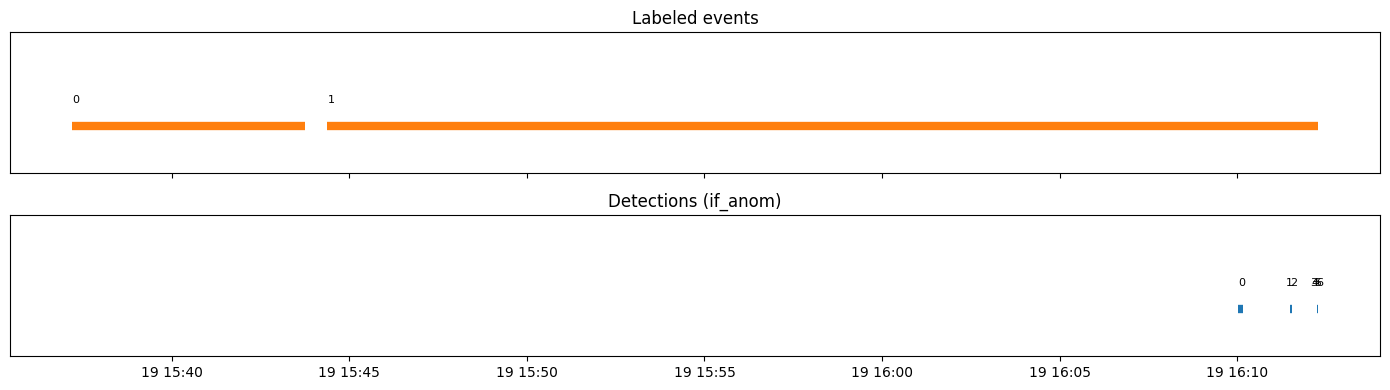

In [ ]:
# choose detector to inspect (one that produced detections)
det = 'if_anom'
# build detected windows (reuse your function)
det_windows = build_detected_windows(df_feat, flag_col=det, time_col='Time')
L = label_events.copy()
D = det_windows.copy()

# show summary
print("Labeled events:", len(L))
print("Detected windows:", len(D))
display(L.head(), D.head())

# simple timeline plot (top: labels, bottom: detections)
fig, ax = plt.subplots(2,1, figsize=(14,4), sharex=True)
for i, row in L.iterrows():
    ax[0].hlines(1, row['start_time'], row['end_time'], linewidth=6, color='tab:orange')
    ax[0].text(row['start_time'], 1.05, str(i), fontsize=8)
ax[0].set_ylim(0.9,1.2); ax[0].set_yticks([]); ax[0].set_title('Labeled events')

for i, row in D.iterrows():
    ax[1].hlines(1, row['start_time'], row['end_time'], linewidth=6, color='tab:blue')
    ax[1].text(row['start_time'], 1.05, str(i), fontsize=8)
ax[1].set_ylim(0.9,1.2); ax[1].set_yticks([]); ax[1].set_title(f'Detections ({det})')

plt.tight_layout(); plt.show()

In [ ]:
# verify normalization and inspect Time / Label_encoded
print("index type:", type(df_feat.index))
print("index monotonic:", getattr(df_feat.index, "is_monotonic_increasing", False))
print("Time range:", df_feat.index.min(), "->", df_feat.index.max())
print("Time column present:", 'Time' in df_feat.columns)
print("Label_encoded unique:", np.unique(df_feat['Label_encoded']) if 'Label_encoded' in df_feat.columns else "missing")
print("sample rows:")
display(df_feat[['Time','Label','Label_encoded']].head(5))

index type: <class 'pandas.core.indexes.range.RangeIndex'>
index monotonic: True
Time range: 0 -> 2104
Time column present: True
Label_encoded unique: [0. 1. 2. 3. 4. 5.]
sample rows:


,Time,Label,Label_encoded
0,2021-04-19 15:37:12,normal,3.0
1,2021-04-19 15:37:13,normal,3.0
2,2021-04-19 15:37:14,normal,3.0
3,2021-04-19 15:37:15,normal,3.0
4,2021-04-19 15:37:16,normal,3.0


In [ ]:
# Safe normalization + derive label_events from Label_encoded (idempotent)
# 0. quick guard: ensure df_feat exists
assert 'df_feat' in globals(), "df_feat not found in globals"

# 1. If index has a level named 'Time', extract it into a temporary column without duplicating
if 'Time' in (df_feat.index.names or []):
    # grab index level values into a temp series (no insertion yet)
    idx_frame = df_feat.index.to_frame(index=False)
    if 'Time' in idx_frame.columns:
        df_feat['_time_from_index'] = idx_frame['Time'].values

# 2. If both Time column and _time_from_index exist, decide which to prefer.
# Prefer an existing, non-null 'Time' column; otherwise use the index-derived values.
if 'Time' in df_feat.columns and '_time_from_index' in df_feat.columns:
    if df_feat['Time'].isna().any() and not df_feat['_time_from_index'].isna().any():
        df_feat['Time'] = df_feat['_time_from_index']
    # drop helper
    df_feat = df_feat.drop(columns=['_time_from_index'], errors='ignore')

# 3. If only _time_from_index exists and no Time column, rename it to Time
if 'Time' not in df_feat.columns and '_time_from_index' in df_feat.columns:
    df_feat = df_feat.rename(columns={'_time_from_index': 'Time'})

# 4. If index is DatetimeIndex and a Time column still exists, drop index to avoid ambiguity
if isinstance(df_feat.index, pd.DatetimeIndex) and 'Time' in df_feat.columns:
    df_feat = df_feat.reset_index(drop=True)

# 5. If no Time column but index is datetime, materialize it
if 'Time' not in df_feat.columns and isinstance(df_feat.index, pd.DatetimeIndex):
    df_feat = df_feat.reset_index(drop=False)

# 6. Canonicalize Time and set DatetimeIndex (idempotent)
df_feat['Time'] = pd.to_datetime(df_feat['Time'])
df_feat = df_feat.sort_values('Time').reset_index(drop=True)
df_feat = df_feat.set_index('Time', drop=False)

# 7. Build df_points and label_events safely using explicit column access
if 'Label_encoded' not in df_feat.columns:
    raise RuntimeError("Label_encoded missing in df_feat")

pts_mask = (df_feat['Label_encoded'].to_numpy() != 0)
# explicit column selection avoids ambiguous .loc with duplicate names
df_points = pd.DataFrame({'Time': df_feat.loc[pts_mask, 'Time'].values})
df_points = df_points.sort_values('Time').reset_index(drop=True)

MERGE_GAP_SECONDS = globals().get('MERGE_GAP_SECONDS', 30)
if df_points.empty:
    label_events = pd.DataFrame(columns=['start_time','end_time','n_points','duration_s'])
else:
    df_points['gap_sec'] = df_points['Time'].diff().dt.total_seconds().fillna(0)
    df_points['grp'] = (df_points['gap_sec'] > MERGE_GAP_SECONDS).cumsum()
    label_events = (
        df_points.groupby('grp')['Time']
        .agg(start_time='min', end_time='max', n_points='count')
        .reset_index(drop=True)
    )
    label_events['duration_s'] = (label_events['end_time'] - label_events['start_time']).dt.total_seconds()

# 8. Report result
print("Normalization done.")
print("df_feat index type:", type(df_feat.index), "Time range:", df_feat.index.min(), "->", df_feat.index.max())
print("Found labeled points:", len(df_points), " -> derived label_events:", len(label_events))

Normalization done.
df_feat index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'> Time range: 2021-04-19 15:37:12 -> 2021-04-19 16:12:16
Found labeled points: 2025  -> derived label_events: 2


In [ ]:
# Build snapshots, save ragged node-attr, create event-aware splits, persist scaler
# Config (tune if needed)
import numpy as np, pandas as pd, pickle, joblib

OUTPUT_DIR = Path("artifacts"); OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
WINDOW_SECONDS = 60
NEG_SAMPLES_PER_EVENT = 3
RANDOM_SEED = 42
TRAIN_FRAC = 0.7
VAL_FRAC = 0.15
TEST_FRAC = 0.15

# Ensure node_map exists (infer if not)
if 'node_map' not in globals():
    def node_feature_map_infer(df):
        mapping = {}
        for c in df.columns:
            base = c.split('__')[0] if '__' in c else (c.split('_')[0] if '_' in c else c)
            mapping.setdefault(base, []).append(c)
        return {k: sorted(list(set(v))) for k, v in mapping.items()}
    node_map = node_feature_map_infer(df_feat)
nodes = sorted(list(node_map.keys()))

# Robust snapshot builder (re-usable)
def build_snapshot_at_time_safe(t0, window_seconds=WINDOW_SECONDS, df=df_feat, node_map=node_map):
    t0 = pd.to_datetime(t0)
    start = t0 - pd.Timedelta(seconds=window_seconds)
    end   = t0 + pd.Timedelta(seconds=window_seconds)
    window = df.loc[start:end]
    if window.shape[0] == 0:
        return None
    node_attrs = {}
    for node, cols in node_map.items():
        if not cols:
            node_attrs[node] = {}
            continue
        seg = window[cols].astype(float).dropna(how='all')
        if seg.shape[0] == 0:
            feat = {f"{node}__{c}__{stat}": 0.0 for c in cols for stat in ['last','mean','std','min','max','slope']}
        else:
            last = seg.iloc[-1].values
            mean = seg.mean().values
            std  = seg.std(ddof=0).fillna(0).values
            mn   = seg.min().values
            mx   = seg.max().values
            if seg.shape[0] > 1:
                x = np.arange(len(seg))
                slope = np.array([np.polyfit(x, seg[c].values, 1)[0] for c in seg.columns])
            else:
                slope = np.zeros(len(seg.columns))
            feat = {}
            for i, c in enumerate(seg.columns):
                feat[f"{node}__{c}__last"]  = float(last[i])
                feat[f"{node}__{c}__mean"]  = float(mean[i])
                feat[f"{node}__{c}__std"]   = float(std[i])
                feat[f"{node}__{c}__min"]   = float(mn[i])
                feat[f"{node}__{c}__max"]   = float(mx[i])
                feat[f"{node}__{c}__slope"] = float(slope[i])
        node_attrs[node] = feat
    return {'start_time': start, 'center_time': t0, 'end_time': end, 'node_attrs': node_attrs}

# Build positive snapshots from label_events (center, start, end)
pos_snapshots = []
for i, l in label_events.iterrows():
    centers = [l['start_time'] + (l['end_time'] - l['start_time'])/2, l['start_time'], l['end_time']]
    for cen in centers:
        s = build_snapshot_at_time_safe(cen)
        if s is not None:
            s['label'] = 1; s['lab_idx'] = int(i); pos_snapshots.append(s)

# Build negative snapshots sampled outside labeled windows
timeline_mask = pd.Series(False, index=df_feat.index)
for _, l in label_events.iterrows():
    m = (df_feat.index >= pd.to_datetime(l['start_time'])) & (df_feat.index <= pd.to_datetime(l['end_time']))
    timeline_mask.loc[m] = True
neg_candidates = df_feat.index[~timeline_mask]
rng = np.random.default_rng(RANDOM_SEED)
neg_snapshots = []
if len(neg_candidates) > 0:
    n_neg = max(len(pos_snapshots) * NEG_SAMPLES_PER_EVENT, len(label_events) * NEG_SAMPLES_PER_EVENT, 10)
    n_neg = min(len(neg_candidates), int(n_neg))
    sampled_times = rng.choice(neg_candidates, size=n_neg, replace=False)
    for t in sampled_times:
        s = build_snapshot_at_time_safe(t)
        if s is not None:
            s['label'] = 0; s['lab_idx'] = -1; neg_snapshots.append(s)

all_snaps = pos_snapshots + neg_snapshots
print("Snapshots built:", len(all_snaps), "pos:", len(pos_snapshots), "neg:", len(neg_snapshots))

# Flatten snapshots to table and keep ragged node attributes
rows = []; node_attr_matrices = {}
for sid, s in enumerate(all_snaps):
    flat = {}
    for node, feats in s['node_attrs'].items():
        for k, v in feats.items():
            flat[k] = float(v)
    flat.update({'snapshot_id': sid, 'start_time': s['start_time'], 'center_time': s['center_time'],
                 'end_time': s['end_time'], 'label': s['label'], 'lab_idx': s['lab_idx']})
    rows.append(flat)
    node_attr_matrices[sid] = s['node_attrs']

snap_df = pd.DataFrame(rows).reset_index(drop=True)
snap_df.to_csv(OUTPUT_DIR / "snapshot_features_flat.csv", index=False)
with open(OUTPUT_DIR / "snapshot_node_attr_ragged.pkl", "wb") as f:
    pickle.dump({'node_attr_matrices': node_attr_matrices, 'node_map': node_map, 'nodes': nodes}, f)
print("Saved snapshot_features_flat.csv and snapshot_node_attr_ragged.pkl to", OUTPUT_DIR)

# Event-aware splits: split labeled events and allocate negatives proportionally
snap_df['event_id_for_split'] = snap_df['lab_idx'].apply(lambda x: int(x) if int(x) >= 0 else None)
event_to_snapshot_ids = {}
for idx, row in snap_df.iterrows():
    eid = row['event_id_for_split']
    if eid is None:
        continue
    event_to_snapshot_ids.setdefault(eid, []).append(idx)

labeled_ids = sorted(event_to_snapshot_ids.keys())
if len(labeled_ids) > 0:
    train_ids, temp_ids = train_test_split(labeled_ids, train_size=TRAIN_FRAC, random_state=RANDOM_SEED)
    val_ids, test_ids = train_test_split(temp_ids, test_size=TEST_FRAC/(TEST_FRAC + VAL_FRAC), random_state=RANDOM_SEED)
else:
    train_ids = val_ids = test_ids = []

train_idx = []; val_idx = []; test_idx = []
for eid in train_ids: train_idx += event_to_snapshot_ids[eid]
for eid in val_ids:   val_idx += event_to_snapshot_ids[eid]
for eid in test_ids:  test_idx += event_to_snapshot_ids[eid]

neg_idxs = snap_df[snap_df['event_id_for_split'].isna()].index.to_list()
if len(neg_idxs) > 0:
    neg_train, neg_temp = train_test_split(neg_idxs, train_size=TRAIN_FRAC, random_state=RANDOM_SEED)
    neg_val, neg_test   = train_test_split(neg_temp, test_size=TEST_FRAC/(TEST_FRAC + VAL_FRAC), random_state=RANDOM_SEED)
    train_idx += neg_train; val_idx += neg_val; test_idx += neg_test

train_idx = sorted(list(set(train_idx))); val_idx = sorted(list(set(val_idx))); test_idx = sorted(list(set(test_idx)))
pd.DataFrame({'snapshot_idx': train_idx}).to_csv(OUTPUT_DIR / "split_train_idx.csv", index=False)
pd.DataFrame({'snapshot_idx': val_idx}).to_csv(OUTPUT_DIR / "split_val_idx.csv", index=False)
pd.DataFrame({'snapshot_idx': test_idx}).to_csv(OUTPUT_DIR / "split_test_idx.csv", index=False)
snap_df.to_csv(OUTPUT_DIR / "snapshot_master_table.csv", index=False)
print("Split sizes (snapshots): train", len(train_idx), "val", len(val_idx), "test", len(test_idx))

# Fit StandardScaler on train flattened features and persist
feat_cols = [c for c in snap_df.columns if '__' in c]
if len(train_idx) == 0:
    print("No labeled events in splits; scaler will be fit on all snapshots.")
    train_idx = list(snap_df.index)
train_flat = snap_df.loc[train_idx, feat_cols].fillna(0).values
scaler = StandardScaler().fit(train_flat)
joblib.dump(scaler, OUTPUT_DIR / "scaler_flat.joblib")
print("Fitted and saved StandardScaler")

Snapshots built: 24 pos: 6 neg: 18
Saved snapshot_features_flat.csv and snapshot_node_attr_ragged.pkl to artifacts
Split sizes (snapshots): train 16 val 8 test 8
Fitted and saved StandardScaler


Guidance:
- Choose snapshot window (e.g., 10s or 30s) producing graph G_t with node features F_t and adjacency A_t.
- Define normal training intervals (exclude labeled anomalies) for autoencoder training.
- Save per-snapshot artifacts: node index mapping, feature matrix, adjacency (sparse), time range, anomaly flag.
Checklist:
- Snapshot generation code cell; serialization format (e.g., npz / torch geometric data / graphml).
- Data splits: train_normal_windows, val_windows, test_windows (include anomalies in test).
Deliverables:
- Snapshot generation notebook cells, file naming conventions, example snapshot saved.


# Step 9 - XAI and interpretability steps

Purpose: plan how to produce interpretable outputs per detected anomaly for CIS dashboard.

For tabular XGBoost:
- Use SHAP: compute per-instance SHAP values on detected anomaly windows; save top-K features per anomaly.
For GNN explanations:
- Use GNNExplainer or integrated gradients (or surrogate explainers) to extract influential nodes/edges and subgraphs.
- Save explanation artifacts: node importance scores, edge masks, subgraph identifiers.

Notebook cells:
- Compute and store explanations after detection; attach to anomaly event records (time, affected_node, explanation_blob).

Deliverables:
- Example SHAP plot for one anomaly, example subgraph visualization (matplotlib/networkx), explanation CSV (anomaly_id, top_nodes, top_features).

# Step 10 - Mapping to cybersecurity taxonomy for XGBoost classification

Purpose: classify detected anomalies to MITRE-like classes using contextualized features + explanations.

In [ ]:
def assemble_anomaly_report(event_row, df_window=None, shap_df=None, graph_file=None, out_dir=OUTPUT_DIR):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    # parse times
    start = pd.to_datetime(event_row['start_time'])
    end = pd.to_datetime(event_row['end_time'])

    # build window if not provided; use lowercase 's' for Timedelta
    if df_window is None:
        df_window = df_feat[(df_feat['Time'] >= start - pd.Timedelta('10s')) &
                            (df_feat['Time'] <= end + pd.Timedelta('10s'))].copy()

    # safe fallback for sensor/actuator lists
    tscols = sensor_cols[:4] if 'sensor_cols' in globals() else [c for c in df_window.columns if df_window[c].dtype.kind in 'iuf'][:4]
    act_cols = bool_cols if 'bool_cols' in globals() else [c for c in df_window.columns if df_window[c].dtype == bool]

    # plotting
    try:
        fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
        if not df_window.empty and len(tscols) > 0:
            df_window.set_index('Time')[tscols].plot(ax=axes[0], legend=True)
        axes[0].axvspan(start, end, color='red', alpha=0.2)
        axes[0].set_title(f"Event {int(event_row['event_id'])} time series")

        if len(act_cols) > 0 and not df_window.empty:
            actu = df_window.set_index('Time')[act_cols].mean().sort_values(ascending=False)
            actu.plot(kind='bar', ax=axes[1])
            axes[1].set_title("Actuator on-fraction in window")
        else:
            axes[1].axis('off')

        # optional SHAP horizontal bar (top features) placed on a third figure if provided
        if shap_df is not None:
            fig_shap, ax_shap = plt.subplots(1, 1, figsize=(8, 3))
            topn = shap_df.copy().sort_values('shap_value', key=lambda s: s.abs(), ascending=False).head(10)
            ax_shap.barh(topn['feature'].astype(str), topn['shap_value'])
            ax_shap.set_title("Top SHAP contributions (abs-sorted)")
            plt.tight_layout()
            shap_path = out_dir / f"event_{int(event_row['event_id'])}_shap.png"
            fig_shap.savefig(shap_path, dpi=150, bbox_inches='tight')
            plt.close(fig_shap)
        else:
            shap_path = None

        # optional: if a graph file path is passed, attempt to copy into out_dir for packaging
        if graph_file:
            try:
                graph_target = out_dir / Path(graph_file).name
                if Path(graph_file).exists():
                    import shutil
                    shutil.copy(graph_file, graph_target)
                else:
                    graph_target = None
            except Exception:
                graph_target = None
        else:
            graph_target = None

        plt.tight_layout()
        fig_path = out_dir / f"event_{int(event_row['event_id'])}_report.png"
        fig.savefig(fig_path, dpi=150, bbox_inches='tight')
        plt.close(fig)

        # save JSON summary
        summary = {
            "event_id": int(event_row['event_id']),
            "start_time": str(start),
            "end_time": str(end),
            "duration_s": float(event_row.get('duration_s', (end - start).total_seconds())),
            "label_encoded": int(event_row.get('label_encoded', -1)) if 'label_encoded' in event_row else None,
            "label_text": event_row.get('label_text', None),
            "figure": str(fig_path),
            "shap_figure": str(shap_path) if shap_path else None,
            "graph_file": str(graph_target) if graph_target else None
        }
        (out_dir / f"event_{int(event_row['event_id'])}_summary.json").write_text(json.dumps(summary, indent=2))
        return {"figure": str(fig_path), "summary": summary}
    except Exception as e:
        # safe failure: write error note and return minimal info
        err = {"event_id": int(event_row.get('event_id', -1)), "error": str(e)}
        (out_dir / f"event_{int(event_row.get('event_id', -1))}_error.json").write_text(json.dumps(err, indent=2))
        return {"error": str(e), "event_id": int(event_row.get('event_id', -1))}

Pipeline:
- Build dataset of anomalies (rows = anomaly events) with:
- Event-level aggregated features (peak_delta, duration, affected_node_counts).
- Top-K SHAP features or node importance as inputs.
- Train XGBoost with cross-validation; evaluate macro F1 and class confusion.
Notebook cells:
- Feature creation for classifier, model training (with sklearn/xgboost), evaluation, and saving model and feature importance.
Deliverables:
- Model artifact, classification report, calibration plots, mapping table (model class -> MITRE tactic/technique).


# Step 11 - Visualization, debugging and analyst outputs

Purpose: create analyst-friendly artifacts for each anomaly.

Required plots/artifacts:
1. Timeline view with sensor traces and annotated anomaly window.
2. Network/graph view with highlighted subgraph from GNNExplainer.
3. SHAP summary for that event and top contributing tabular features.
4. Textual summary: affected_component, start_time, end_time, probable_attack_class, confidence.

In [ ]:
# check whether events_df exists in this kernel
'events_df' in globals(), globals().get('events_df', None)

(True,
    event_id           start_time             end_time  duration_s  n_points  \
 0         2  2021-09-04 18:25:48  2021-09-04 18:28:14       146.0       147   
 1         4  2021-09-04 18:30:08  2021-09-04 18:31:14        66.0        67   
 2         6  2021-09-04 18:34:11  2021-09-04 18:35:38        87.0        88   
 3         8  2021-09-04 18:38:38  2021-09-04 18:39:50        72.0        73   
 4        10  2021-09-04 18:43:52  2021-09-04 18:45:54       122.0       123   
 5        12  2021-09-04 18:49:02  2021-09-04 18:51:18       136.0       137   
 6        14  2021-09-04 18:58:05  2021-09-04 18:59:31        86.0        87   
 7        16  2021-09-04 19:00:40  2021-09-04 19:02:07        87.0        88   
 
    label_encoded      label_text  Tank_1_max  Tank_1_mean  Tank_1_std  ...  \
 0              1            MITM      1058.0   263.449102  339.916444  ...   
 1              1  physical fault      1297.0   685.977011  380.647642  ...   
 2              1            MITM 

In [ ]:
# Notebook cell: assemble a full anomaly report for a single event_id
# Config: tweak as needed
OUT = OUTPUT_DIR if 'OUTPUT_DIR' in globals() else Path("./artifacts")
OUT.mkdir(parents=True, exist_ok=True)
TS_SENSORS = sensor_cols[:6] if 'sensor_cols' in globals() else [c for c in df_feat.columns if df_feat.dtype.kind in 'iuf'][:6]
ACT_COLS = bool_cols if 'bool_cols' in globals() else [c for c in df_feat.columns if df_feat.dtype == bool]
ANOM_SCORE_COLS = ['if_score','lstm_ae_score','z_norm']  # prefer existing score columns
GRAPH_DIR = OUT / "graphs"    # optional precomputed graphs (graphml per snapshot)
GRAPH_DIR.mkdir(exist_ok=True)

def _time_window_df(event_row, pad_s=60):
    start = pd.to_datetime(event_row['start_time']) - pd.Timedelta(seconds=pad_s)
    end = pd.to_datetime(event_row['end_time']) + pd.Timedelta(seconds=pad_s)
    win = df_feat[(df_feat['Time'] >= start) & (df_feat['Time'] <= end)].copy()
    return win, start + pd.Timedelta(seconds=pad_s), end - pd.Timedelta(seconds=pad_s)  # returns (window_df, label_start, label_end)

def _plot_timeline(win_df, label_start, label_end, event_id, sensors=TS_SENSORS, score_cols=ANOM_SCORE_COLS, out_dir=OUT):
    fig, axes = plt.subplots(len(sensors) + 1, 1, figsize=(14, 2.2*(len(sensors)+1)), sharex=True)
    for ax, s in zip(axes[:-1], sensors):
        if s in win_df.columns:
            ax.plot(win_df['Time'], win_df[s], lw=1)
        ax.set_ylabel(s)
        ax.grid(alpha=0.2)
    # anomaly scores row (if present)
    score_ax = axes[-1]
    plotted_any = False
    for sc in score_cols:
        if sc in win_df.columns:
            score_ax.plot(win_df['Time'], win_df[sc], label=sc)
            plotted_any = True
    if plotted_any:
        score_ax.legend(loc='upper right', fontsize=8)
    else:
        score_ax.axis('off')
    # highlight labeled window
    score_ax.axvspan(label_start, label_end, color='red', alpha=0.12)
    axes[0].set_title(f"Event {int(event_id)} timeline (sensors + anomaly scores)")
    axes[-1].set_xlabel("Time")
    plt.tight_layout()
    path = out_dir / f"event_{int(event_id)}_timeline.png"
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    return path

def _plot_network_snapshot(event_row, out_dir=OUT, graph_dir=GRAPH_DIR, highlight_nodes=None):
    """
    Try to load a precomputed graph for the snapshot closest to the event start.
    If graph can't be found or networkx isn't able to draw it, return None.
    """
    # heuristics: if you saved snapshot index earlier as 'snapshots_index.csv', use it
    snap_idx_path = graph_dir / "snapshots_index.csv"
    graph_file = None
    if snap_idx_path.exists():
        snaps = pd.read_csv(snap_idx_path, parse_dates=['start','end'])
        start_ts = pd.to_datetime(event_row['start_time'])
        # find snapshot whose window covers event start (or nearest by start time)
        row = snaps[(snaps['start'] <= start_ts) & (snaps['end'] >= start_ts)]
        if row.empty:
            # pick nearest by absolute start difference
            snaps['dist'] = (snaps['start'] - start_ts).abs()
            row = snaps.loc[[snaps['dist'].idxmin()]]
        if not row.empty:
            fname = row.iloc[0]['file']
            cand = Path(fname)
            if cand.exists():
                graph_file = cand
    # fallback: look for any graphml in graph_dir
    if graph_file is None:
        for f in graph_dir.glob("*.graphml"):
            graph_file = f
            break
    if graph_file is None:
        return None
    try:
        G = nx.read_graphml(str(graph_file))
    except Exception:
        return None
    # highlight central subgraph if provided list of nodes; otherwise color by degree/weight
    node_colors = []
    weights = []
    for n in G.nodes():
        if highlight_nodes and n in highlight_nodes:
            node_colors.append('red')
        else:
            node_colors.append('#3182bd')  # default
        # collect a numeric attribute to size nodes if present
        w = G.nodes[n].get('mean') or G.nodes[n].get('last') or 1.0
        try:
            weights.append(float(w))
        except Exception:
            weights.append(1.0)
    # normalize node sizes
    norm = Normalize(vmin=np.min(weights), vmax=np.max(weights))
    cmap = cm.get_cmap("OrRd")
    colors = [cmap(norm(w)) for w in weights]
    sizes = 200 * (norm(weights) + 0.1)
    plt.figure(figsize=(8,6))
    pos = nx.spring_layout(G, seed=42, k=0.4)
    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=sizes)
    # edge widths by weight if present
    ews = [float(d.get('weight', 0.1)) for u,v,d in G.edges(data=True)]
    nx.draw_networkx_edges(G, pos, width=[max(0.3, 2*ew) for ew in ews], alpha=0.6)
    nx.draw_networkx_labels(G, pos, font_size=8)
    plt.axis('off')
    path = out_dir / f"event_{int(event_row['event_id'])}_graph.png"
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.close()
    return path

def _render_shap_summary(event_row, shap_df=None, out_dir=OUT):
    """
    If you have a per-event shap_df (DataFrame with columns 'feature' and 'shap_value'),
    plot the top contributors and return path; otherwise return None.
    """
    if shap_df is None:
        # try to locate a saved shap file for this event (matches_<detector>.csv or shap_event_X.csv)
        cand = OUT / f"shap_event_{int(event_row['event_id'])}.csv"
        if cand.exists():
            shap_df = pd.read_csv(cand)
        else:
            return None
    # ensure proper columns
    if not {'feature','shap_value'}.issubset(set(shap_df.columns)):
        return None
    top = shap_df.copy().sort_values('shap_value', key=lambda s: s.abs(), ascending=False).head(15)
    fig, ax = plt.subplots(1,1,figsize=(8, max(3, 0.25*len(top))))
    ax.barh(top['feature'].astype(str), top['shap_value'])
    ax.set_title(f"Top SHAP for event {int(event_row['event_id'])}")
    plt.tight_layout()
    path = out_dir / f"event_{int(event_row['event_id'])}_shap.png"
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    return path

def _textual_summary(event_row, det_model=None, shap_df=None):
    """
    Compose a short textual summary with fields:
    affected_component, start_time, end_time, probable_attack_class, confidence
    - probable_attack_class: use events_df label_text or model predict if event classifier exists;
      confidence: use classifier probability if available, else mean anomaly score inside window.
    """
    start = event_row['start_time']; end = event_row['end_time']
    affected = event_row.get('label_text') or "unknown_component"
    probable = event_row.get('label_text') or "unknown"
    confidence = None
    # use XGBoost event-level classifier if available
    if 'xgb_event_model.json' in [p.name for p in OUT.iterdir()]:
        try:
            import xgboost as xgb
            clf = xgb.XGBClassifier()
            clf.load_model(str(OUT / "xgb_event_model.json"))
            # reconstruct event-level row features from events_df if present
            if 'events_df' in globals():
                erow = events_df[events_df['event_id'] == event_row['event_id']].iloc[0]
                feat_cols = [c for c in erow.index if c not in ('event_id','start_time','end_time','label_text','label_encoded')]
                Xev = erow[feat_cols].astype(float).to_numpy().reshape(1,-1)
                probs = clf.predict_proba(Xev)[0]
                pred = clf.predict(Xev)[0]
                probable = int(pred)
                confidence = float(np.max(probs))
        except Exception:
            confidence = None
    # fallback: use mean anomaly score inside event window if present
    if confidence is None and 'anom_score' in df_feat.columns:
        win = df_feat[(df_feat['Time'] >= pd.to_datetime(event_row['start_time'])) & (df_feat['Time'] <= pd.to_datetime(event_row['end_time']))]
        if not win.empty:
            confidence = float(win['anom_score'].mean())
    if confidence is None:
        confidence = 0.0
    return {
        "affected_component": affected,
        "start_time": start,
        "end_time": end,
        "probable_attack_class": probable,
        "confidence": float(confidence)
    }

def anomaly_report(event_id, save_index=True, out_dir=OUT):
    """
    Top-level function to assemble timeline, network, SHAP, textual summary for a labeled event_id.
    Returns a dict with paths and summary.
    """
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    if 'events_df' not in globals():
        raise RuntimeError("events_df required for anomaly_report")
    ev_rows = events_df[events_df['event_id'] == int(event_id)]
    if ev_rows.empty:
        raise KeyError(f"event_id {event_id} not found in events_df")
    ev = ev_rows.iloc[0].to_dict()

    # 1) time window and timeline plot
    win_df, lab_s, lab_e = _time_window_df(ev, pad_s=60)
    timeline_path = _plot_timeline(win_df, lab_s, lab_e, event_id, sensors=TS_SENSORS, out_dir=out_dir)

    # 2) network snapshot (try to highlight top sensors with largest delta in window)
    # pick top-k sensors by mean abs delta in window to highlight subgraph
    highlight_nodes = None
    sensor_deltas = []
    for s in TS_SENSORS:
        if f"{s}_delta" in win_df.columns:
            sensor_deltas.append((s, float(win_df[f"{s}_delta"].abs().mean())))
    if sensor_deltas:
        sensor_deltas.sort(key=lambda x: x[1], reverse=True)
        highlight_nodes = [s for s,_ in sensor_deltas[:6]]
    graph_path = _plot_network_snapshot(ev, out_dir=out_dir, highlight_nodes=highlight_nodes)

    # 3) SHAP plot (try to load shap per-event CSV or shap_df if available externally)
    shap_path = _render_shap_summary(ev, shap_df=None, out_dir=out_dir)

    # 4) textual summary (uses classifier if available or label text)
    text_summary = _textual_summary(ev)

    # 5) assemble JSON index and return
    report = {
        "event_id": int(event_id),
        "timeline": str(timeline_path) if timeline_path else None,
        "network": str(graph_path) if graph_path else None,
        "shap": str(shap_path) if shap_path else None,
        "summary": text_summary
    }
    idx_path = out_dir / "report_index.json"
    if save_index:
        # append or create index JSON array
        if idx_path.exists():
            try:
                idx_list = json.loads(idx_path.read_text())
            except Exception:
                idx_list = []
        else:
            idx_list = []
        idx_list.append(report)
        idx_path.write_text(json.dumps(idx_list, indent=2))
    return report

Deliverables:

    PNG or embedded notebook cells for single-anomaly report templates.

In [ ]:
gc.collect()

149641

# Step 12 - Experiments, logging and reproducibility

Purpose: ensure experiments are traceable and artifacts reproducible.

What to version:
- Code cell git commit hash, dataset version, feature pipeline parameters, model hyperparams, random seeds.
- Save experiment metadata (MLflow/Weights & Biases or simple JSON per run).

Notebook cells:
- Export feature list, hyperparams, metrics to local experiments/ folder with timestamped filenames.
Deliverables:
- experiments.csv or JSON; recommended logging snippet.

# Step 13 - Checklist for handing artifact to the ETL/CIS pipeline

1. Are timestamps normalized and timezone-aware?
2. Are node/edge schemas pinned and communicated to Neo4j/GNN ingest team?
3. Are feature transforms reproducible and serialized?
4. Are snapshot naming conventions and time windows agreed for GNN training?
5. Are explanation artifacts structured to be stored in Neo4j (e.g., top_nodes, top_features, scores) for analyst queries?
6. Are anomaly events summarized (start, end, affected_nodes, classifier_label, confidence, explanation_id)?

## Appendix for the research paper

Useful utility snippets include:
- MD5 checksum
- save/load feature pipeline
- event-window extraction

In [ ]:
# Make PDF
!apt-get update -qq
!apt-get install -y -qq texlive-xetex texlive-fonts-recommended
!pip install -q "lxml[html_clean]" lxml_html_clean nbconvert
!jupyter-nbconvert --to pdf "/content/drive/MyDrive/CS/AI Cybersecurity/Notebooks/Physical/PhysicalTemplate.ipynb"

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
[NbConvertApp] Converting notebook /content/drive/MyDrive/CS/AI Cybersecurity/Notebooks/Physical/PhysicalTemplate.ipynb to pdf
[NbConvertApp] Support files will be in PhysicalTemplate_files/
[NbConvertApp] Making directory ./PhysicalTemplate_files
[NbConvertApp] Writing 414652 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 2558591 bytes to /content/drive/MyDrive/CS/AI Cybersecurity/Notebooks/Physical/PhysicalTemplate.pdf
